# Fast & slow modes

Volem resoldre el problema dels modes ràpid i lent de les equacios obtingudes a partir de la MHD ideal i de la linealització i posterior adimensionalització de les equacions.

# Introducció i solució de les equacions

In [1]:
import dedalus.public as d3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from matplotlib import cm
from scipy.optimize import fsolve
import logging
logging.getLogger().setLevel(logging.WARNING)
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,               # Mida general del text
    "axes.titlesize": 20,         # Mida del títol dels eixos
    "axes.labelsize": 20,         # Mida de les etiquetes dels eixos
    "xtick.labelsize": 20,        # Mida dels ticks de l'eix X
    "ytick.labelsize": 20,        # Mida dels ticks de l'eix Y
    "legend.fontsize": 20,        # Mida del text de la llegenda
    "figure.dpi": 300,            # Resolució
    "text.usetex": True,          # Activa LaTeX per al text
    "mathtext.fontset": "cm",     # (Opcional) Usa Computer Modern si no s’usa LaTeX
#    #"font.serif": ["Computer Modern"],  # Use Computer Modern (LaTeX default)
#    #"font.family": "serif",    # Optional: match LaTeX font
})

from matplotlib.lines import Line2D
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch


""" Funcions per calcular els autovalors exactes """
# Funcions den Monxo per calcular els autovalors exactes d'una corda amb densitat variable.
def dispersion_relation(omega):
    disprel_even = (np.sqrt(cp2)/np.sqrt(cc2)) * np.cos(omega * (xmax - xp) / np.sqrt(cc2)) * np.cos(omega * xp / np.sqrt(cp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(cc2)) * np.sin(omega * xp / np.sqrt(cp2))
    disprel_odd = (np.sqrt(cp2)/np.sqrt(cc2)) * np.cos(omega * (xmax - xp) / np.sqrt(cc2)) * np.sin(omega * xp / np.sqrt(cp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(cc2)) * np.cos(omega * xp / np.sqrt(cp2))
    disprel = disprel_even * disprel_odd
    return disprel

def dispersion_relation2(omega):
    disprel_even2 = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2)) - \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2))
    disprel_odd2 = (np.sqrt(vAp2)/np.sqrt(vAc2)) * np.cos(omega * (xmax - xp) / np.sqrt(vAc2)) * np.sin(omega * xp / np.sqrt(vAp2)) + \
        np.sin(omega * (xmax - xp) / np.sqrt(vAc2)) * np.cos(omega * xp / np.sqrt(vAp2))
    disprel2 = disprel_even2 * disprel_odd2
    return disprel2

def get_eigenvalues(Nevals):
    Nsol = 0
    omega0 = 1
    omega_step = 0.5
    exact_soln = np.array([])
    while Nsol < Nevals:
        sol = fsolve(dispersion_relation, omega0)
#         print('omega0, sol ', omega0, sol)
        sol2 = fsolve(dispersion_relation2, omega0)

        if sol > 0:
            exact_soln = np.append(exact_soln, sol)
            exact_soln = np.unique(exact_soln.round(decimals=8))
#         print('exact_soln, exact_soln**2 ', exact_soln, exact_soln**2)
#         print(exact_soln.size)
        if sol2 > 0:
            exact_soln = np.append(exact_soln, sol2)
            exact_soln = np.unique(exact_soln.round(decimals=8))

        Nsol = exact_soln.size
        omega0 = omega0 + omega_step
#    print('exact_soln ', exact_soln[0:5])
#    print('exact_soln**2 ', exact_soln**2)
    print()
    return exact_soln



""" Paràmetres """
Nx = 128 # amb 32 ja no és smooth...
dtype = np.complex128 # malla en la que es treballa: 128 complexes, ja que hem definit Nx = 128



""" Límits del domini """
xmax = 1
xmin = -1 # = -xmax
# Position of boundaries between different parts of the system (prominence and corona).
xp = 0.1
# xc ∈ [-1, -0.1], xc ∈ [0.1, 1]



""" Constants """
kz = 0.01
#kz = 2.5
#B0 = 0

### Velocitats a trossos ###
cp2 = 1
cc2 = 6
vAp2 = 20
vAc2 = 250
# Valors realistes: cp2, cc2, vAp2, vAc2  137724550.89820358 27544910179.640717 3978873577.297384 795774715459.4768

# Provar amb valors tals que vAc / vAp = 20, al quadrat 400



""" Bases """
xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=dtype)
xbasis = d3.Legendre(xcoord, size=Nx, bounds=(xmin, xmax)) # Definim una base amb uns altres límits. Chebyshev menos error?



""" Camps """
### Velocitats ###
u = dist.Field(name='u', bases=xbasis) # u = field of the wave function - AUTOFUNCIÓ!!! - v10x bar, coplexa
w = dist.Field(name='w', bases=xbasis) # w = Velocity in the x direction   v10z - real
# Definesc la velocitat com en oceano: (u,v,w) per no liar subíndexos i derivades.

### Espai real ###
x = dist.local_grid(xbasis)

### Constants ###
c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2, cp2, cc2]) # Representa la c^2 en l'espai real ('g') a trossos.
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Autovalors ###
s = dist.Field(name='s') # AUTOVALOR ω^2 = s

### Camps magnètics ###
#Bx = dist.Field(name='Bx', bases=xbasis) # Bx = Magnetic field in the x direction   B10x
#Bz = dist.Field(name='Bz', bases=xbasis) # Bz = Magnetic field in the z direction   B10z

### Densitats ###
#rho0 = dist.Field(name='rho0', bases=xbasis) # rho0 = Density of the plasma  ρ0
#rho10 = dist.Field(name='rho10', bases=xbasis) # rho = Variation density of the plasma   ρ10
#rho10['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [1, 1, 1]) # Representa la densitat en l'espai real ('g') a trossos.

### Auxiliars de les derivades ###
tau_1 = dist.Field(name='tau_1')
tau_2 = dist.Field(name='tau_2')
tau_3 = dist.Field(name='tau_3')
tau_4 = dist.Field(name='tau_4')



""" Derivades """
### Derivades espacials ###
dx = lambda A: d3.Differentiate(A, xcoord) # Derivative operator
lift_basis = xbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)
ux = dx(u) + lift(tau_1) # First-order reduction of the velocity in the x direction
uxx = dx(ux) + lift(tau_2) # Second-order reduction of the velocity in the x direction
wx = dx(w) + lift(tau_3) # First-order reduction of the velocity in the z direction
wxx = dx(wx) + lift(tau_4) # Second-order reduction of the velocity in the z direction

# No és convenient posar directament dx(u) a l'equació ja que faltaria el lift... s'ha de definir bé la derivada
# No definim derivada temporal ja que és un EVP!!!

# RESOLDRE PRIMER SUBSTITUINT Bx, Bx i RHO i només resolent 2 eqs... i 4 eqs de contorn, només resolem per u i w, eqs. (17') i (19')



""" Problema """
### Problema d'ones ràpida i lenta (complet) ###
#problem = d3.EVP([u, w, Bx, Bz, rho0, rho10, tau_1, tau_2,], eigenvalue=s, namespace=locals())
#problem.add_equation("np.sqrt(s)*rho10 + rho0*(-wx - kz*w) =0 ") # (12)
#problem.add_equation("np.sqrt(s)*Bx = kz*B0*w") # (14)
#problem.add_equation("np.sqrt(s)*Bz = B0*ux") # (16)
#problem.add_equation("np.sqrt(s)*rho10*ux = -c2*rho10x ") # (17)
#problem.add_equation("np.sqrt(s)*rho10*w - c2*kz*rho10 - vA2*(rho/B0)*(kz*Bx -Bzx) = 0") # (19)

### Problema d'ones d'Alfvén ### ~ corda guitarra amb densitat variable
#problem = d3.EVP([u, tau_1, tau_2], eigenvalue=s, namespace=locals())
#problem.add_equation("s * u  +  vA2 * uxx  =  0") # (12)

### Problema d'ones ràpida i lenta (més treballat) ###
problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals()) # 2 equacions i 4 incògnites
# problem.add_equation("s * u  +  c2 * uxx  =  0") # (17') # amb kz = 0
# problem.add_equation("s * w  +  vA2 * wxx  =  0") # (19') # amb kz = 0. Hauríem d'obtenir una molt semblant a la (17') però amb la velocitat en z i la constant d'Alfvén
problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0") # (17')
problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0") # (19')
problem.add_equation("u(x=xmin) = 0")
problem.add_equation("u(x=xmax) = 0")
problem.add_equation("w(x=xmin) = 0")
problem.add_equation("w(x=xmax) = 0")
print("Number of unknowns:", len(problem.variables))
print("Number of equations:", len(problem.equations))



""" Solver """
### Solver de Dedalus ###
solver = problem.build_solver()
#print(solver.subproblems)
solver.solve_dense(solver.subproblems[0])
evals = np.sort(solver.eigenvalues)

### Ajustament de les autofuncions ###
print("kz =",kz)
print('evals.size (before) ', evals.size)
#evals = evals[~np.isinf(evals)] # el ~ és un operador bitwise NOT, que retorna True si el valor és False i viceversa. En aquest cas elimina els valors infinits
print('evals.size (after removing inf) ', evals.size)
evals = evals[evals > 0] # eliminam els valors negatius
print('evals.size (after removing < 0) ', evals.size)
evals = np.sqrt(evals)

### Autovalors exactes ###
Nevals = evals.size
exact_soln = get_eigenvalues(Nevals)
n = 1 + np.arange(evals.size)
true_evals = exact_soln[0:evals.size]

### Error relatiu ###
relative_error = np.abs(evals - true_evals) / true_evals

### Autovalors ###
print('evals size', evals.size)
print("true_evals size ", true_evals.size)
#print("Evals", evals)
#print("True Evals", true_evals)

### Print 7 primers autovalors ###
evals = evals.real
print("First 7 Eigenvalues (sqrt):", [f"{val:.5f}" for val in evals[:7]])
print("First 7 True eigenvalues:", [f"{val:.5f}" for val in true_evals[:7]])
print("Relative error:", [f"{val:.5f}" for val in relative_error[:7]])
print()


Number of unknowns: 6
Number of equations: 6
kz = 0.01
evals.size (before)  260
evals.size (after removing inf)  260
evals.size (after removing < 0)  260

evals size 260
true_evals size  260
First 7 Eigenvalues (sqrt): ['2.62441', '7.53738', '9.29495', '11.71637', '13.71112', '16.94165', '18.92811']
First 7 True eigenvalues: ['2.66902', '7.55178', '9.34725', '13.17871', '13.94522', '16.96085', '19.33681']
Relative error: ['0.01671', '0.00191', '0.00560', '0.11096', '0.01679', '0.00113', '0.02114']



# Representació de l'error

[]

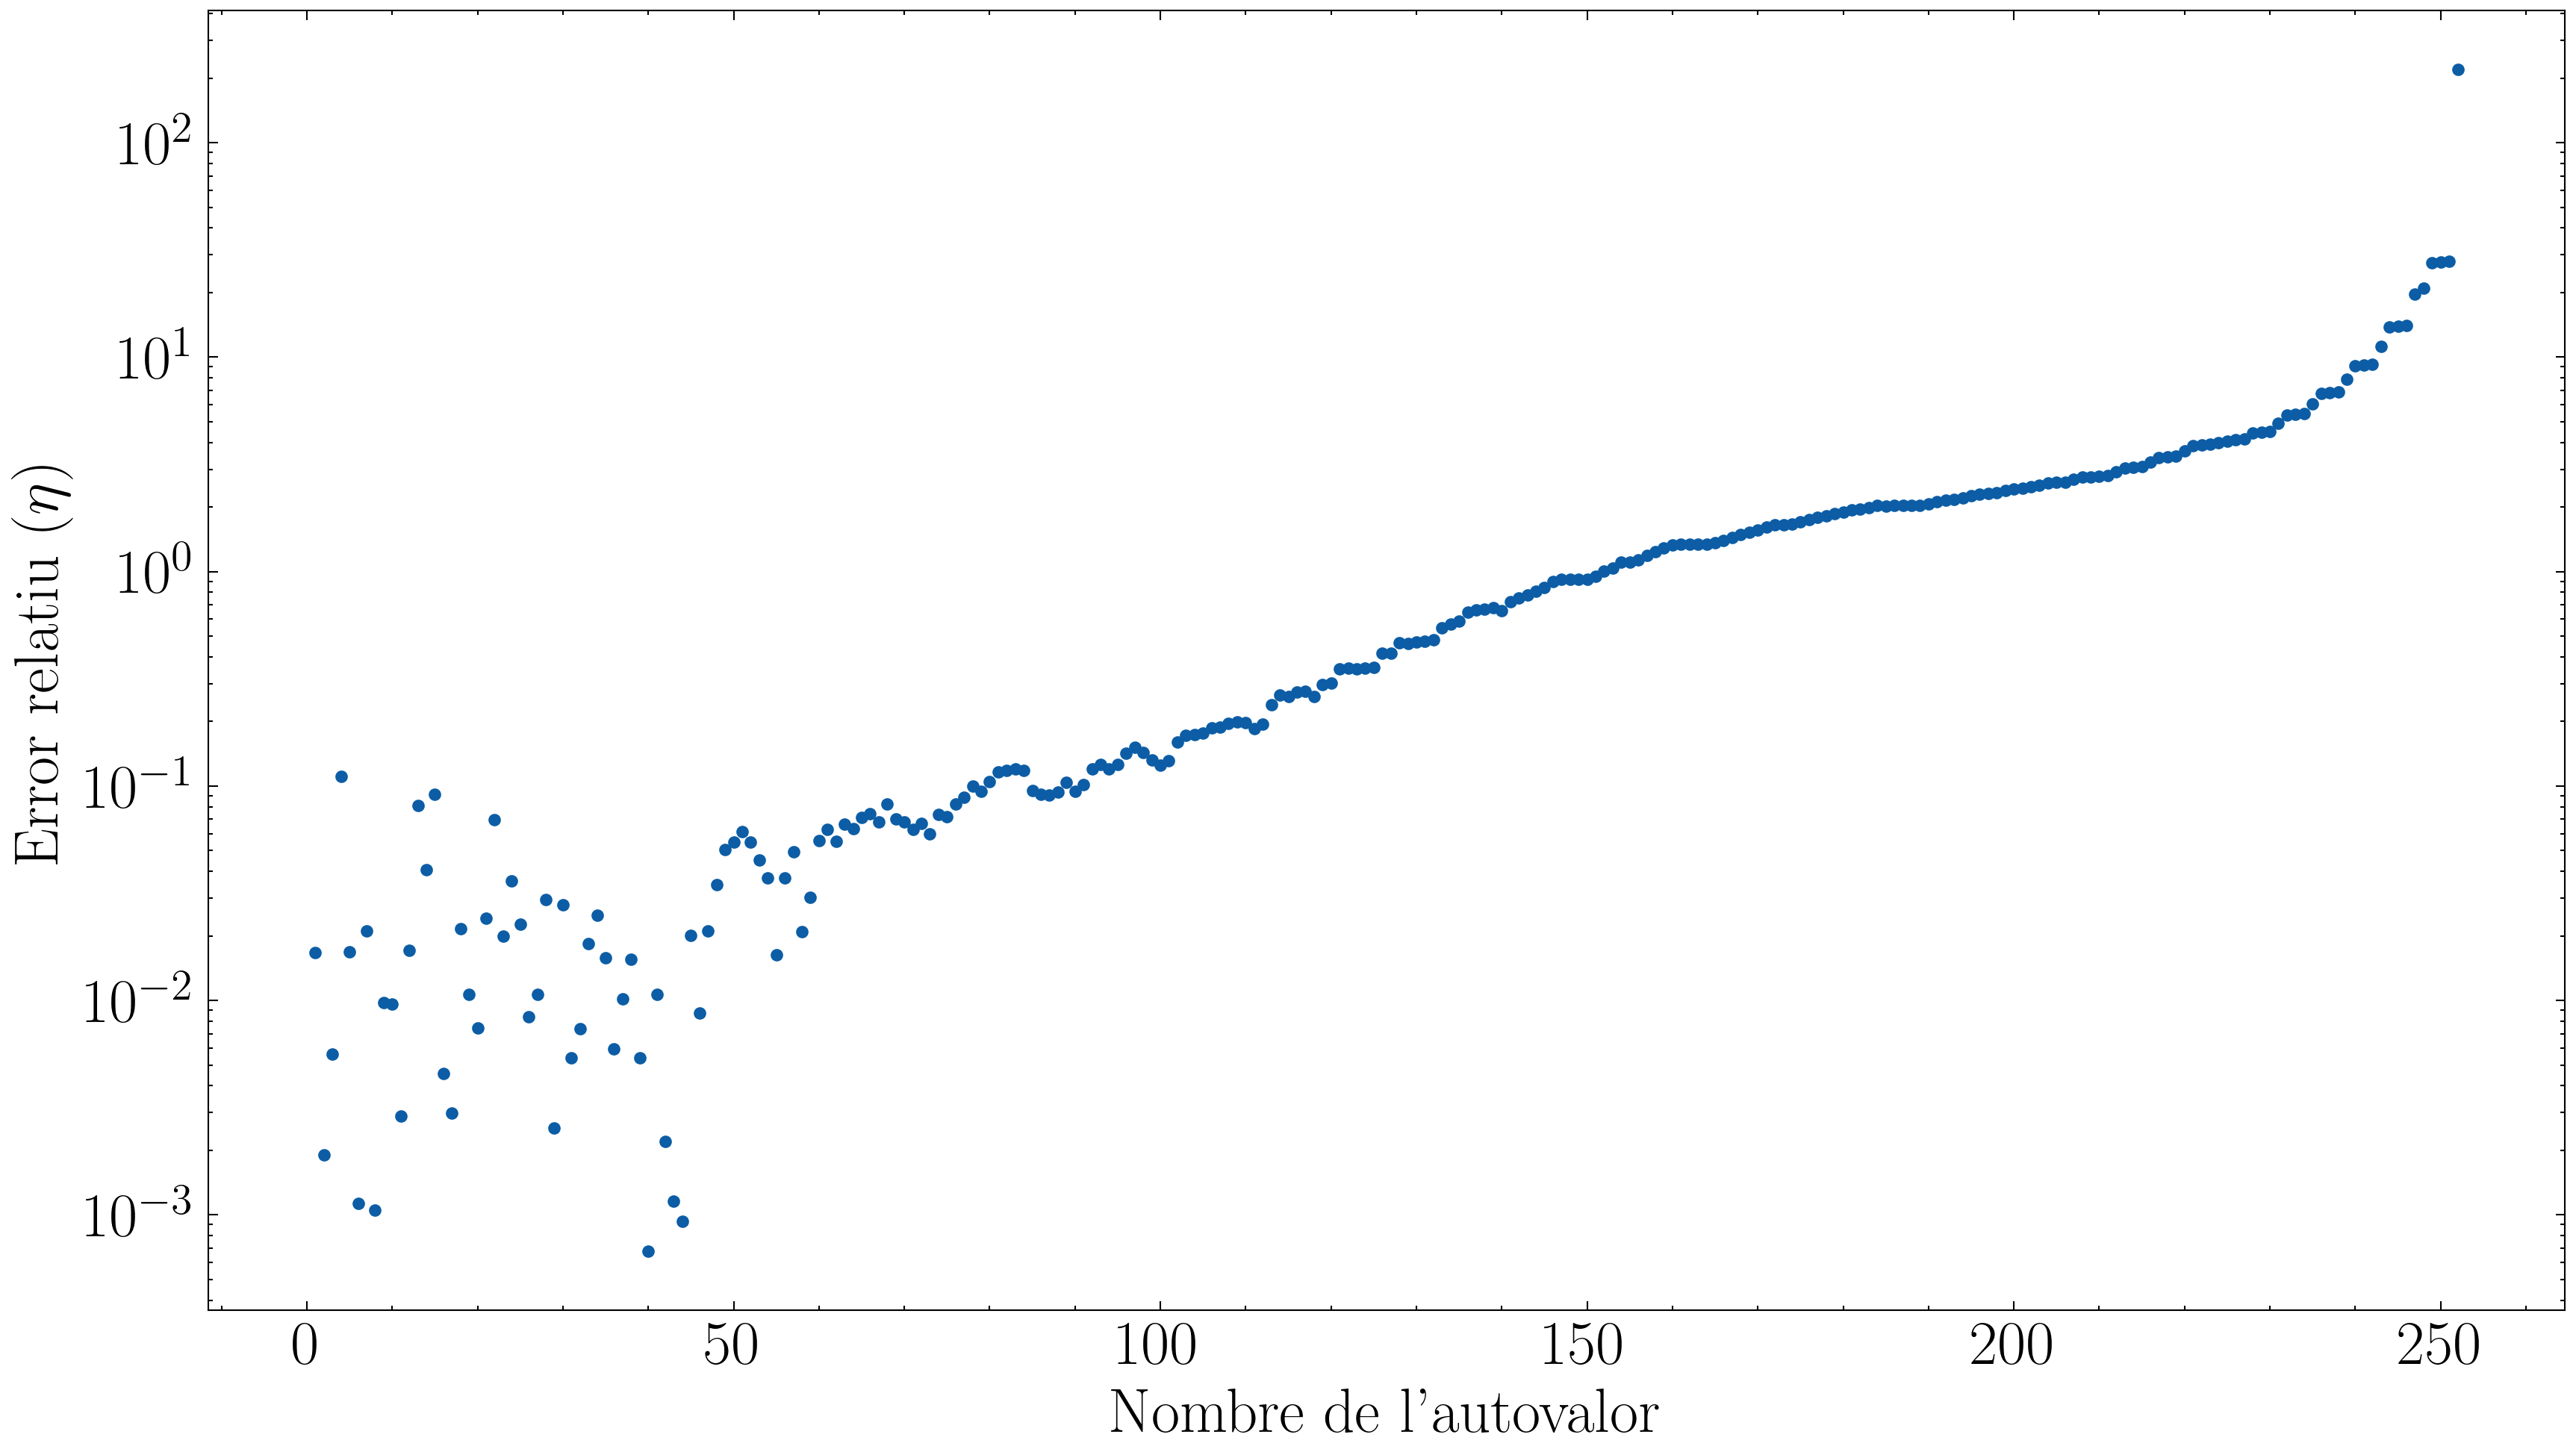

In [2]:
plt.figure(figsize=(12, 7))
plt.semilogy(n, relative_error, '.')
plt.xlabel("Nombre de l'autovalor")
plt.ylabel(fr"Error relatiu $(\eta)$")
plt.tight_layout()
plt.grid(False)
plt.plot()
#plt.savefig('eigenvalue_error.png', dpi=300, bbox_inches='tight')

# Representació de les autofuncions

Maximum value is ug = -1.0955349173665372 and minimum value is wg = 3.578246090623908e-05
Maximum value is ug = -0.9786170597412787 and minimum value is wg = 0.0004569943527109831
Maximum value is ug = 1.075632498135162 and minimum value is wg = 5.189229375477014e-05
Maximum value is wg = 1.1288102006317433 and minimum value is ug = 0.0011124492144303955
kz = 0.01


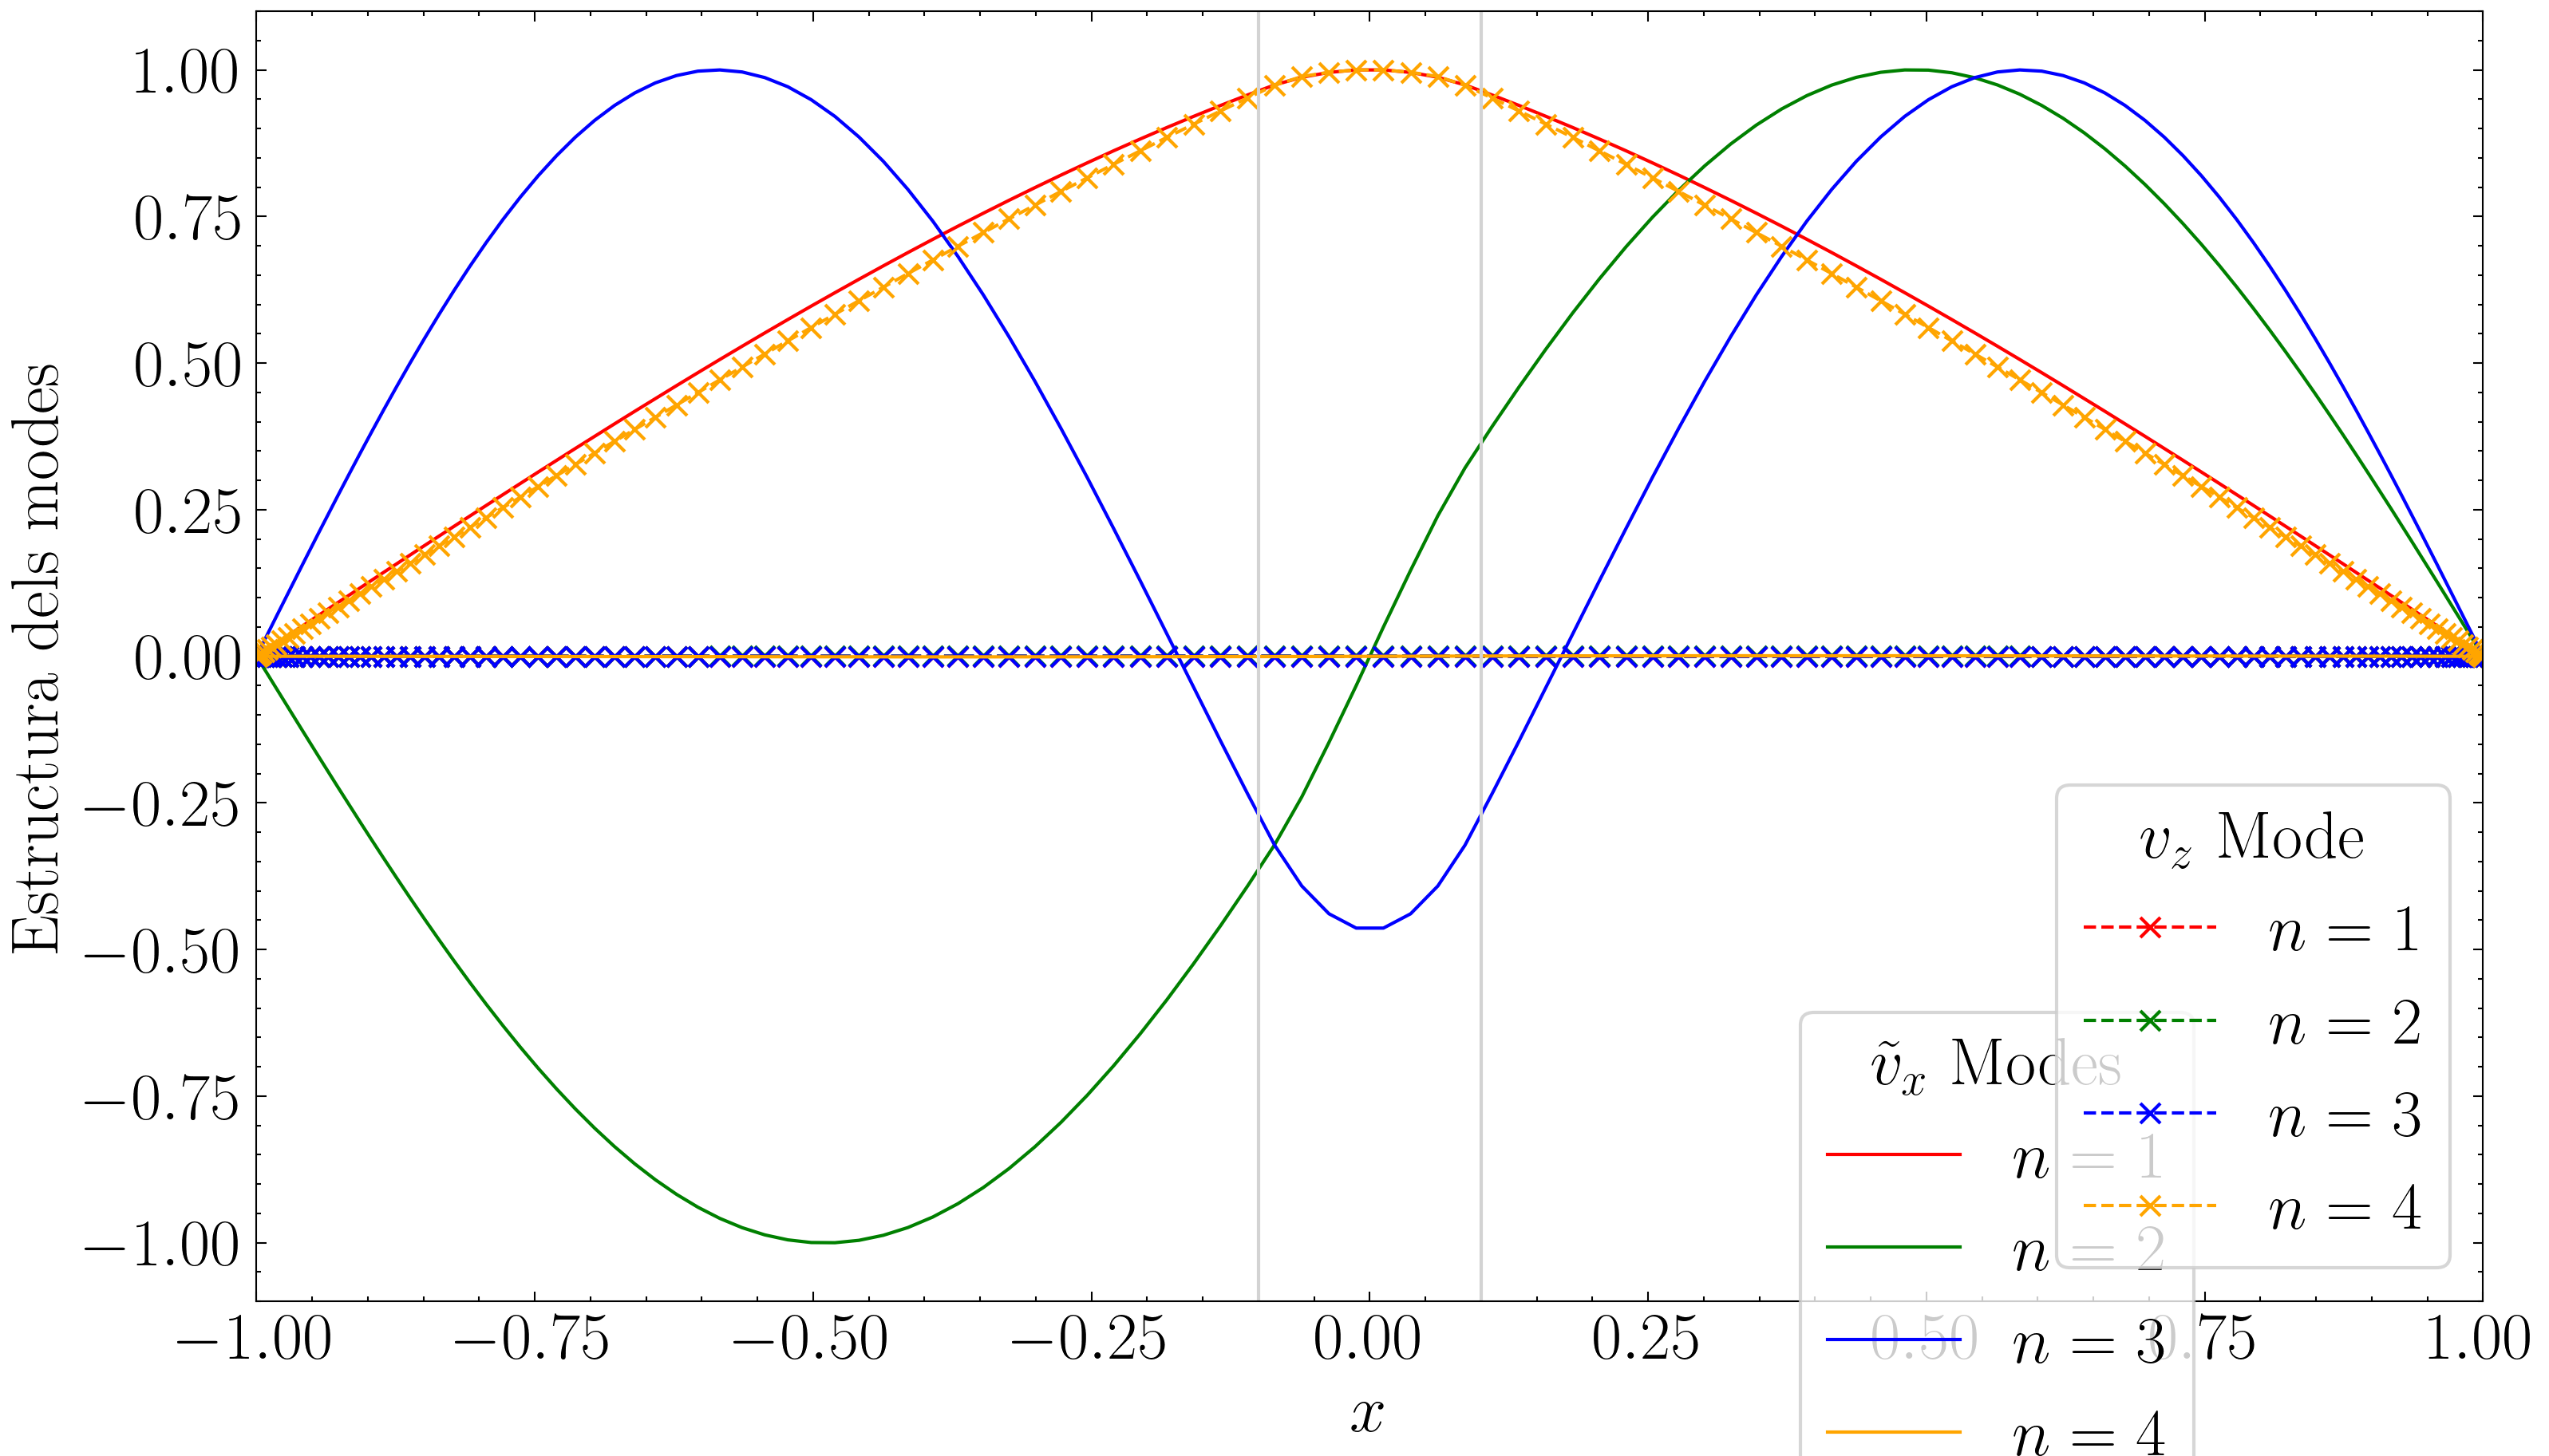

In [3]:
### Nombre de modes que volem representar ###
N_max_mode = 4
N_min_mode = 0
N_modes = N_max_mode - N_min_mode

### Define colors for the lines ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

### Create lists to store handles for legends ###
handles_v10x = []
handles_v10z = []

### Plot ug.real and wg.real and normalize to the maximum value ###
x = dist.local_grid(xbasis)
plt.figure(figsize=(12, 7))
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Find the maximum absolute value between ug and wg
    #max_val = np.max(np.abs(np.concatenate([ug, wg])))

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Print the maximum value
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        print("Maximum value is ug =", max_val,"and minimum value is wg =", np.max(np.abs(wg)))
    else:
        print("Maximum value is wg =", max_val,"and minimum value is ug =", np.max(np.abs(ug)))

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot v10x~ with warm colors and store the handle
    handle_v10x, = plt.plot(x, ug_normalized, label=fr"$n={n}$", color=colors[n % len(colors) - 1], linestyle='-')
    handles_v10x.append(handle_v10x)

    # Plot v10z with cold colors and store the handle
    handle_v10z, = plt.plot(x, wg_normalized, label=fr"$n={n}$", color=colors[n % len(colors) - 1], marker='x', linestyle='--')
    handles_v10z.append(handle_v10z)


## Create separate legends
legend_v10x = plt.legend(handles=handles_v10x, title=r"$\tilde{v}_{x}$ Modes", loc="upper right", bbox_to_anchor=(0.885, 0.25), frameon=True)
plt.gca().add_artist(legend_v10x)  # Add the first legend to the plot
plt.legend(handles=handles_v10z, title=r"$v_{z}$ Mode", loc="lower right", bbox_to_anchor=(1, 0), frameon=True)


# Add vertical lines to each subplot
plt.axvline(x=-0.1, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=0.1, color='lightgrey', linestyle='-', linewidth=1)


plt.xlim(-1, 1)
#plt.legend(loc="lower right", frameon=True)
plt.ylabel(r"Estructura dels modes")
plt.xlabel(r"$x$")
#plt.title(r"Parts reals normalitzades de $\tilde{v}_{x}$ i ${v}_{z}$")
plt.grid(False)
#plt.savefig('normalized_modes.png', dpi=300, bbox_inches='tight')
print("kz =",kz)
plt.show()

# A l'hora de representar la part real de les autofuncions has de tenir clar que la velocitat u és en la direcció x i la w en z. També que v10x és imaginària i v10z és real.
# A més, el que es representa és la velocitat, no la corda en sí. Llavors un node implica velocitat nul·la: aquell punt no es mou.
# Els màxims i mínims són els punts on la velocitat és màxima, no és que la corda es deformi amb aquella forma.

# Representació de les autofuncions per separat

Maximum value is from ug; max_val = -1.0955349173665372
Maximum value is from ug; max_val = -0.9786170597412787
Maximum value is from ug; max_val = 1.075632498135162
Maximum value is from wg; max_val = 1.1288102006317433
kz = 0.01


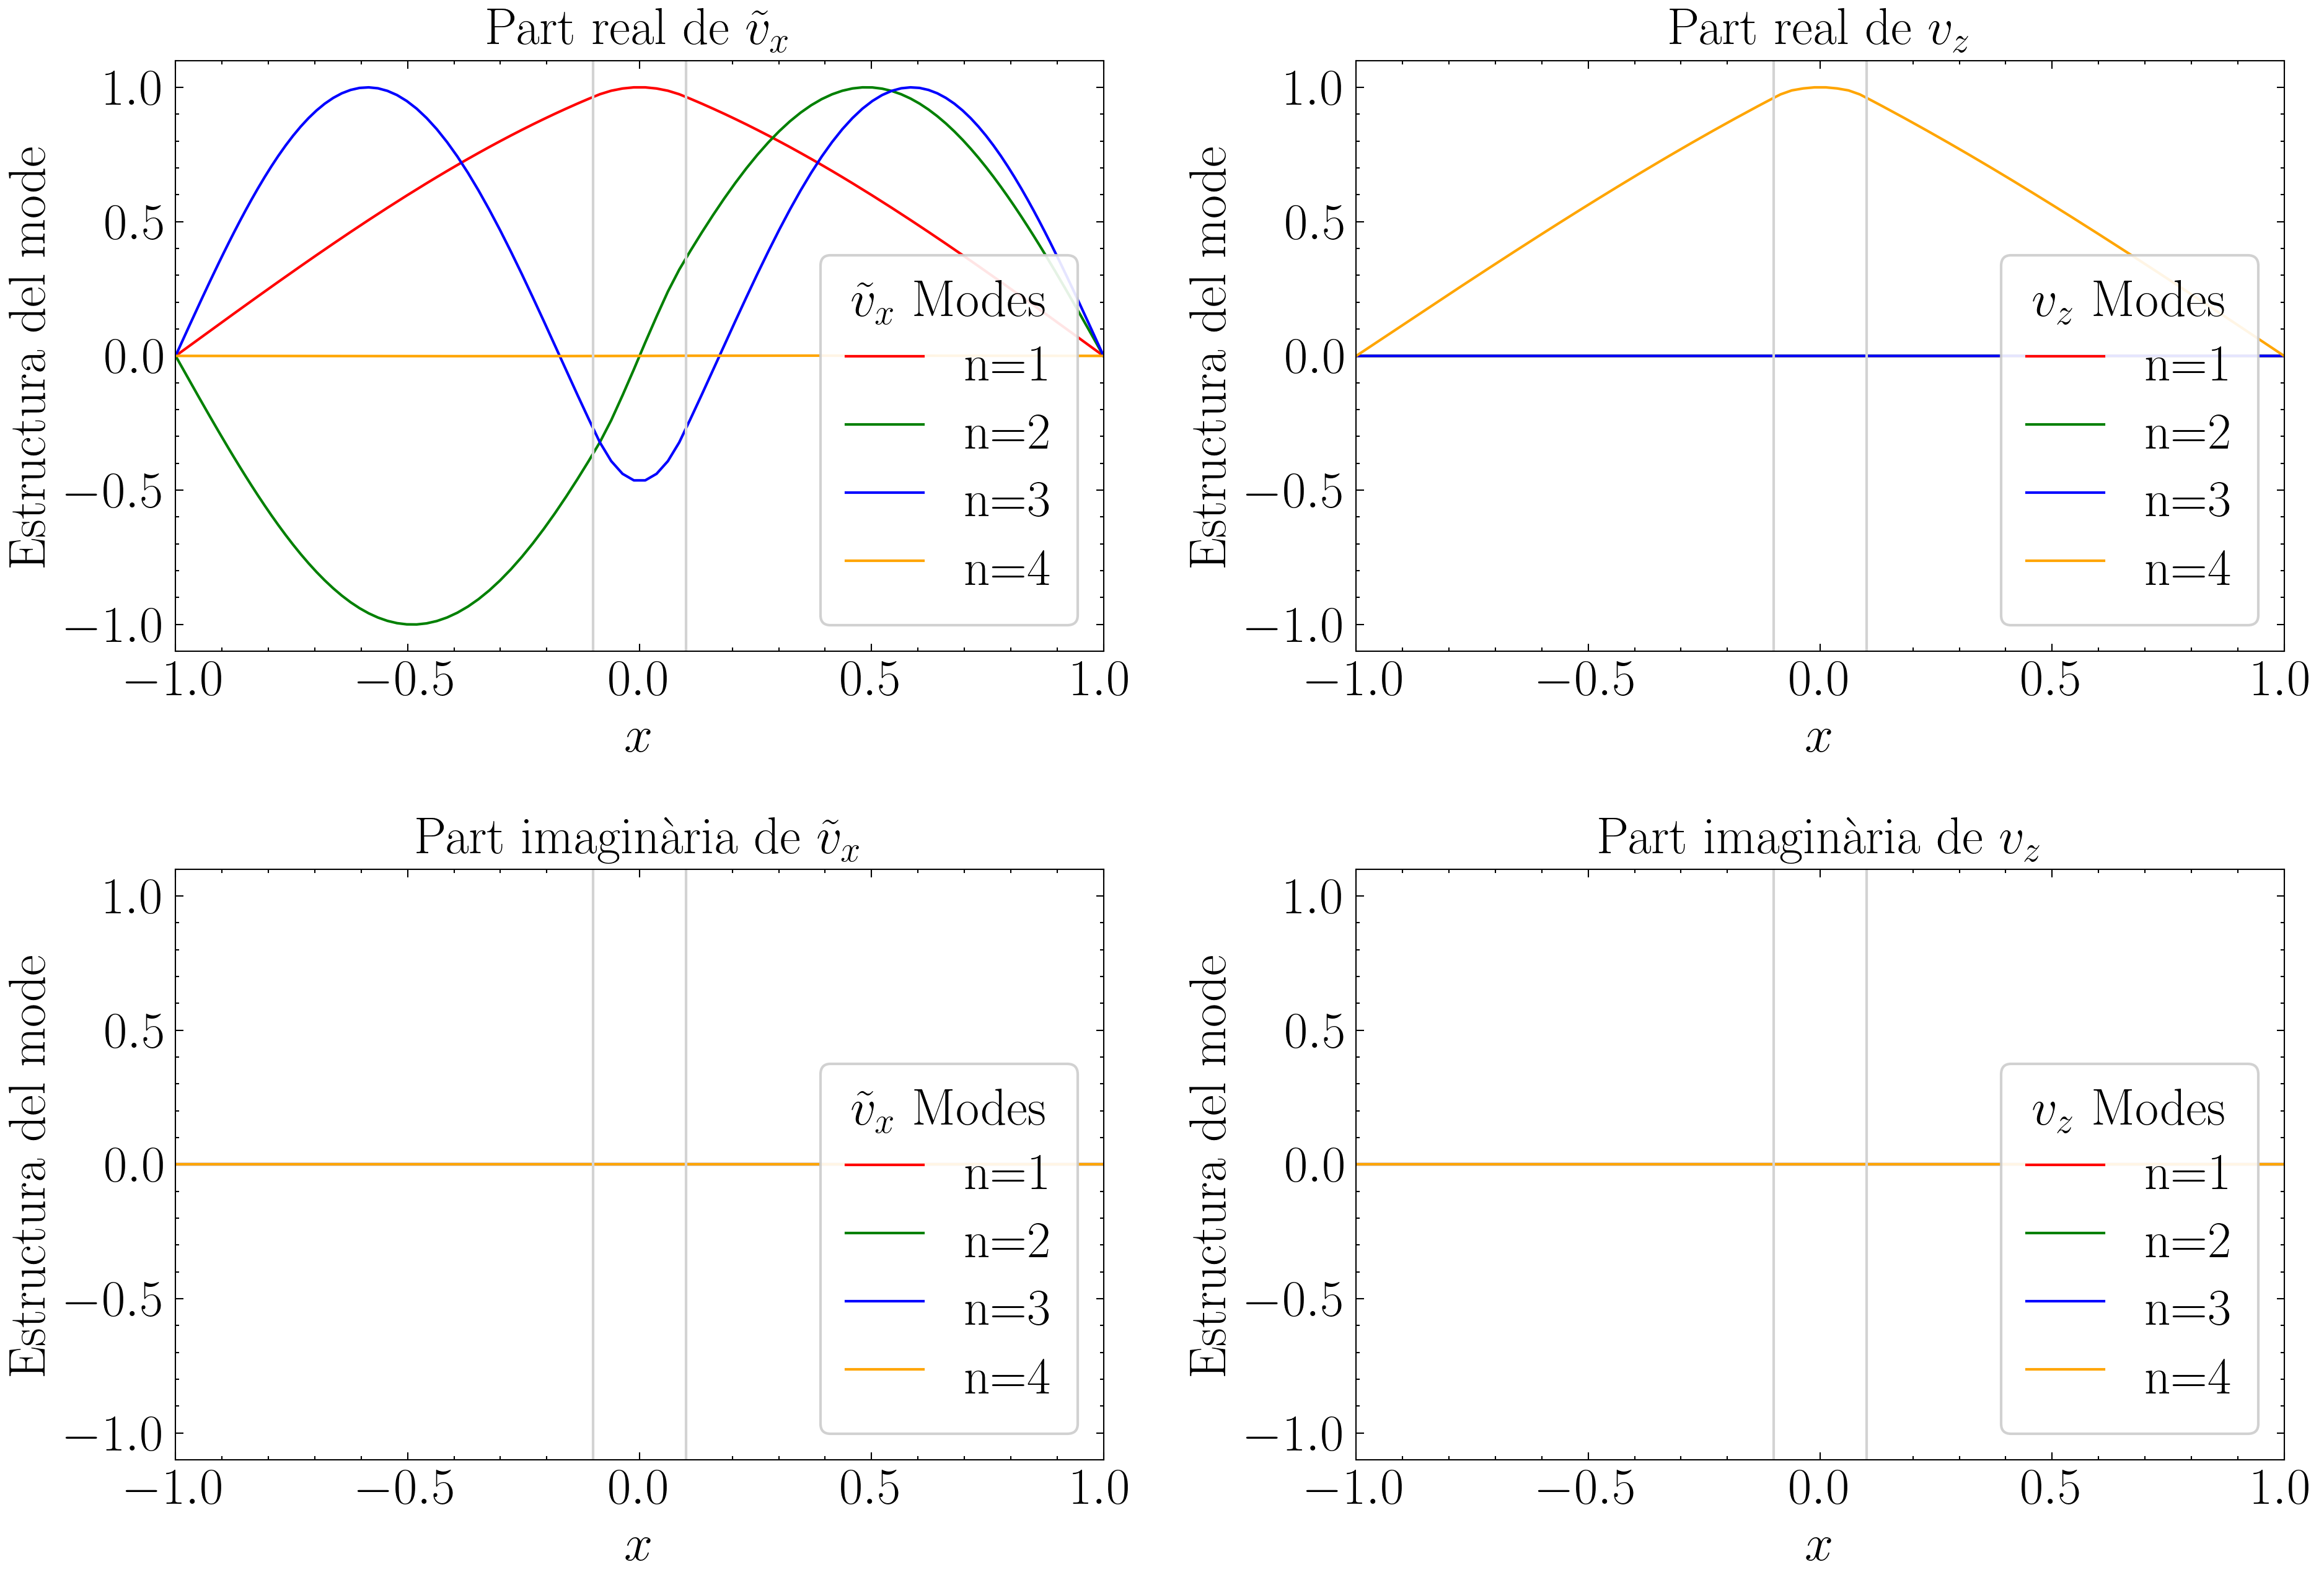

In [4]:
### Nombre de modes ###
N_max_mode = 4
N_min_mode = 0
N_modes = N_max_mode - N_min_mode

### Create a figure and a 2x2 grid of subplots ###
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

### Initialize lists to store handles for legends ###
handles_v10x_real = []
handles_v10x_imag = []
handles_v10z_real = []
handles_v10z_imag = []

### Plot real part of v10x~ ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Find the maximum absolute value between ug and wg
    #max_val = np.max(np.abs(np.concatenate([ug, wg])))

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Print the maximum value
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        print("Maximum value is from ug; max_val =", max_val)
    else:
        print("Maximum value is from wg; max_val =", max_val)

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val
    
    axs[0, 0].plot(x, ug_normalized, label=f"n={n}", color=colors[n % len(colors) - 1])
    
    # Alternativament:
    #axs[0, 0].plot(x, ug/np.max(np.abs(ug)), label=f"n={n}", color=colors_brg[n-1]) # és lo mateix amb aquestes definicions!
axs[0, 0].set_ylim(-1.1, 1.1)
axs[0, 0].set_xlim(-1, 1)
axs[0, 0].legend(loc="lower right", frameon=True, title=r"$\tilde{v}_{x}$ Modes", fontsize=20, title_fontsize=20, handlelength=1.5, handleheight=1.5, borderpad=0.5, borderaxespad=0.5, labelspacing=0.1, framealpha=0.9)
axs[0, 0].set_ylabel(r"Estructura del mode")
axs[0, 0].set_xlabel(r"$x$")
axs[0, 0].set_title(r"Part real de $\tilde{v}_{x}$") # idò és imaginària ---> desfassament temporal de 1/4 de període

### Plot imaginary part of v10x~ ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    ui_normalized = ui / max_val
    wg_normalized = wg / max_val

    axs[1, 0].plot(x, ui_normalized, label=f"n={n}", color=colors[n % len(colors) - 1])
axs[1, 0].set_ylim(-1.1, 1.1)
axs[1, 0].set_xlim(-1, 1)
axs[1, 0].legend(loc="lower right", frameon=True, title=r"$\tilde{v}_{x}$ Modes", fontsize=20, title_fontsize=20, handlelength=1.5, handleheight=1.5, borderpad=0.5, borderaxespad=0.5, labelspacing=0.1, framealpha=0.9)
axs[1, 0].set_ylabel(r"Estructura del mode")
axs[1, 0].set_xlabel(r"$x$")
axs[1, 0].set_title(r"Part imaginària de $\tilde{v}_{x}$") # idò és real ---> desfassament temporal de 1/4 de període



### Plot real part of v10z ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    axs[0, 1].plot(x, wg_normalized, label=f"n={n}", color=colors[n % len(colors) - 1])
axs[0, 1].set_ylim(-1.1, 1.1)
axs[0, 1].set_xlim(-1, 1)
axs[0, 1].legend(loc="lower right", frameon=True, title=r"${v}_{z}$ Modes", fontsize=20, title_fontsize=20, handlelength=1.5, handleheight=1.5, borderpad=0.5, borderaxespad=0.5, labelspacing=0.1, framealpha=0.9)
axs[0, 1].set_ylabel(r"Estructura del mode")
axs[0, 1].set_xlabel(r"$x$")
axs[0, 1].set_title(r"Part real de ${v}_{z}$")

### Plot imaginary part of v10z ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val
    wi_normalized = wi / max_val
    
    axs[1, 1].plot(x, wi_normalized, label=f"n={n}", color=colors[n % len(colors) - 1])
axs[1, 1].set_ylim(-1.1, 1.1)
axs[1, 1].set_xlim(-1, 1)
axs[1, 1].legend(loc="lower right", frameon=True, title=r"${v}_{z}$ Modes", fontsize=20, title_fontsize=20, handlelength=1.5, handleheight=1.5, borderpad=0.5, borderaxespad=0.5, labelspacing=0.1, framealpha=0.9)
axs[1, 1].set_ylabel(r"Estructura del mode")
axs[1, 1].set_xlabel(r"$x$")
axs[1, 1].set_title(r"Part imaginària de ${v}_{z}$")

# Add vertical lines to each subplot
for ax in axs.flat:
    ax.axvline(x=-0.1, color='lightgrey', linestyle='-', linewidth=1)
    ax.axvline(x=0.1, color='lightgrey', linestyle='-', linewidth=1)

print("kz =",kz)

plt.tight_layout()
plt.show()

#fig.savefig("Autofuncions_individuals.png", dpi=300, bbox_inches='tight')

Maximum value is from ug; max_val = -1.0955349173665372
Maximum value is from ug; max_val = 0.9786170597412787
Maximum value is from ug; max_val = 1.075632498135162
Maximum value is from wg; max_val = 1.1288102006317433
kz = 0.01


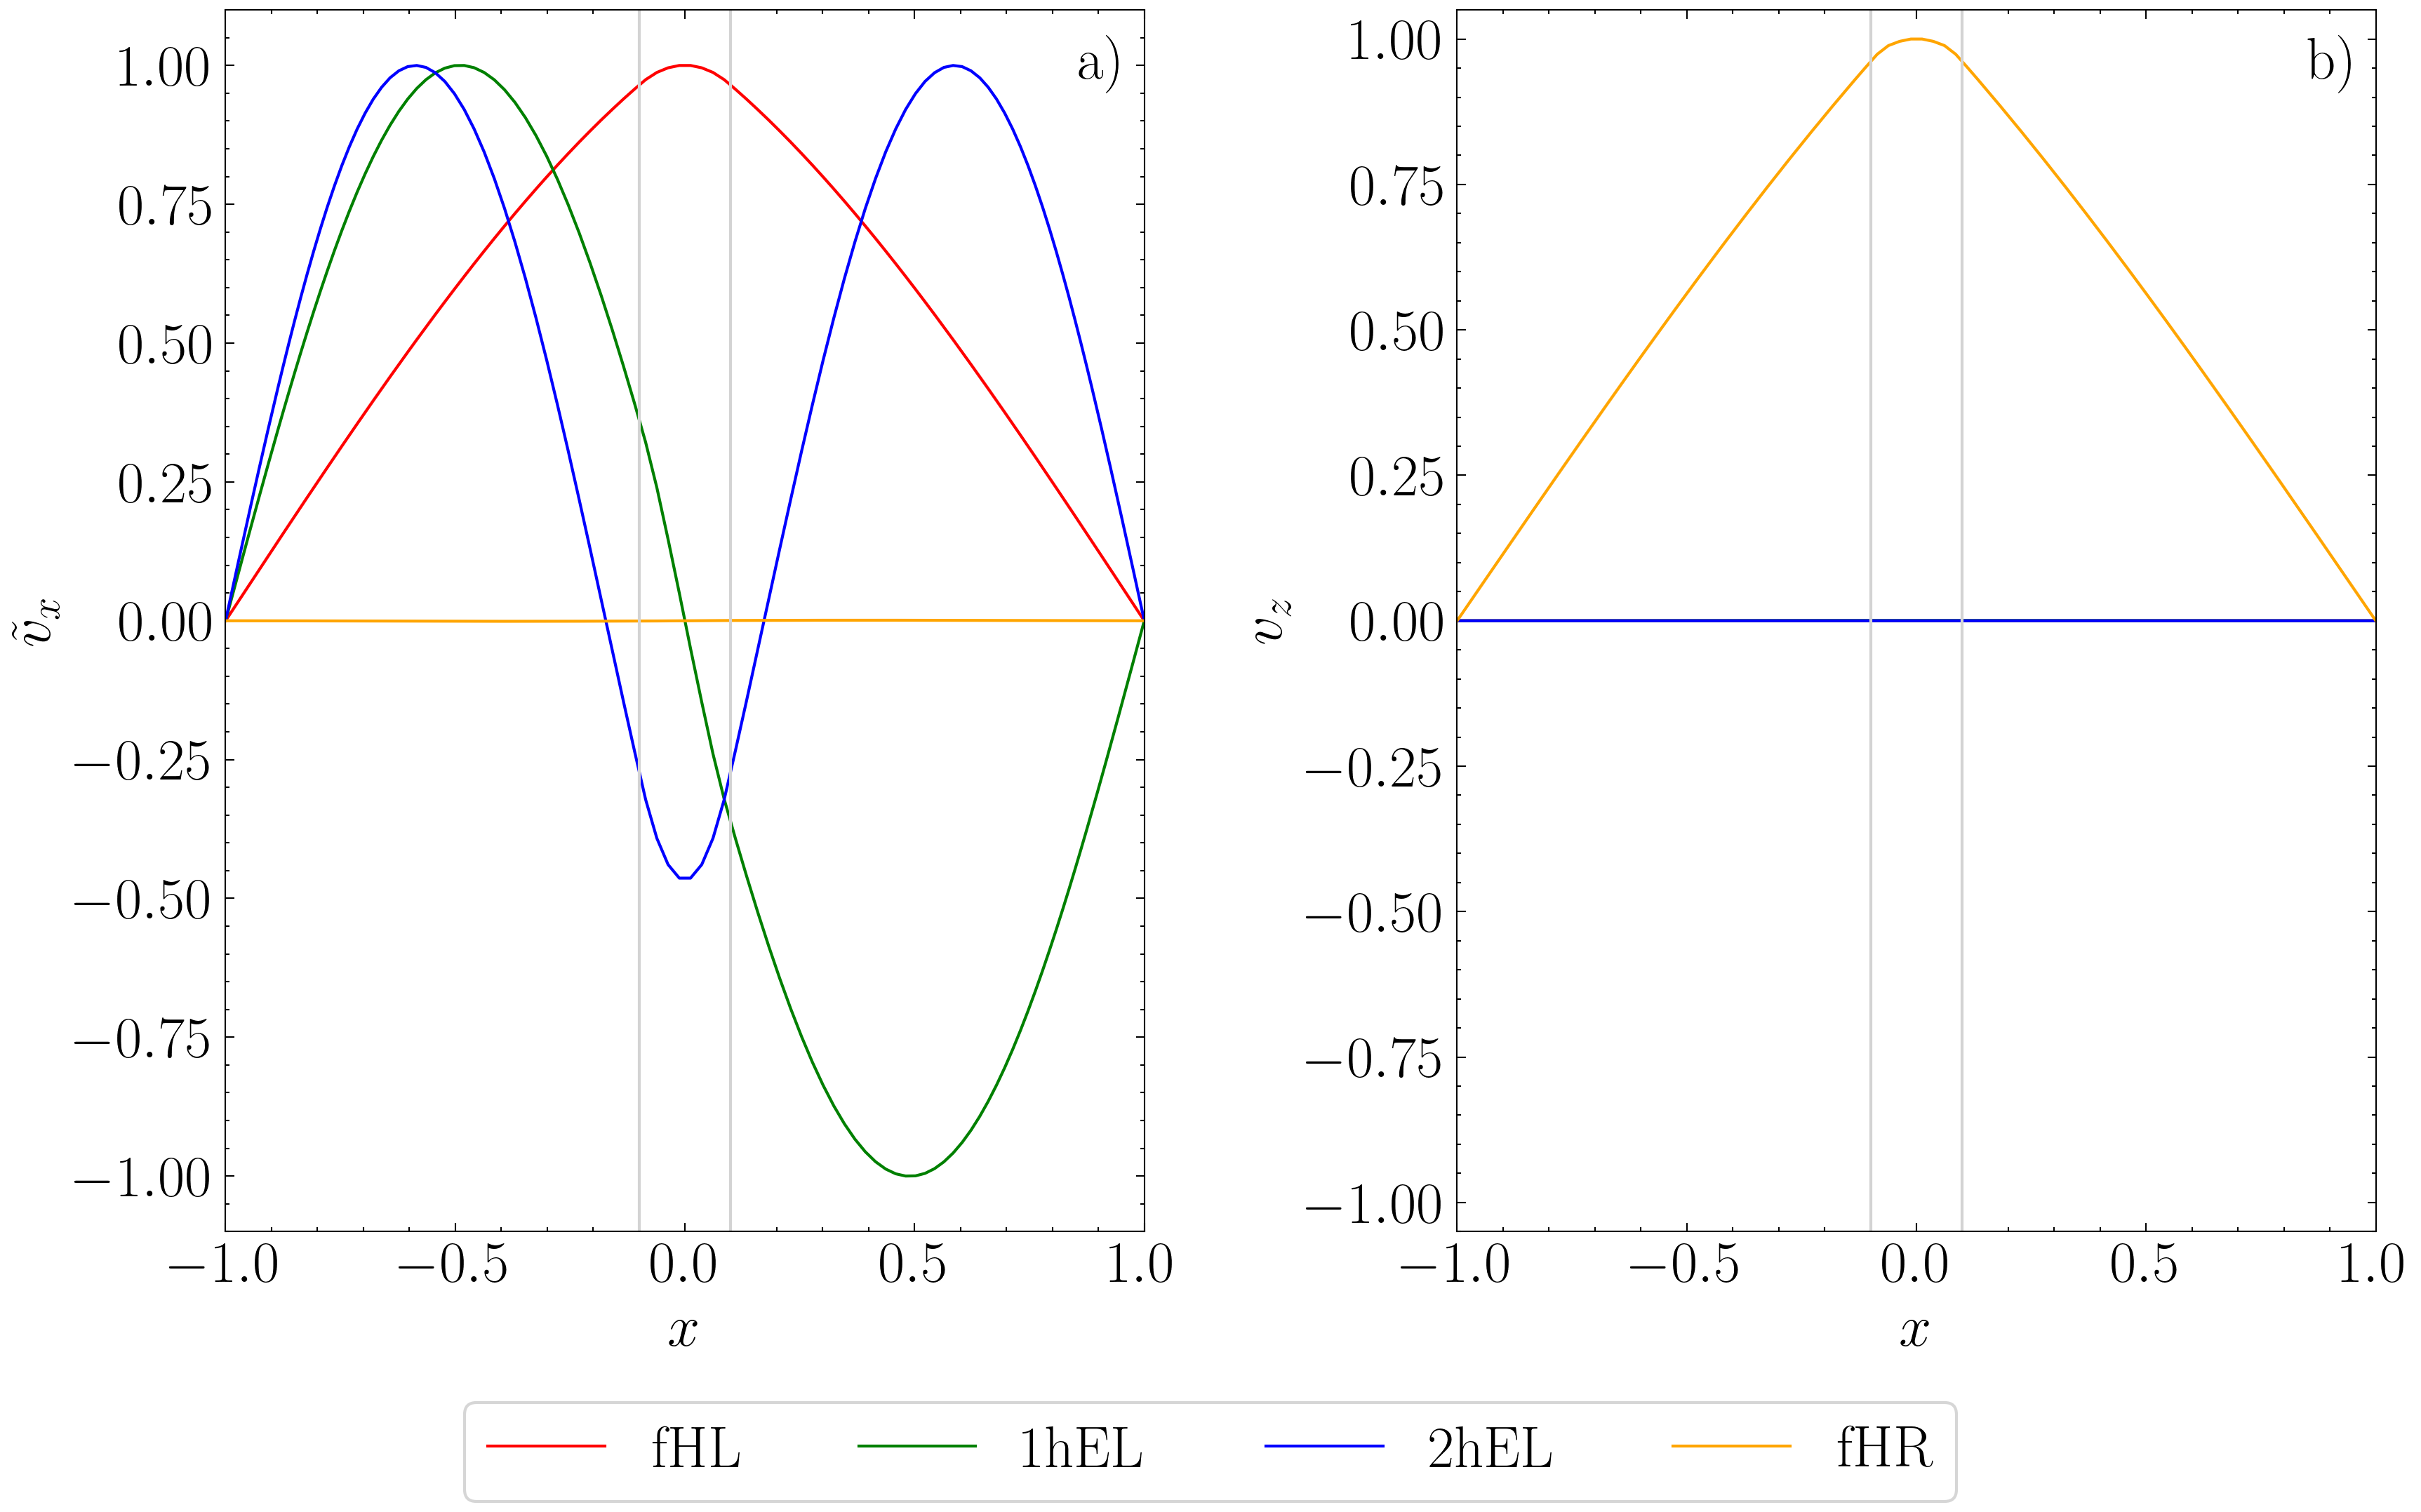

In [5]:
### Nombre de modes ###
N_max_mode = 4
N_min_mode = 0
N_modes = N_max_mode - N_min_mode

### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))

### Define colors for the lines ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

# Example labels for the first 7 modes
mode_labels = [
    r"fHL",
    r"1hEL",
    r"2hEL",
    r"fHR",
    r"3hEL",
    r"4hEL",
    r"5hIL",
]

### Plot real part of v10x~ ###
x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        
        if n == 2:
            aux = -ug
        else:
            aux = ug

    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Print the maximum value
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        print("Maximum value is from ug; max_val =", max_val)
    else:
        print("Maximum value is from wg; max_val =", max_val)

    # Normalize both ug by the maximum value
    ug_normalized = ug / max_val

    axs[0].plot(x, ug_normalized, label=mode_labels[n-1], color=colors[n % len(colors) - 1])
axs[0].set_ylim(-1.1, 1.1)
axs[0].set_xlim(-1, 1)
axs[0].set_ylabel(r"$\tilde{v}_{x}$")
axs[0].set_xlabel(r"$x$")


x = dist.local_grid(xbasis)
for n, idx in enumerate(np.argsort(solver.eigenvalues)[N_min_mode:N_max_mode], start=1):
    solver.set_state(idx, solver.subsystems[0])
    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        
        aux = ug
    
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]
    
    # Normalize wg by the maximum value
    wg_normalized = wg / max_val

    axs[1].plot(x, wg_normalized, label=mode_labels[n-1], color=colors[n % len(colors) - 1])
axs[1].set_ylim(-1.05, 1.05)
axs[1].set_xlim(-1, 1)
axs[1].set_ylabel(r"${v}_{z}$")
axs[1].set_xlabel(r"$x$")


# Add vertical lines to each subplot
for ax in axs.flat:
    ax.axvline(x=-0.1, color='lightgrey', linestyle='-', linewidth=1)
    ax.axvline(x=0.1, color='lightgrey', linestyle='-', linewidth=1)

# Add labels to the subplots
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

fig.legend(
    handles=axs[0].get_lines()[N_min_mode:N_max_mode],  # Use lines from the first subplot (they share labels/colors)
    labels=mode_labels[:N_max_mode],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=4,  # Adjust columns as needed
    frameon=True,
    fontsize=20,
    title_fontsize=20
)

print("kz =",kz)
#plt.savefig("Autofuncions_reals_individuals.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



# Representació d'un mode en funció de kz

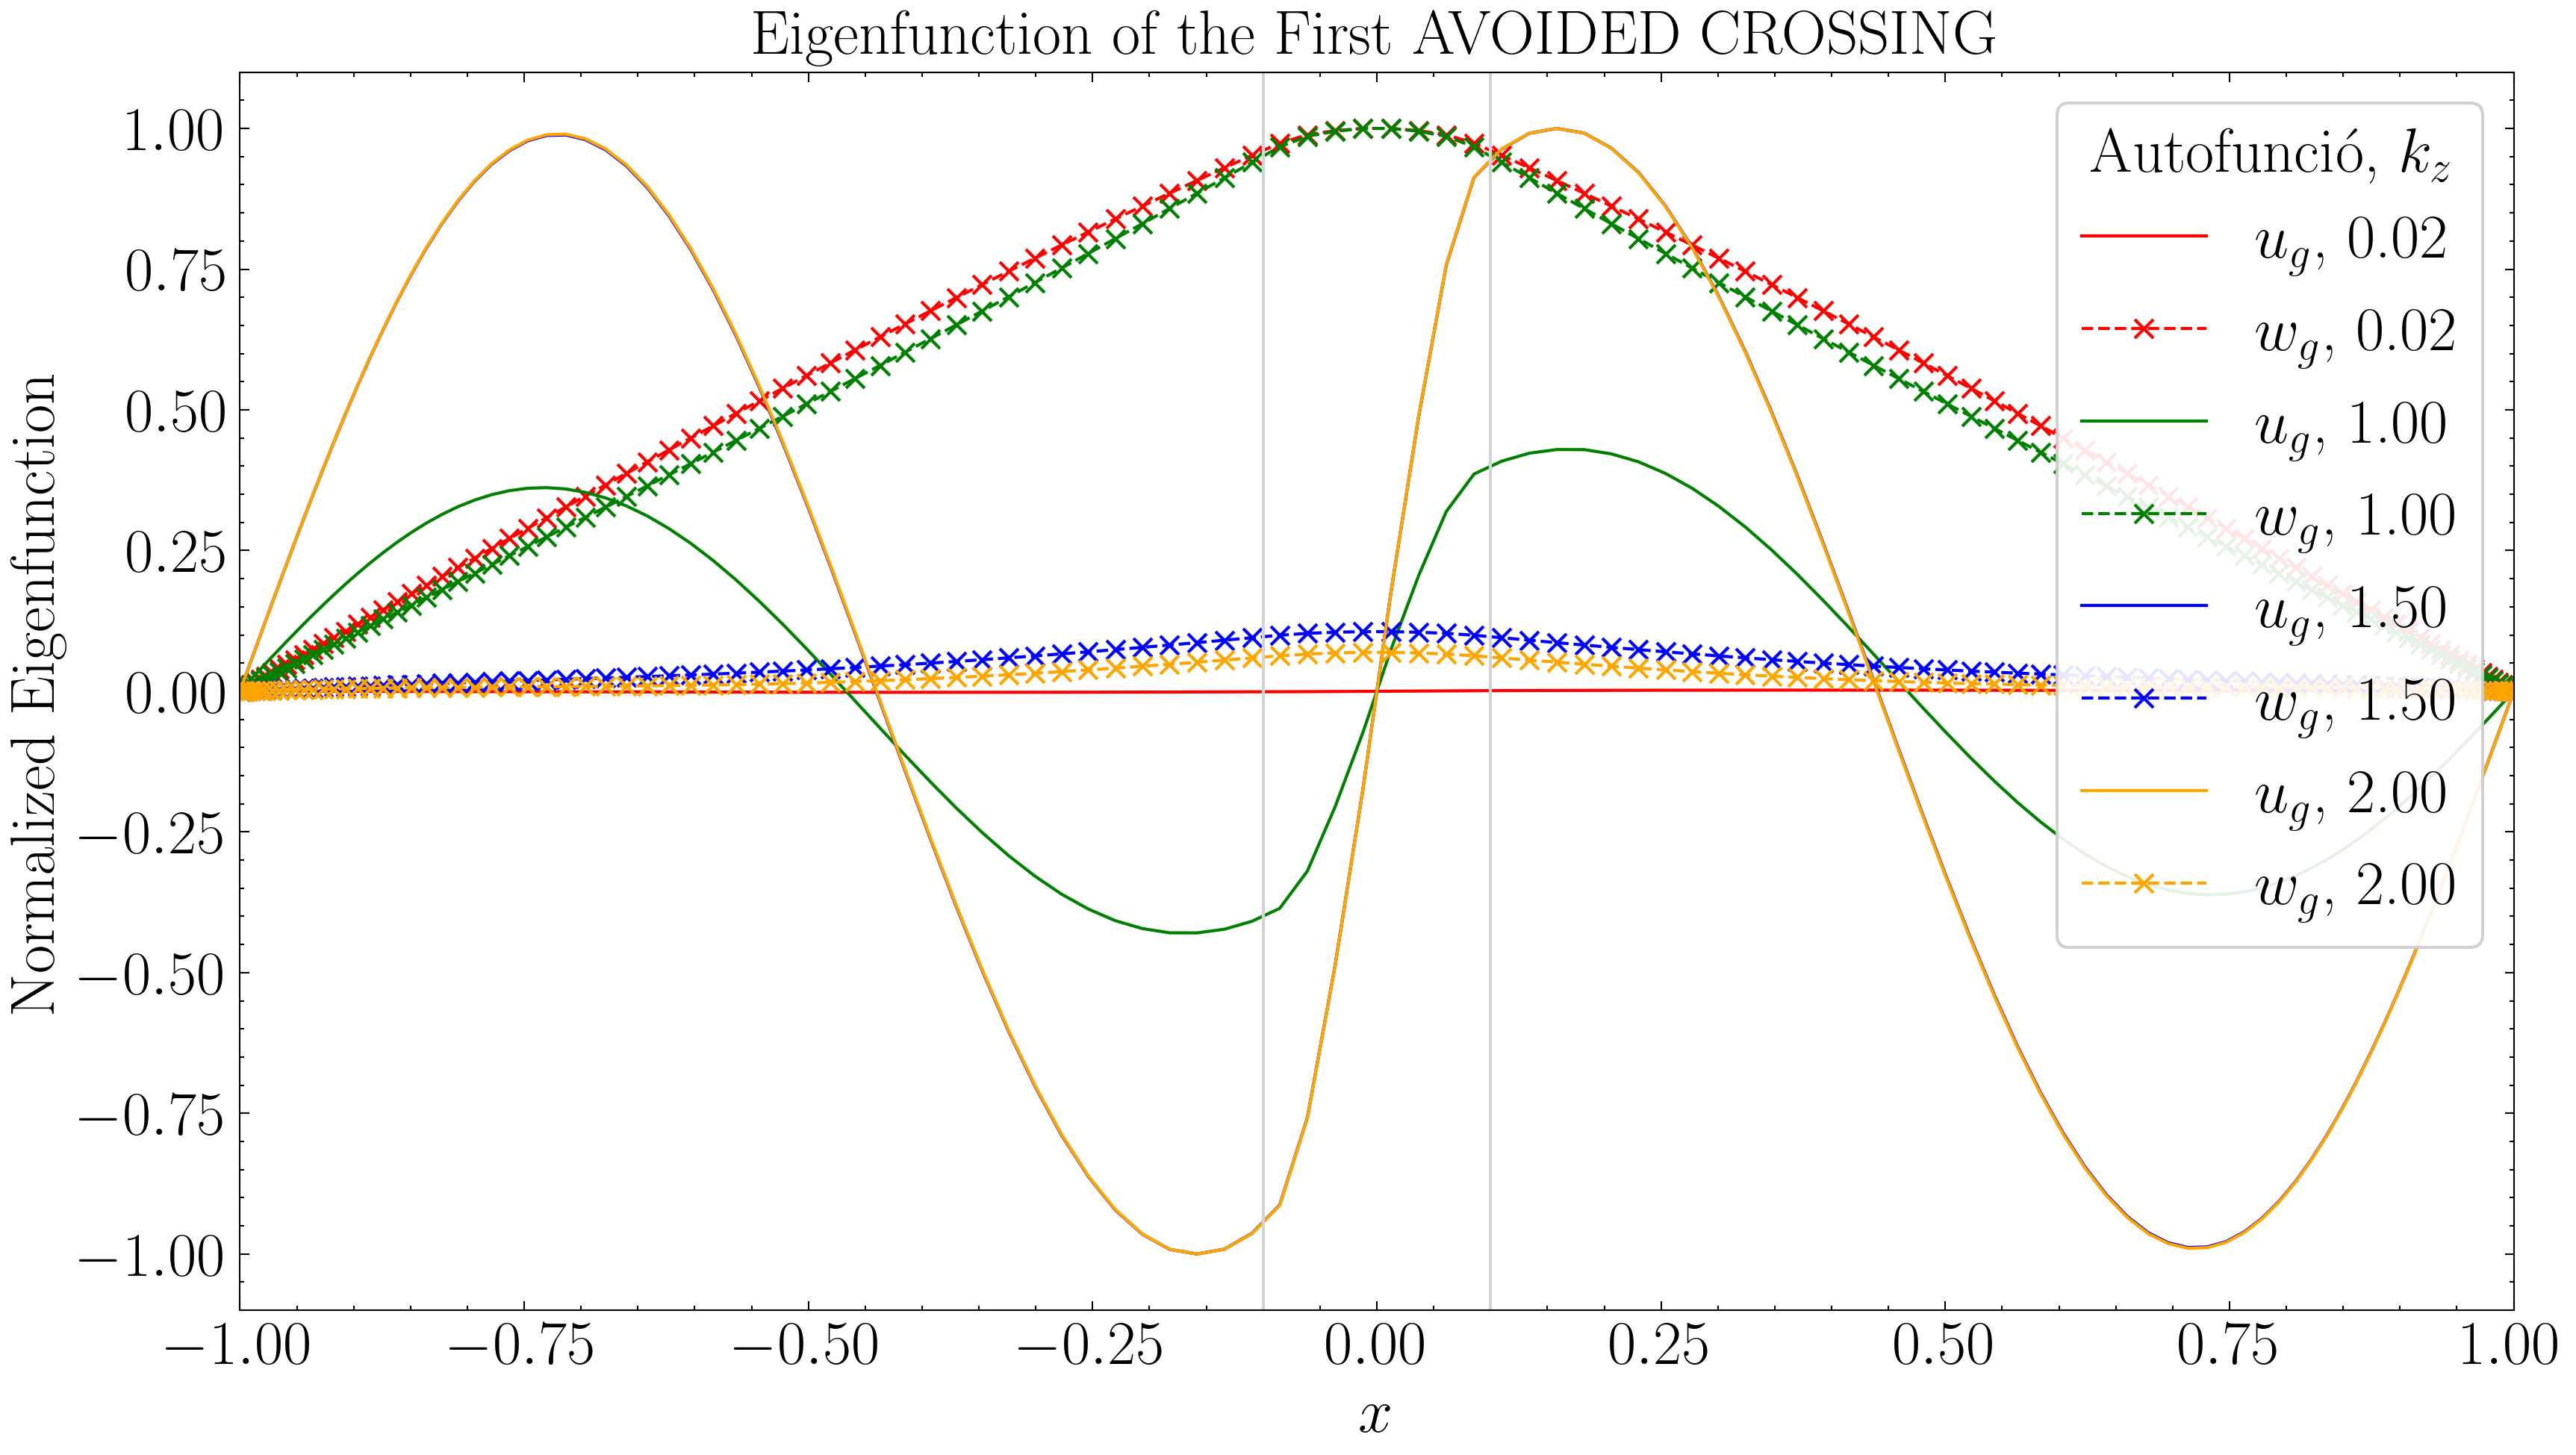

In [ ]:
import dedalus.public as d3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from scipy.optimize import fsolve
import logging
logging.getLogger().setLevel(logging.WARNING)
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "font.size": 20,           # Match LaTeX body text (12pt)
    "axes.titlesize": 20,      # Title font size
    "axes.labelsize": 20,      # Axis label font size
    "xtick.labelsize": 20,     # X tick label font size
    "ytick.labelsize": 20,     # Y tick label font size
    "legend.fontsize": 20,     # Legend font size
    "figure.dpi": 300,         # High DPI for sharpness
    "font.family": "serif",    # Optional: match LaTeX font
    "mathtext.fontset": "cm",  # Optional: Computer Modern math
    "text.usetex": True,                # Use LaTeX for all text
    "font.serif": ["Computer Modern"],  # Use Computer Modern (LaTeX default)
})


""" Paràmetres """
Nx = 128 # amb 32 ja no és smooth...
dtype = np.complex128 # malla en la que es treballa: 128 complexes, ja que hem definit Nx = 128



""" Límits del domini """
xmax = 1
xmin = -1 # = -xmax
# Position of boundaries between different parts of the system (prominence and corona).
xp = 0.1
# xc ∈ [-1, -0.1], xc ∈ [0.1, 1]



""" Constants """
### Velocitats a trossos ###
cp2 = 1 # 12 ### 1
cc2 = 6 # 166 ### 6
vAp2 = 20 # 60 to 100 ### 9
vAc2 = 250 #250 # 1400 ### 36 - NO!
# Valors realistes: cp2, cc2, vAp2, vAc2  137724550.89820358 27544910179.640717 3978873577.297384 795774715459.4768

### Redefinim camps ### -------- TALV VEGADA INFLUEIXEN EN ELS RESULTATS D'UN MODE SEGONS KZ...
c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2, cp2, cc2]) # Representa la c^2 en l'espai real ('g') a trossos.
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Nombre de kz's ###
Nkz = 151 # Nombre de kz's
kz_list = np.linspace(0, 3, Nkz) # Hi ha Nkz's separats equidistantment entre 0 i 3



""" Relació de dispersió """
### Inicialitza evals_k amb la mida correcta ###
evals_k = np.zeros((kz_list.size, len(solver.eigenvalues)), dtype=np.complex128)

plt.figure(figsize=(12, 7))

### Bucle per resolre el problema per cada kz ###
for ik, kz in enumerate(kz_list):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0") # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0") # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])

    evals_k[ik, :] = np.sort(solver.eigenvalues)

    # Extract the first eigenvalue and its corresponding eigenfunction
    n_mode_idx = np.argsort(solver.eigenvalues)[3]  # Index del mode # provar amb el 4t...
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the  desired mode

    # Extract the eigenfunctions
    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        
        if kz >= 1 and kz <= 1.9:
            aux = -ug
        else:
            aux = ug
    else:
        aux = wg

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot only for specific kz values
    if kz in [0.01, 0.02, 1, 1.5, 2]:

        # Plot ug
        plt.plot(x, ug_normalized, label=f"$u_g$, {kz:.2f}", linestyle='-', color=colors[ik % len(colors) - 1])
    
        # Plot wg
        plt.plot(x, wg_normalized, label=f"$w_g$, {kz:.2f}", linestyle='--', marker='x', color=colors[ik % len(colors) - 1])

# Add labels, legend, and title
plt.xlabel("$x$")
plt.ylabel("Normalized Eigenfunction")
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.title("Eigenfunction of the First AVOIDED CROSSING")
plt.legend(title=fr"Autofunció, $k_z$", loc="upper right", frameon=True, fontsize=20, framealpha=0.9)
plt.grid(False)
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)
#plt.savefig('eigenfunction_kz.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Relació de dispersió

<>:60: SyntaxWarning: invalid escape sequence '\o'
<>:60: SyntaxWarning: invalid escape sequence '\o'
/var/folders/pr/429w6vjs7g15jgb94g5_03_40000gn/T/ipykernel_64520/4067952843.py:60: SyntaxWarning: invalid escape sequence '\o'
  """


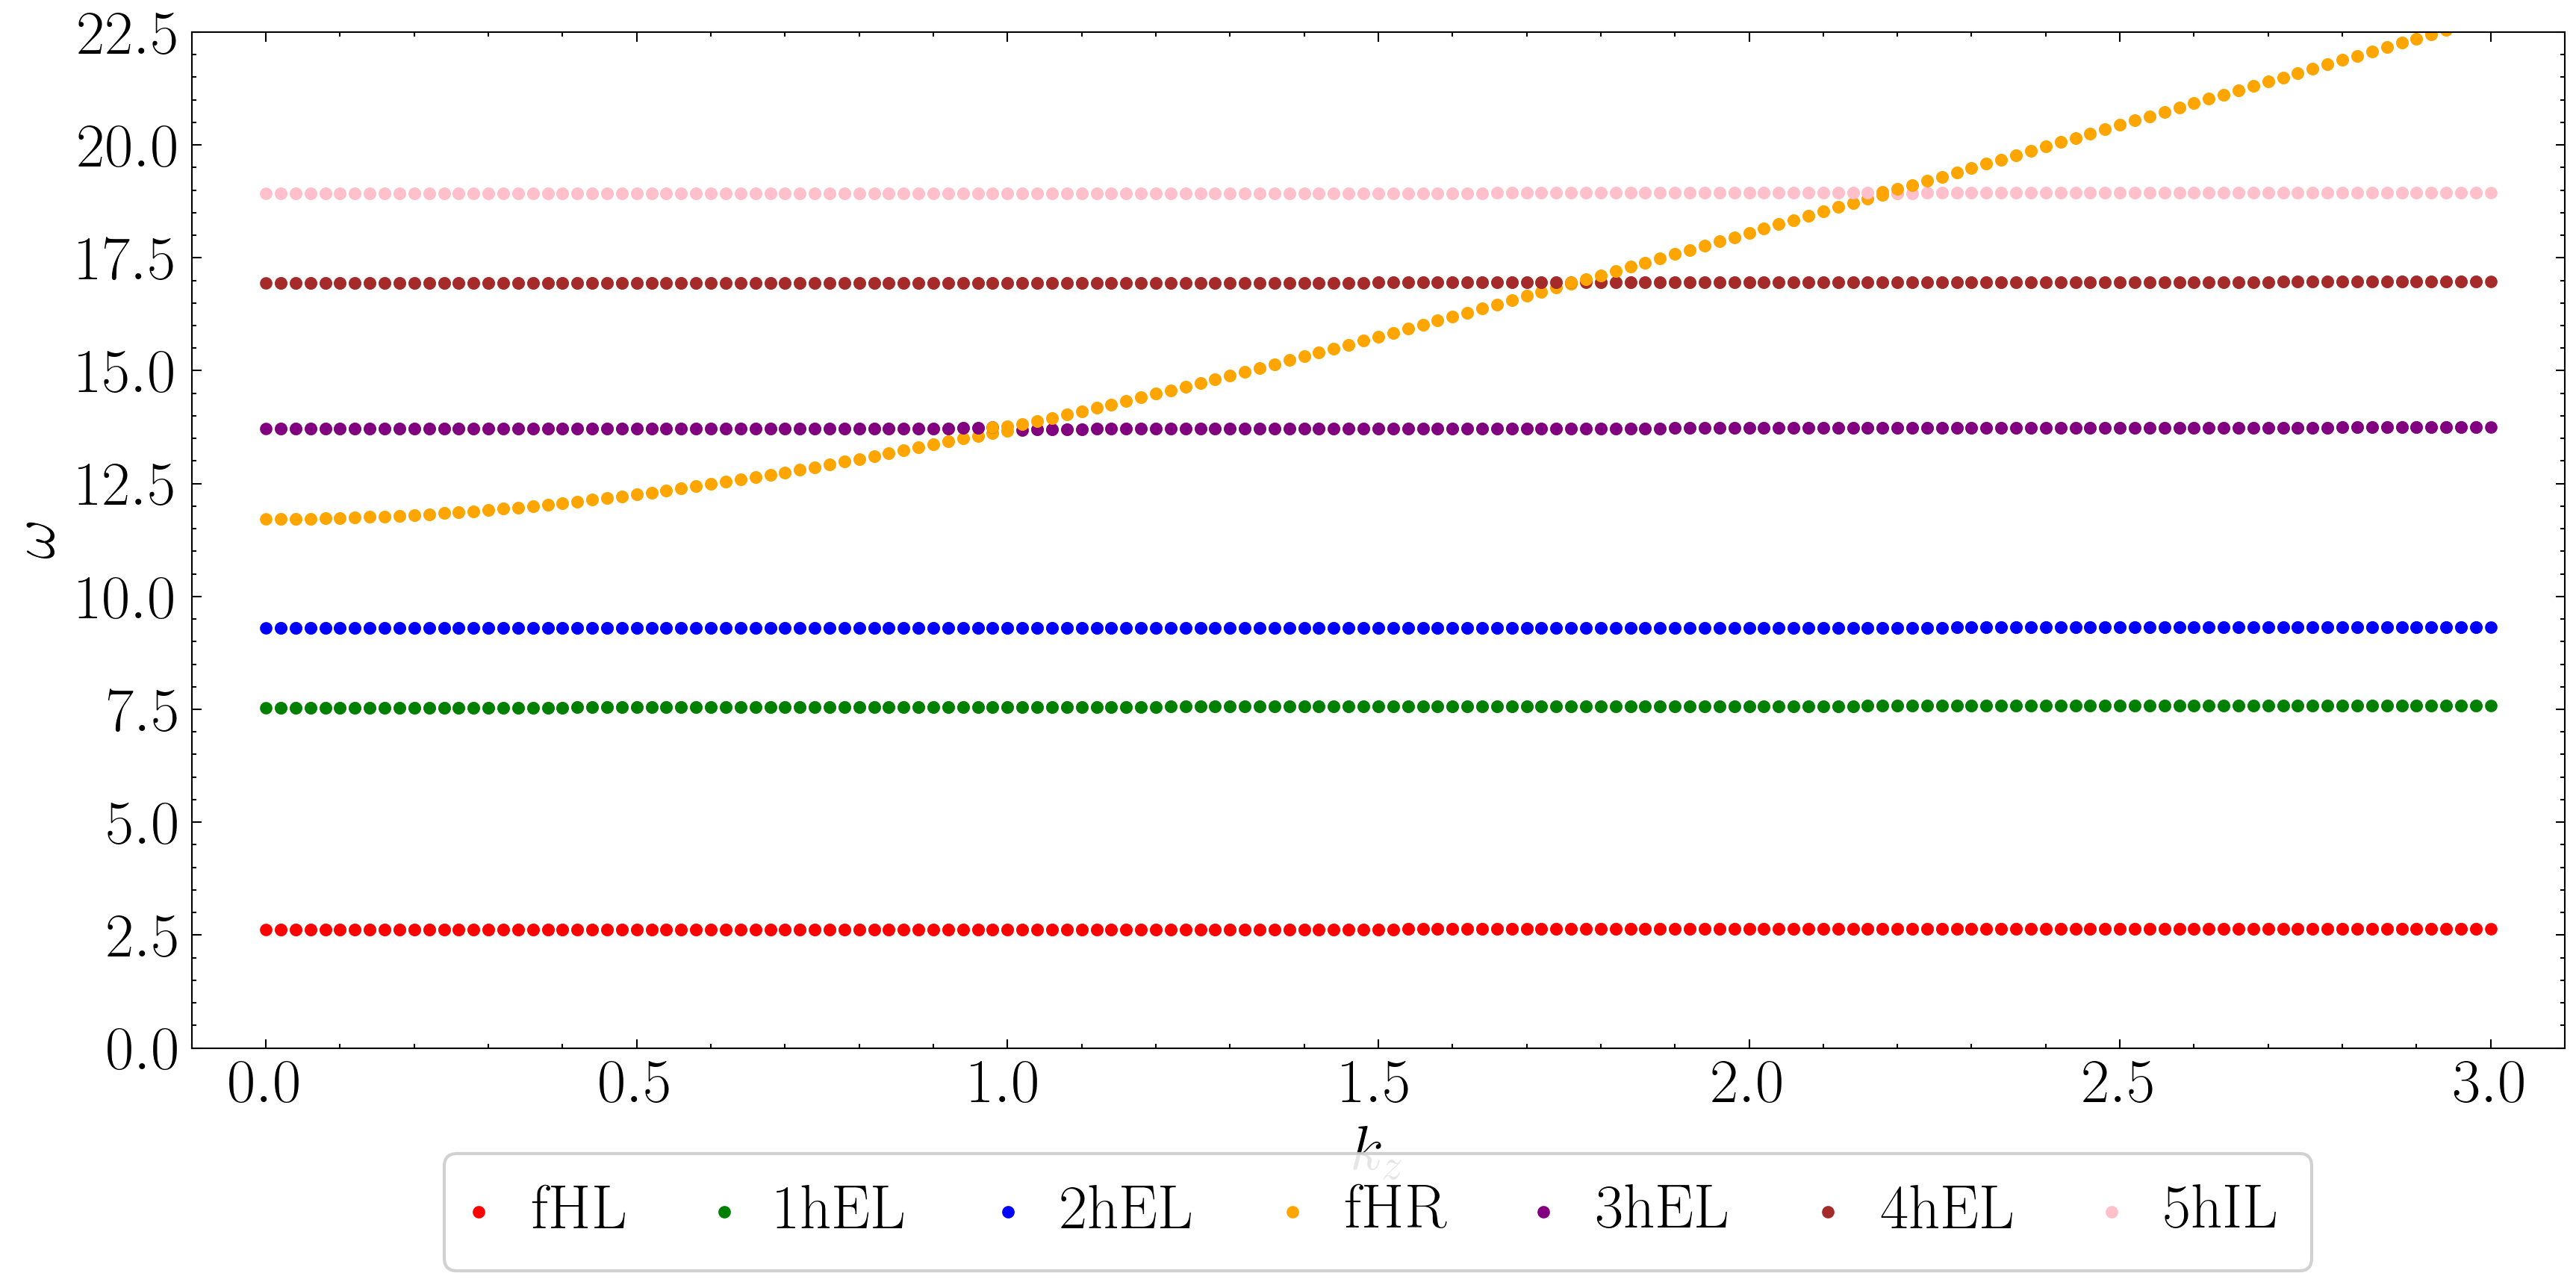

'\nplt.figure(figsize=(10, 6))\n\n# --- Plot only n=2 (index 1) with segmented colors ---\nidx = 1\nmode_label = f"Mode {idx+1}"\nassigned_colors = colors_per_mode.get(mode_label, ["blue"])\ncolor_idx = 0\nfirst_segment = True\n\nomega = np.sqrt(evals_k[:, idx].real)\nkz_values = kz_list\nd_omega_d_kz = np.diff(omega) / np.diff(kz_values)\nis_drastic = d_omega_d_kz > 0.75  # Use the same threshold as in your script\n\nfor j in range(len(d_omega_d_kz)):\n    if color_idx >= len(assigned_colors):\n        color = "blue"\n    else:\n        color = assigned_colors[color_idx]\n    # Plot segment for n=2\n    plt.plot(kz_values[j:j+2], omega[j:j+2], \'.\', color=color, linewidth=2)\n    if j < len(d_omega_d_kz) - 1:\n        if is_drastic[j] != is_drastic[j+1]:\n            color_idx += 1\n\nplt.xlabel(r"$k_z$")\nplt.ylabel(r"$\\omega = \\sqrt{s}$")\nplt.grid(False)\n#plt.savefig("dd_mode_2.png", dpi=300, bbox_inches=\'tight\')\nplt.tight_layout()\nplt.show()\n'

In [12]:
### Definim colors per a cada mode ###
colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'gray']

### Definim colors per a cada secció de cada mode ###
colors_per_mode = {
    "Mode 1": [colors[0]],
    "Mode 2": [colors[1]],
    "Mode 3": [colors[2]],
    "Mode 4": [colors[3], colors[3], colors[4]],
    "Mode 5": [colors[4], colors[3], colors[5]],
    "Mode 6": [colors[5], colors[3], colors[6]],
    "Mode 7": [colors[6], colors[3]],
}


plt.figure(figsize=(12, 7))
mode_handles = []  # Store one handle per mode for the legend

for i in range(7):
    omega = np.sqrt(evals_k[:, i].real)
    kz_values = kz_list
    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > 0.75

    mode_label = f"Mode {i+1}"
    assigned_colors = colors_per_mode.get(mode_label, ["blue"])
    color_idx = 0
    first_segment = True

    for j in range(len(d_omega_d_kz)):
        if color_idx >= len(assigned_colors):
            color = "blue"
        else:
            color = assigned_colors[color_idx]

        line, = plt.plot(kz_values[j:j+2], omega[j:j+2], '.', color=color, linewidth=2)
        if first_segment:
            mode_handles.append(line)
            first_segment = False

        if j < len(d_omega_d_kz) - 1:
            if is_drastic[j] != is_drastic[j+1]:
                color_idx += 1

plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega$")
plt.xlim(-0.1, 3.1)
plt.ylim(0, 22.5)
plt.grid(False)
yticks = np.arange(0, 25, 2.5)
plt.yticks(yticks)
plt.legend(handles=mode_handles, labels=mode_labels, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=len(mode_labels), columnspacing=1.5, frameon=True, fontsize=20, title_fontsize=20, handlelength=0.1, handleheight=0.1, borderpad=0.5, borderaxespad=0.5, framealpha=0.9)
#plt.savefig("dd_modes_normals.png", dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()



### Representació del mode normal n = 2 ###
"""
plt.figure(figsize=(10, 6))

# --- Plot only n=2 (index 1) with segmented colors ---
idx = 1
mode_label = f"Mode {idx+1}"
assigned_colors = colors_per_mode.get(mode_label, ["blue"])
color_idx = 0
first_segment = True

omega = np.sqrt(evals_k[:, idx].real)
kz_values = kz_list
d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
is_drastic = d_omega_d_kz > 0.75  # Use the same threshold as in your script

for j in range(len(d_omega_d_kz)):
    if color_idx >= len(assigned_colors):
        color = "blue"
    else:
        color = assigned_colors[color_idx]
    # Plot segment for n=2
    plt.plot(kz_values[j:j+2], omega[j:j+2], '.', color=color, linewidth=2)
    if j < len(d_omega_d_kz) - 1:
        if is_drastic[j] != is_drastic[j+1]:
            color_idx += 1

plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega = \sqrt{s}$")
plt.grid(False)
#plt.savefig("dd_mode_2.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
"""

# Velocitat de fase

In [ ]:
### Phase velocity ###
plt.figure(figsize=(12, 7))
phase_mode_handles = []
for i in range(7):

    omega = np.sqrt(evals_k[:, i].real)
    phase_velocities = omega / kz_list
    kz_values = kz_list
    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > 0.75

    mode_label = f"Mode {i+1}"
    assigned_colors = colors_per_mode.get(mode_label, ["blue"])
    color_idx = 0
    first_segment = True

    # For segmented coloring (like in the dispersion plot)
    for j in range(len(d_omega_d_kz)):
        if color_idx >= len(assigned_colors):
            color = "blue"
        else:
            color = assigned_colors[color_idx]

        # Plot phase velocity segment
        line, = plt.plot(kz_values[j:j+2], phase_velocities[j:j+2], '.', color=color, linewidth=2)
        if first_segment:
            phase_mode_handles.append(line)
            first_segment = False

        if j < len(d_omega_d_kz) - 1:
            if is_drastic[j] != is_drastic[j+1]:
                color_idx += 1

plt.xlabel(r"$k_z$")
plt.ylabel(r"$v = \omega / k_z$")
plt.xlim(-0.1, 3.1)
plt.ylim(0, 100)
plt.grid(False)
plt.legend(handles=phase_mode_handles, labels=mode_labels, loc='lower center', bbox_to_anchor=(0.5, -0.33), ncol=len(mode_labels), columnspacing=1.5, frameon=True, fontsize=20, title_fontsize=20, handlelength=0.1, handleheight=0.1, borderpad=0.5, borderaxespad=0.5, framealpha=0.9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
#plt.savefig("phase_velocity_modes.png", dpi=300, bbox_inches='tight')
plt.savefig("phase_velocity_modes_apendix.png", dpi=300, bbox_inches='tight')
plt.show()


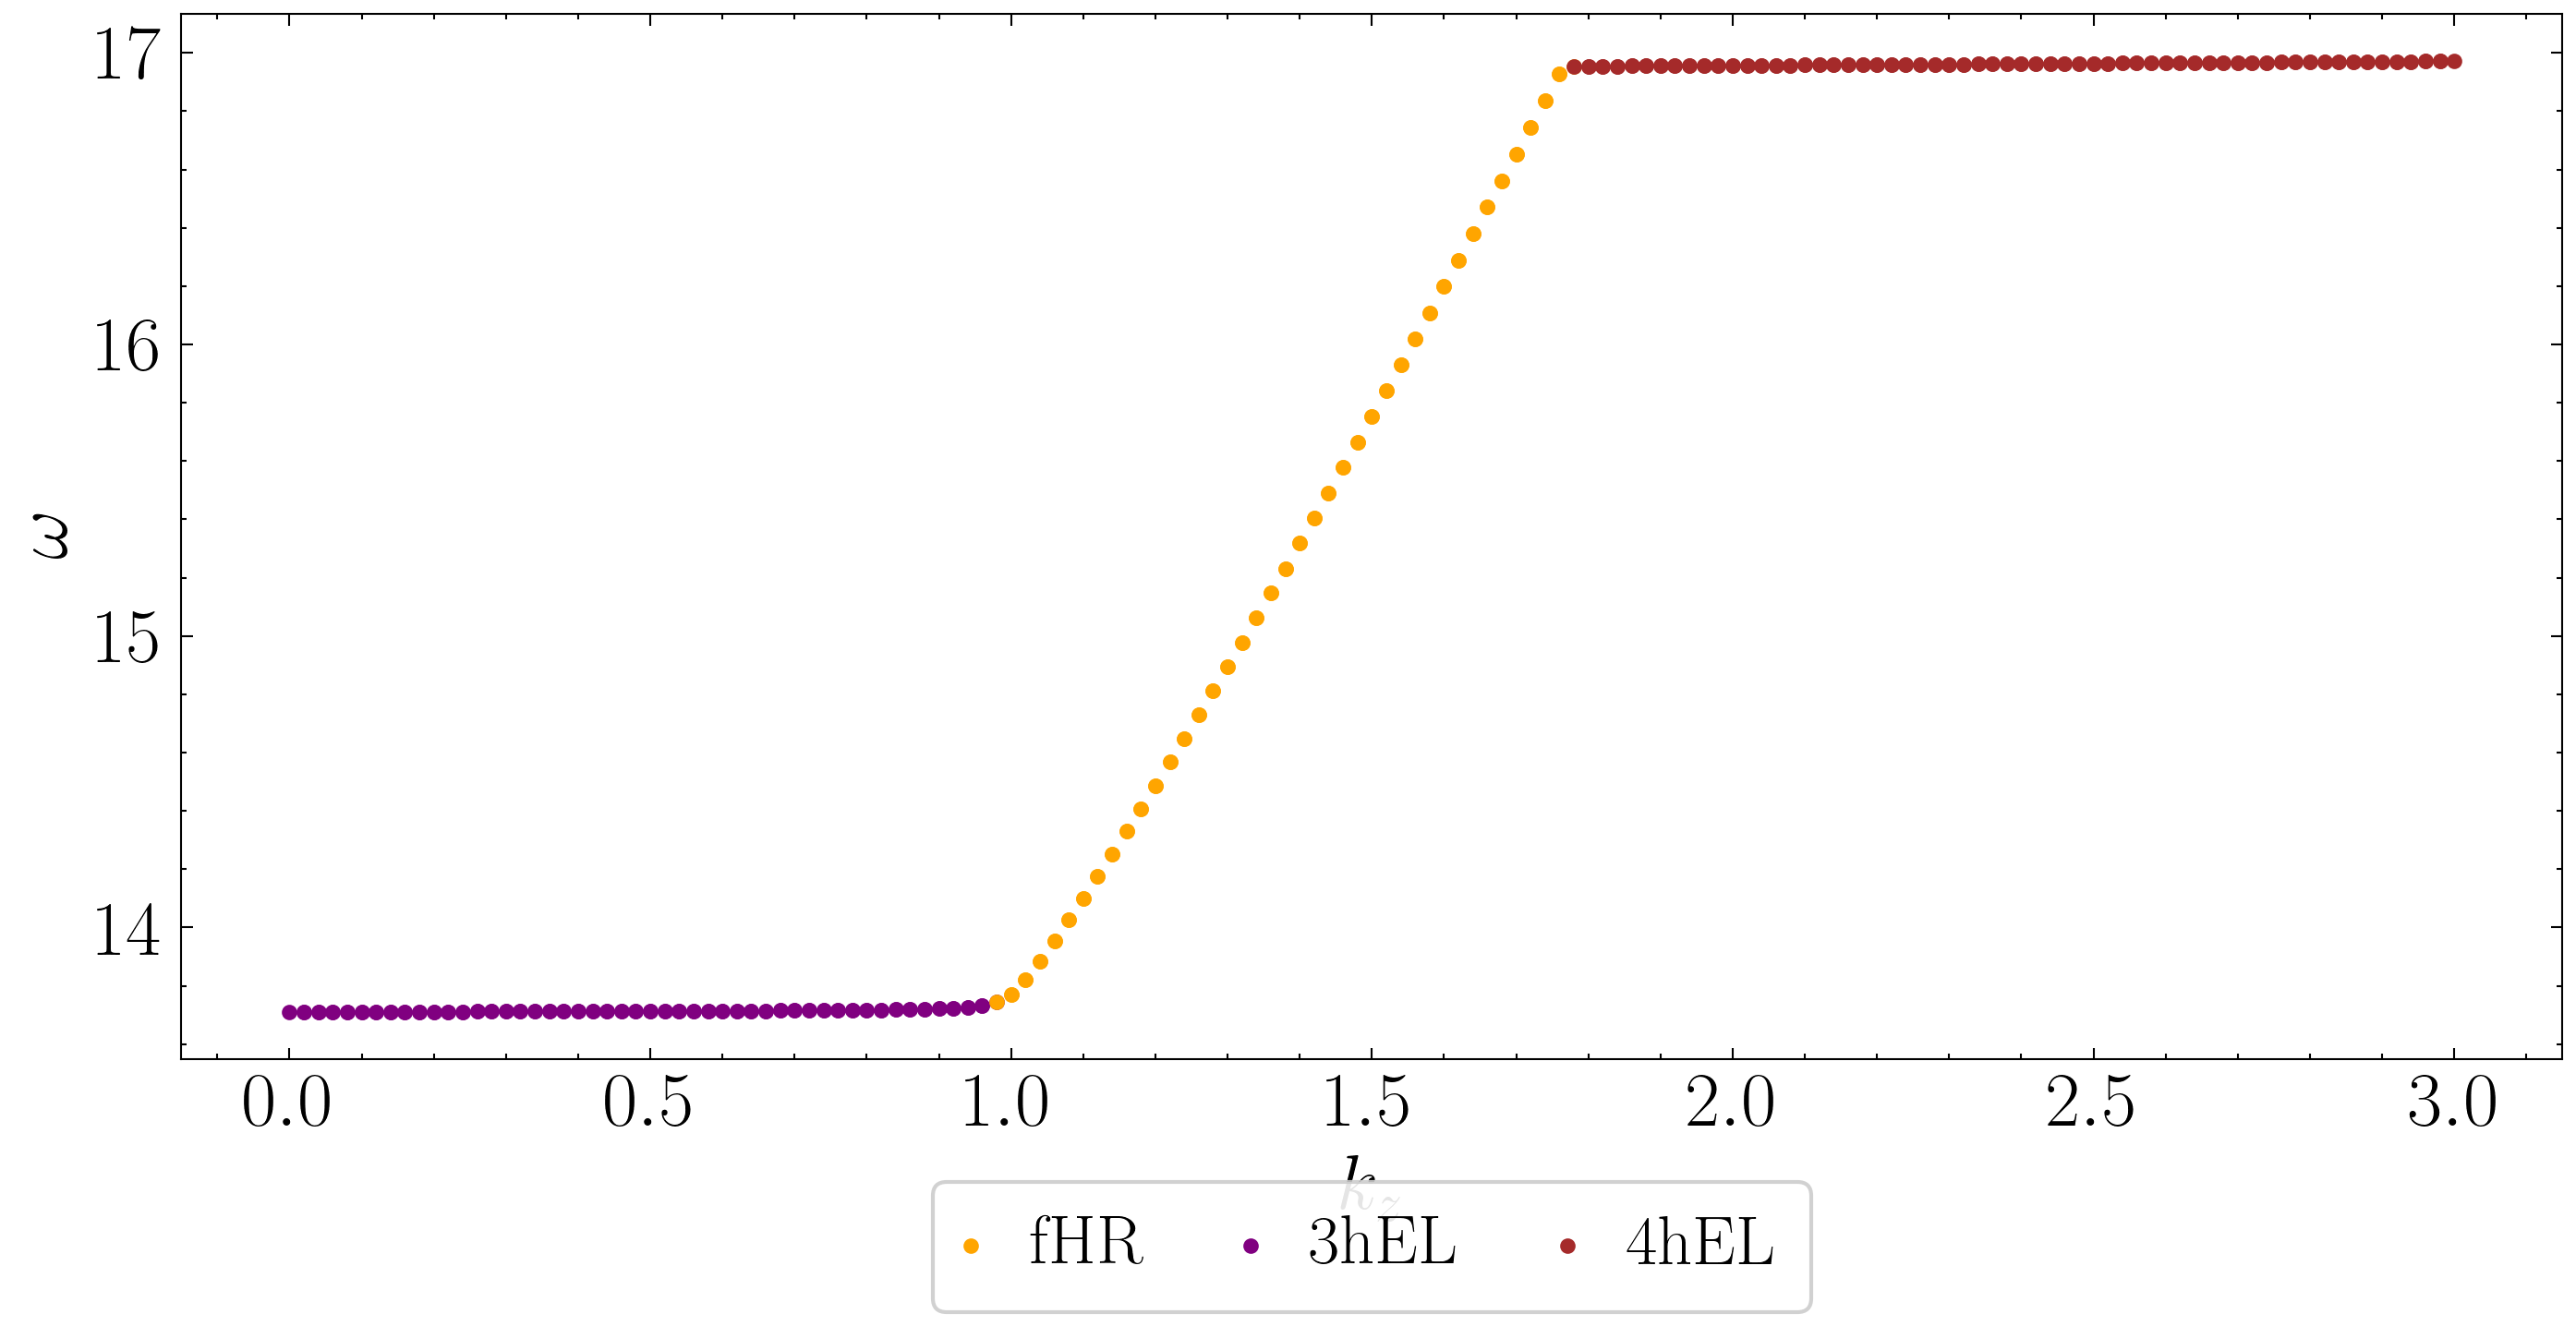

In [ ]:
### Representació del mode normal n = 5 ###

### Índexs pel canvi de comportament ###
legend_modes = [3, 4, 5]

plt.figure(figsize=(10, 6))

# --- Plot only n=5 (index 4) with segmented colors ---
idx = 4
mode_label = f"Mode {idx+1}"
assigned_colors = colors_per_mode.get(mode_label, ["blue"])
color_idx = 0
first_segment = True

omega = np.sqrt(evals_k[:, idx].real)
kz_values = kz_list
d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
is_drastic = d_omega_d_kz > 0.75  # Use the same threshold as in your script

segment_handles = [None, None, None]  # For n=4, n=5, n=6
segment_labels = [mode_labels[3], mode_labels[4], mode_labels[5]]

for j in range(len(d_omega_d_kz)):
    if color_idx >= len(assigned_colors):
        color = "blue"
    else:
        color = assigned_colors[color_idx]
    # Plot segment for n=5
    line, = plt.plot(kz_values[j:j+2], omega[j:j+2], '.', color=color, linewidth=2)
    # Store handle for n=5 in the right position for the legend
    if first_segment:
        segment_handles[1] = line  # n=5 is the middle entry
        first_segment = False
    if j < len(d_omega_d_kz) - 1:
        if is_drastic[j] != is_drastic[j+1]:
            color_idx += 1

# --- Add invisible lines for n=4 and n=6 for the legend ---
for i, idx_legend in enumerate(legend_modes):
    if i == 1:
        continue  # n=5 already plotted
    color = colors_per_mode.get(f"Mode {idx_legend+1}", [colors[idx_legend % len(colors)]])[0]
    # Add an invisible line for legend only
    segment_handles[i], = plt.plot([], [], '.', color=color, linewidth=2)

plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega$")
plt.grid(False)
plt.legend(handles=segment_handles, labels=segment_labels, loc='lower center', bbox_to_anchor=(0.5, -0.275), ncol=len(legend_modes), columnspacing=1.5, frameon=True, fontsize=18, title_fontsize=18, handlelength=0.1, handleheight=0.1, borderpad=0.5, borderaxespad=0.5, framealpha=0.9)
#plt.savefig("dd_mode_5.png", dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

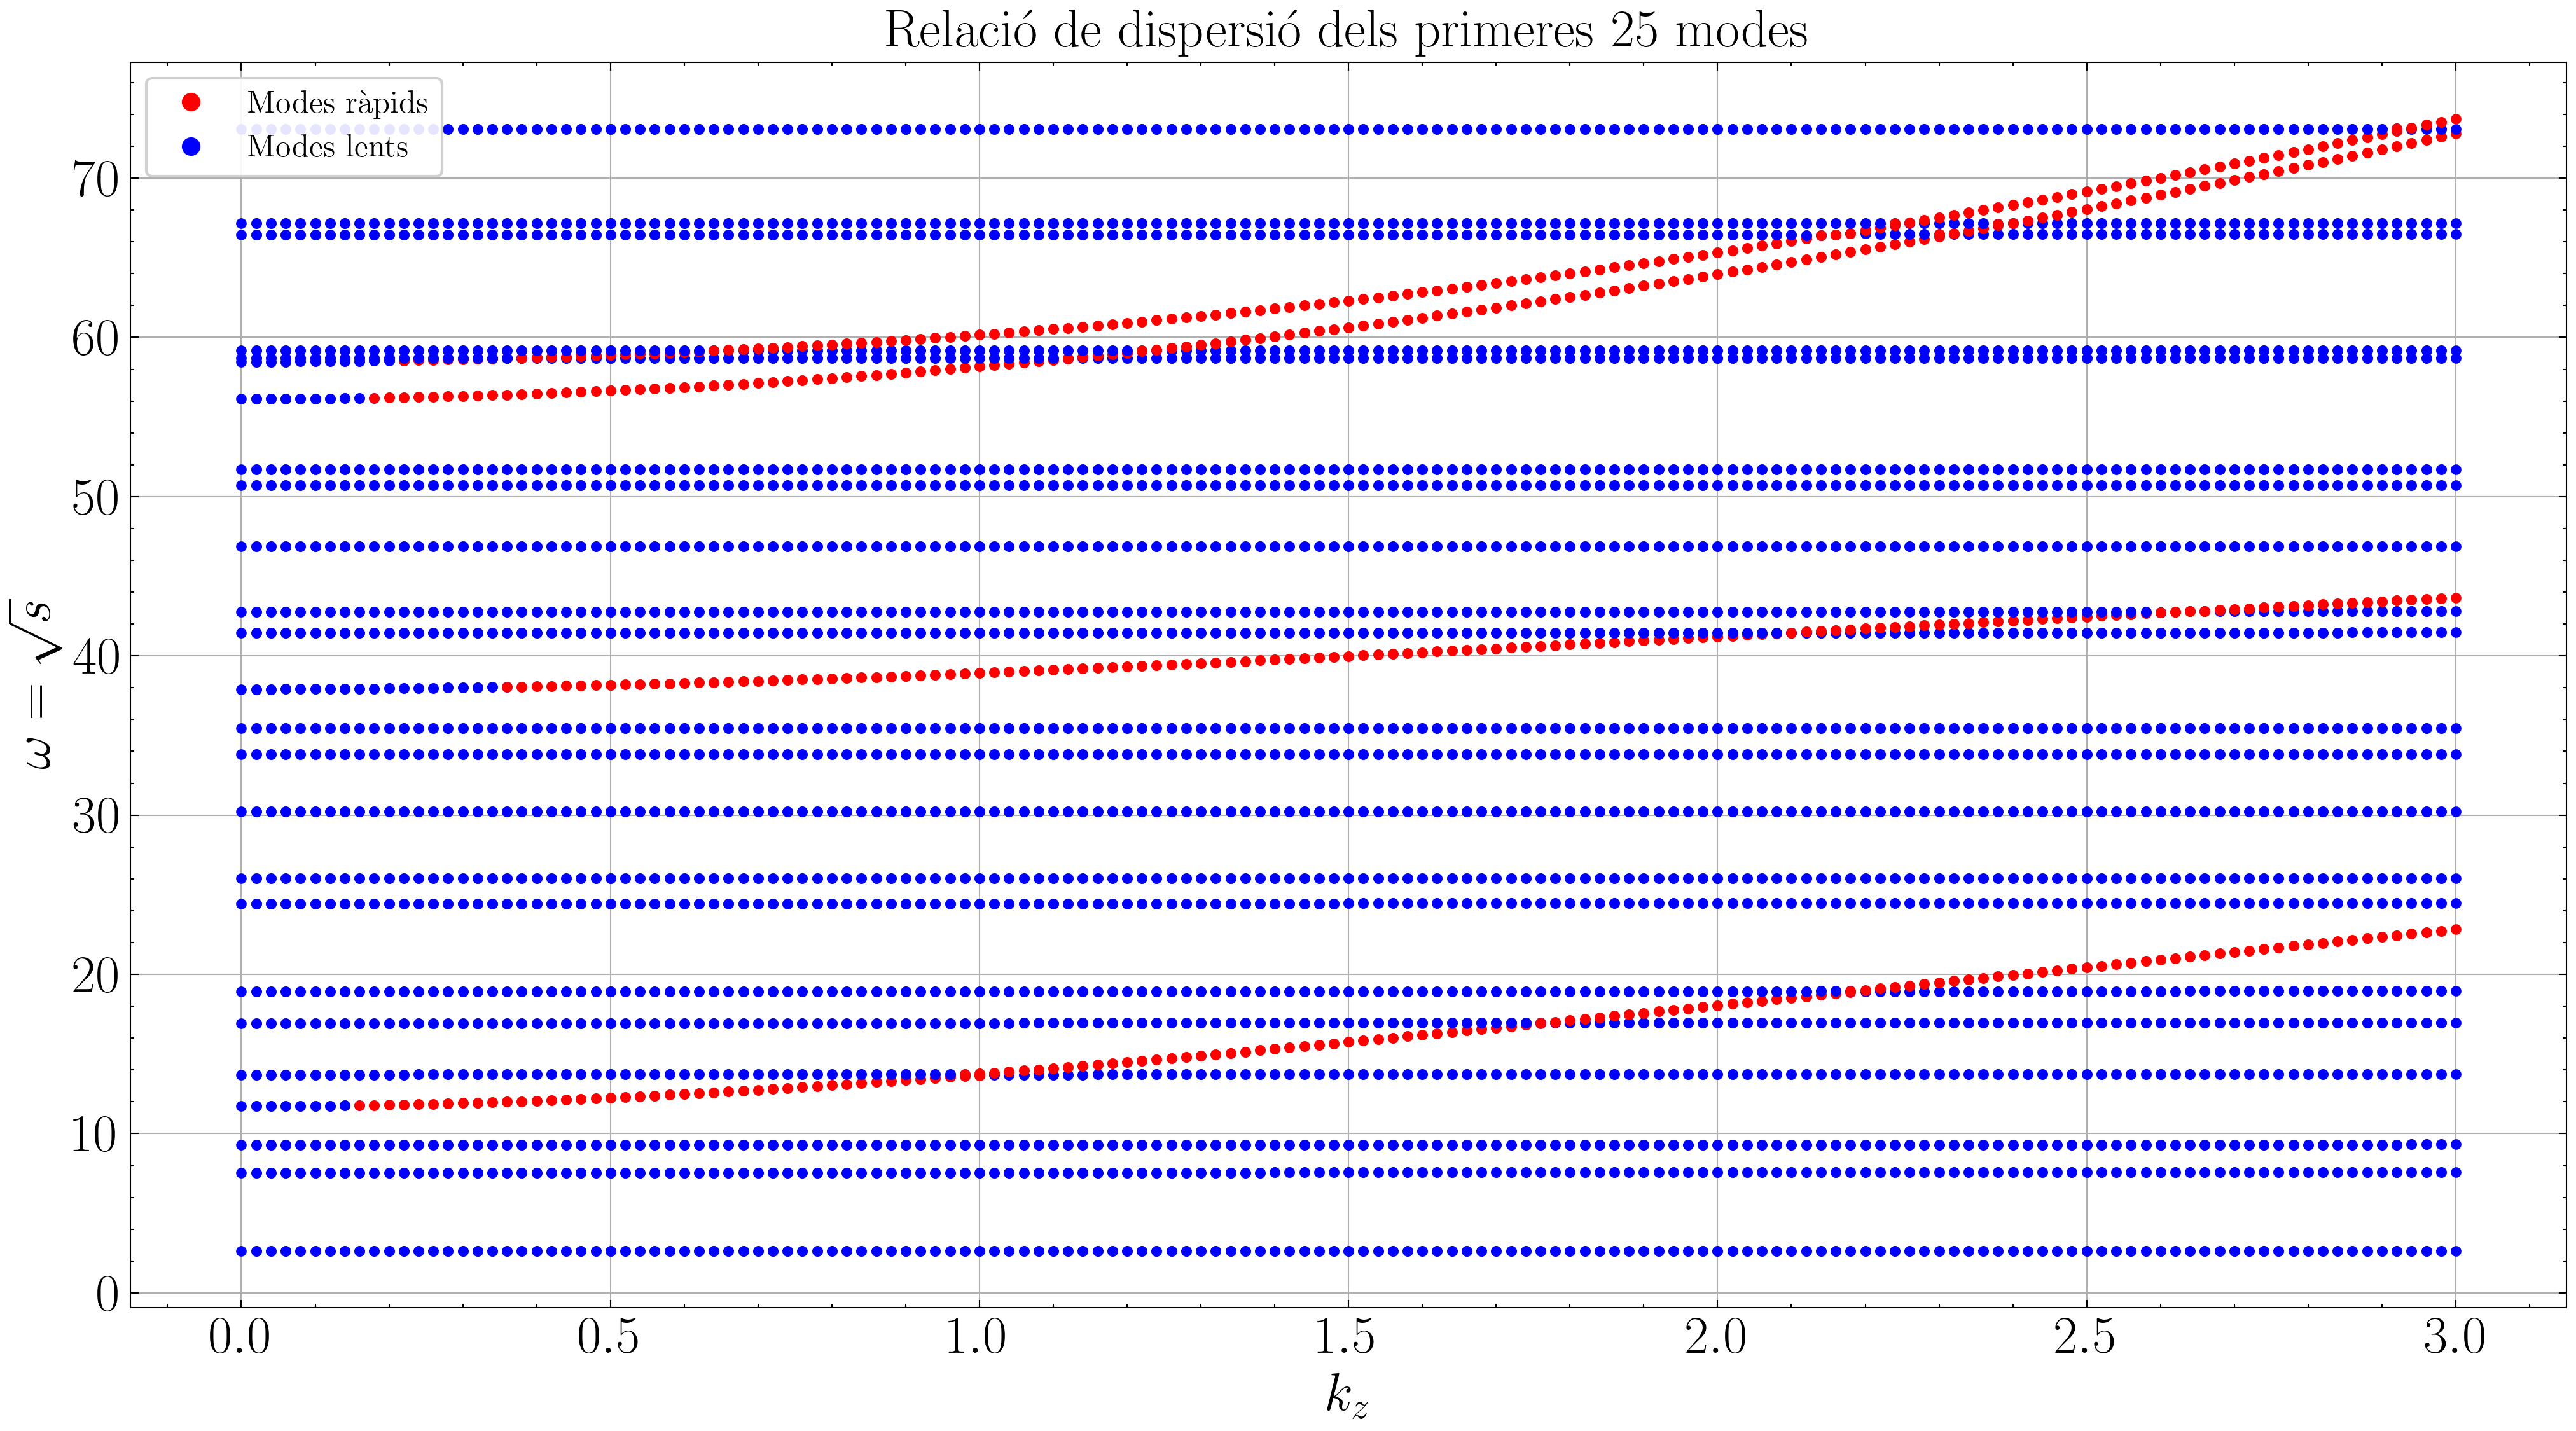

In [ ]:
### DD amb 25 modes ###

### Parameters ###
num_modes = 25  # Number of modes to plot
threshold = 0.75

drastic_increase_points = {}

plt.figure(figsize=(14, 8))

for i in range(num_modes):
    omega = np.sqrt(evals_k[:, i].real)
    kz_values = kz_list

    # Compute discrete derivative
    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > threshold

    # Store kz values where drastic increase occurs
    indices = np.where(is_drastic)[0]
    drastic_increase_points[f"Mode {i+1}"] = kz_values[indices + 1]

    # Plot each segment in blue (slow) or red (fast)
    color_idx = 0
    for j in range(len(d_omega_d_kz)):
        color = 'red' if is_drastic[j] else 'blue'
        plt.plot(kz_values[j:j+2], omega[j:j+2], '.', color=color, linewidth=2)
        # No need to increment color_idx, as color is determined by is_drastic

plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega = \sqrt{s}$")
plt.title(f"Relació de dispersió dels primeres {num_modes} modes")
plt.grid(True)

custom_legend = [
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=6, label='Modes ràpids'),
    mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=6, label='Modes lents')
]
plt.legend(handles=custom_legend, loc="upper left", frameon=True, fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

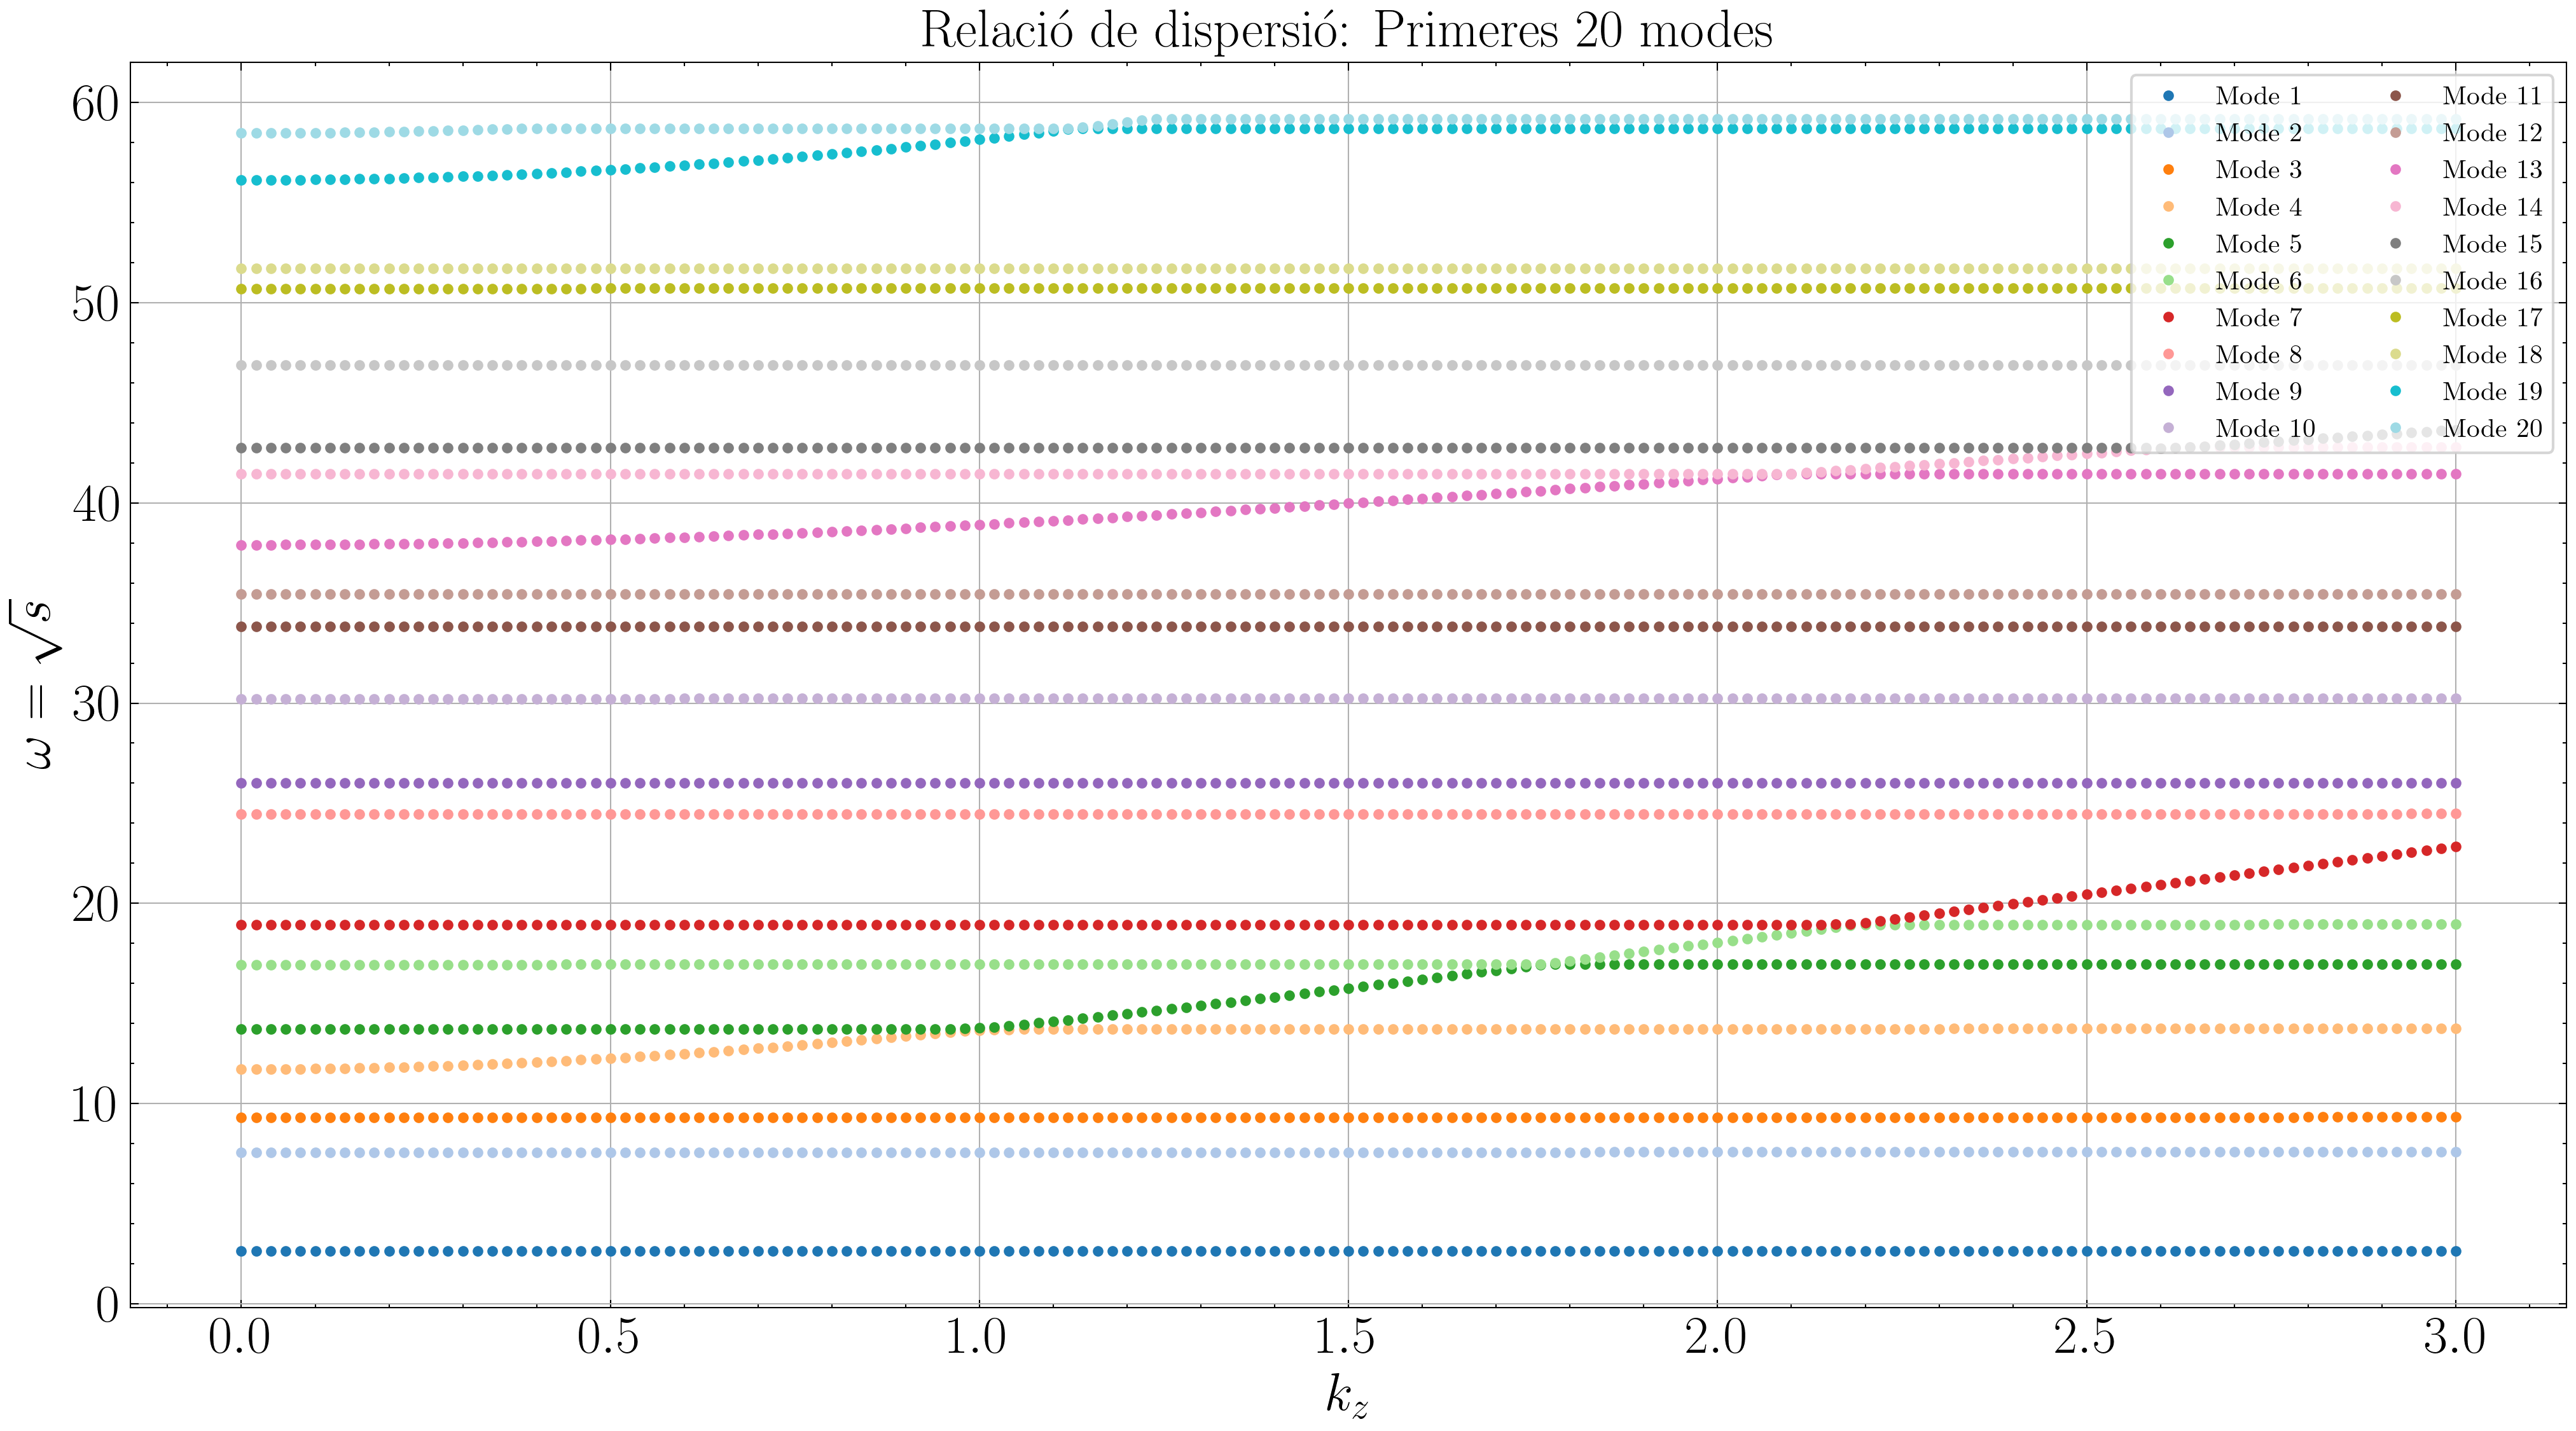

In [ ]:
### DD amb 25 modes ###

### Parameters ###
num_modes = 20  # Change this to plot more (or fewer) modes
threshold = 0.75

# Use a colormap for many modes
cmap = plt.get_cmap('tab20', num_modes)
plt.figure(figsize=(14, 8))

for i in range(num_modes):
    omega = np.sqrt(evals_k[:, i].real)
    kz_values = kz_list

    # Derivada discreta
    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > threshold

    color = cmap(i)  # Get a unique color for each mode

    # Plot the mode, segment by segment if you want to keep the "drastic" coloring
    # Otherwise, just plot the whole mode in one color:
    plt.plot(kz_values, omega, '.', color=color, linewidth=2, label=f"Mode {i+1}")

plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega = \sqrt{s}$")
plt.title(f"Relació de dispersió: Primeres {num_modes} modes")
plt.grid(True)

# Custom legend for "fast" and "slow" (optional, or you can use a mode legend)
custom_legend = [
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=4, label='Mode ràpid'),
    mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=4, label='Modes lents')
]
# If you want a legend for all modes, use:
plt.legend(loc="upper right", fontsize=10, ncol=2, frameon=True)
# Or, for just the custom legend:
# plt.legend(handles=custom_legend, loc="upper left", frameon=True, fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.show()

# Ampliació a un canvi de comportament en la relació de dispersió

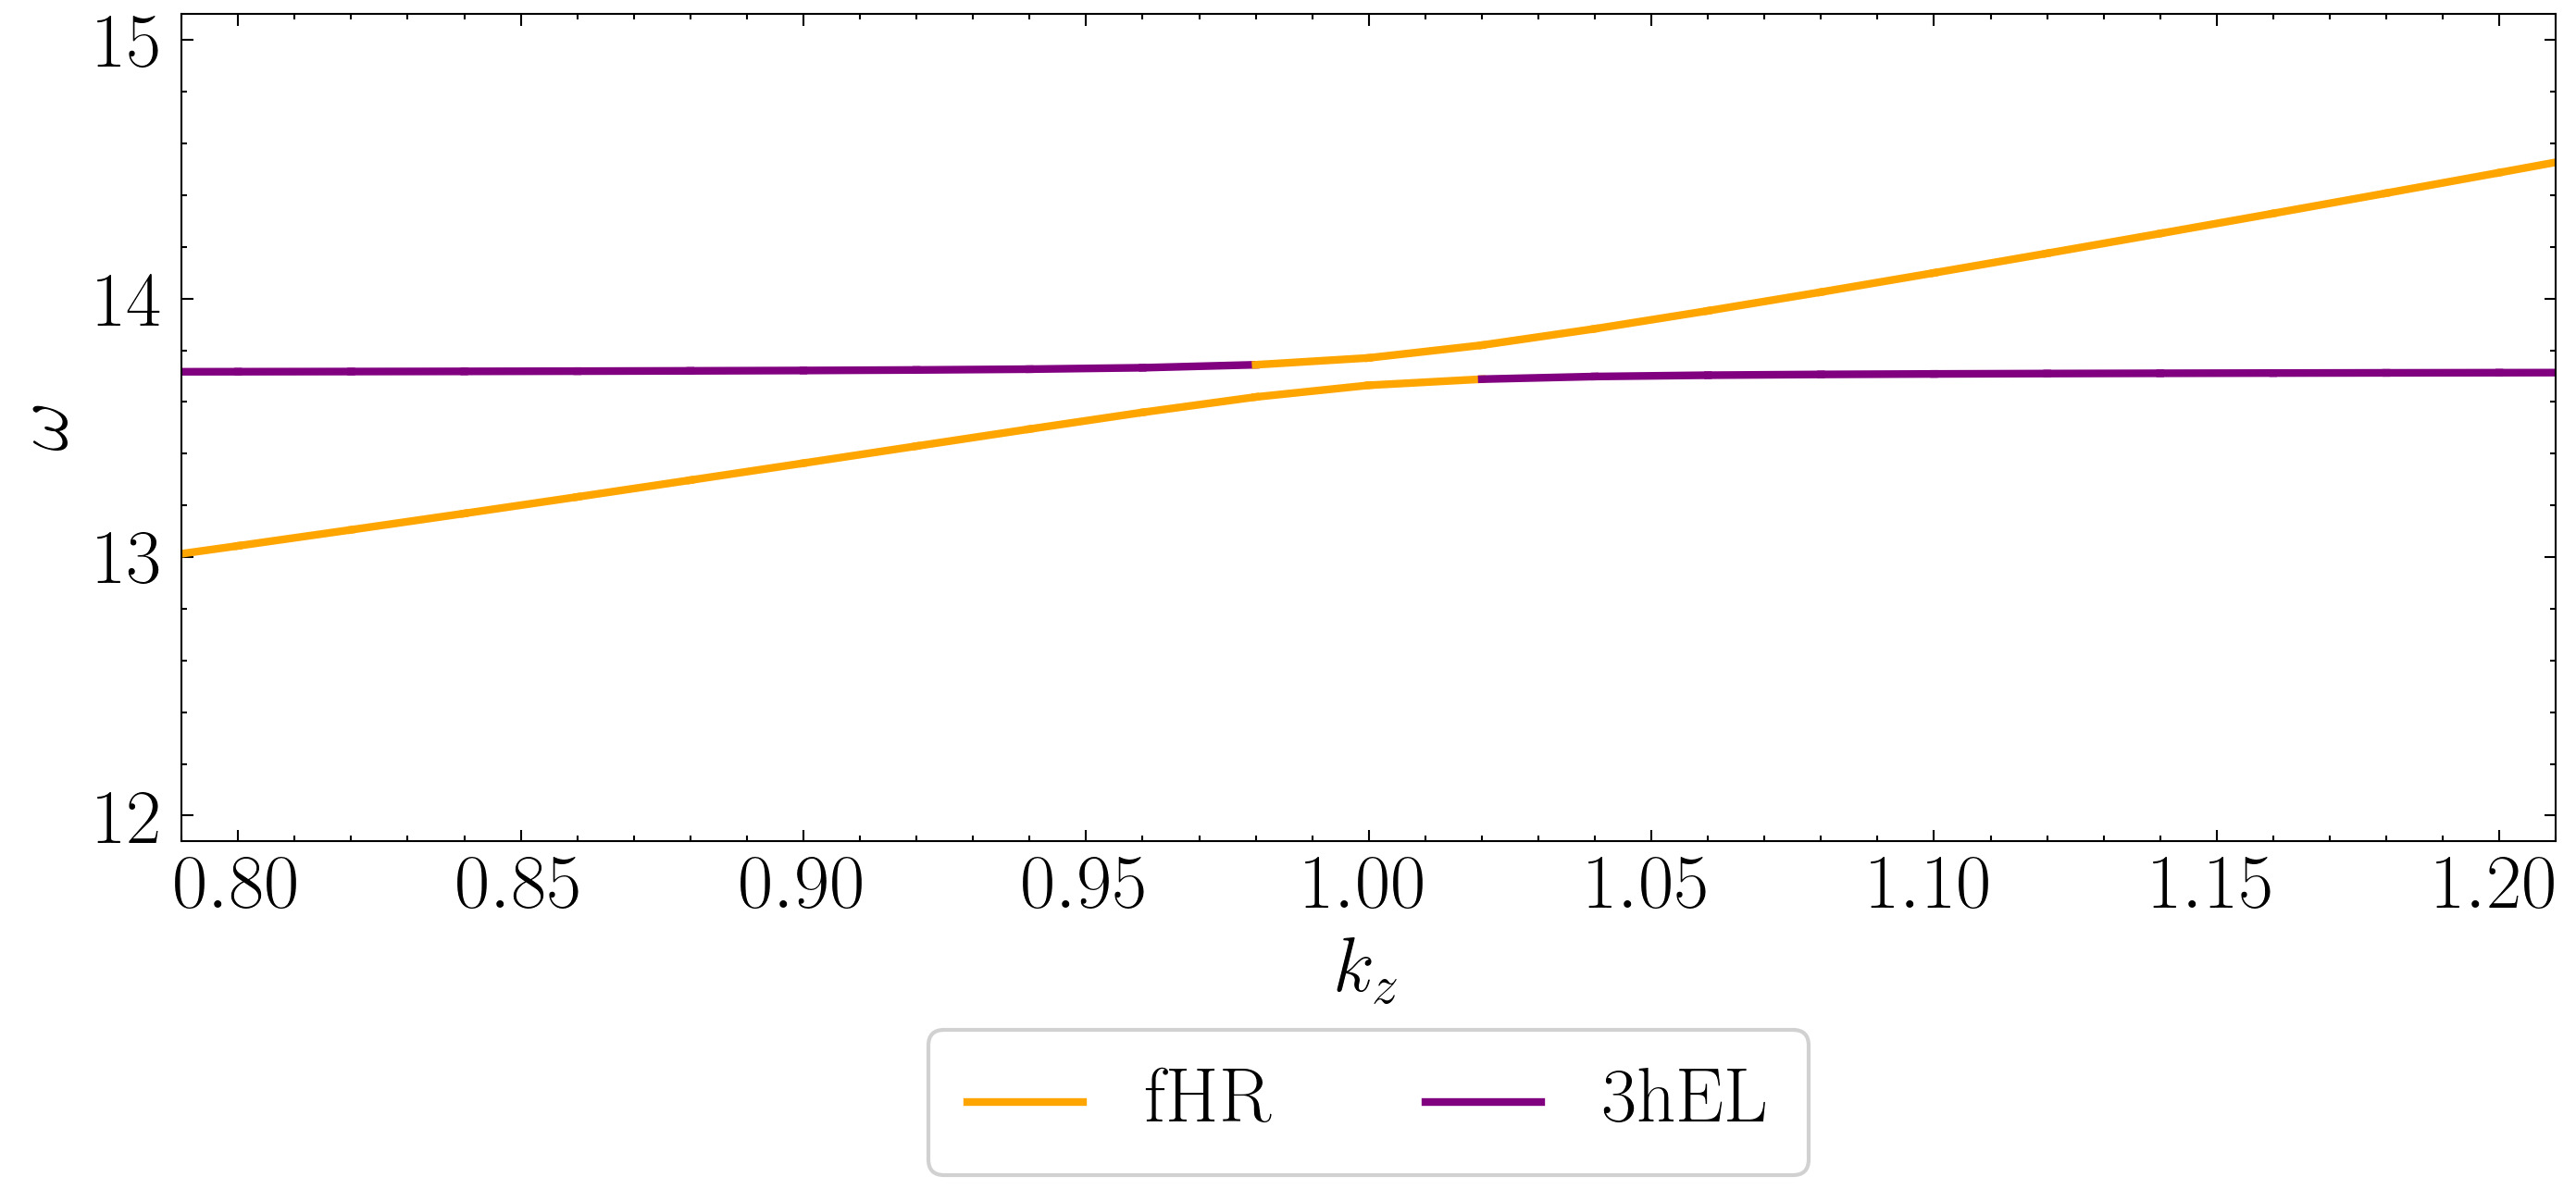

In [14]:
### Primer anticreuament evitat ###
# First anticrossing with correct segmented colors for each mode
# and a legend centered below the x axis, as in the main diagram

plt.figure(figsize=(10, 6))
xlim1 = (0.79, 1.21)  # Set x-axis limits for the first subplot
ylim1 = (11.9, 15.1)  # Set y-axis limits for the first subplot
handles1 = []
labels1 = []

for i in range(8):  # Adjust the range as needed
    omega = np.sqrt(evals_k[:, i].real)
    kz_values = kz_list

    # Use segmented color logic for each mode
    mode_label = f"Mode {i+1}"
    assigned_colors = colors_per_mode.get(mode_label, ["blue"])
    color_idx = 0
    first_segment = True

    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > 0.75

    for j in range(len(d_omega_d_kz)):
        if color_idx >= len(assigned_colors):
            color = "blue"
        else:
            color = assigned_colors[color_idx]
        line, = plt.plot(kz_values[j:j+2], omega[j:j+2], '-', color=color, linewidth=2)
        # Add to legend only for the first segment of each mode
        if first_segment and np.any((kz_values[j:j+2] >= xlim1[0]) & (kz_values[j:j+2] <= xlim1[1]) & (omega[j:j+2] >= ylim1[0]) & (omega[j:j+2] <= ylim1[1])):
            handles1.append(line)
            labels1.append(mode_labels[i])
            first_segment = False
        if j < len(d_omega_d_kz) - 1:
            if is_drastic[j] != is_drastic[j+1]:
                color_idx += 1

plt.xlim(xlim1)
plt.ylim(ylim1)
plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega$")
plt.legend(
    handles=handles1,
    labels=labels1,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.45),
    ncol=4,
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1.5,
    handleheight=0.1,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.grid(False)
#plt.savefig('first_anticrossing.png', dpi=300, bbox_inches='tight')
plt.show()

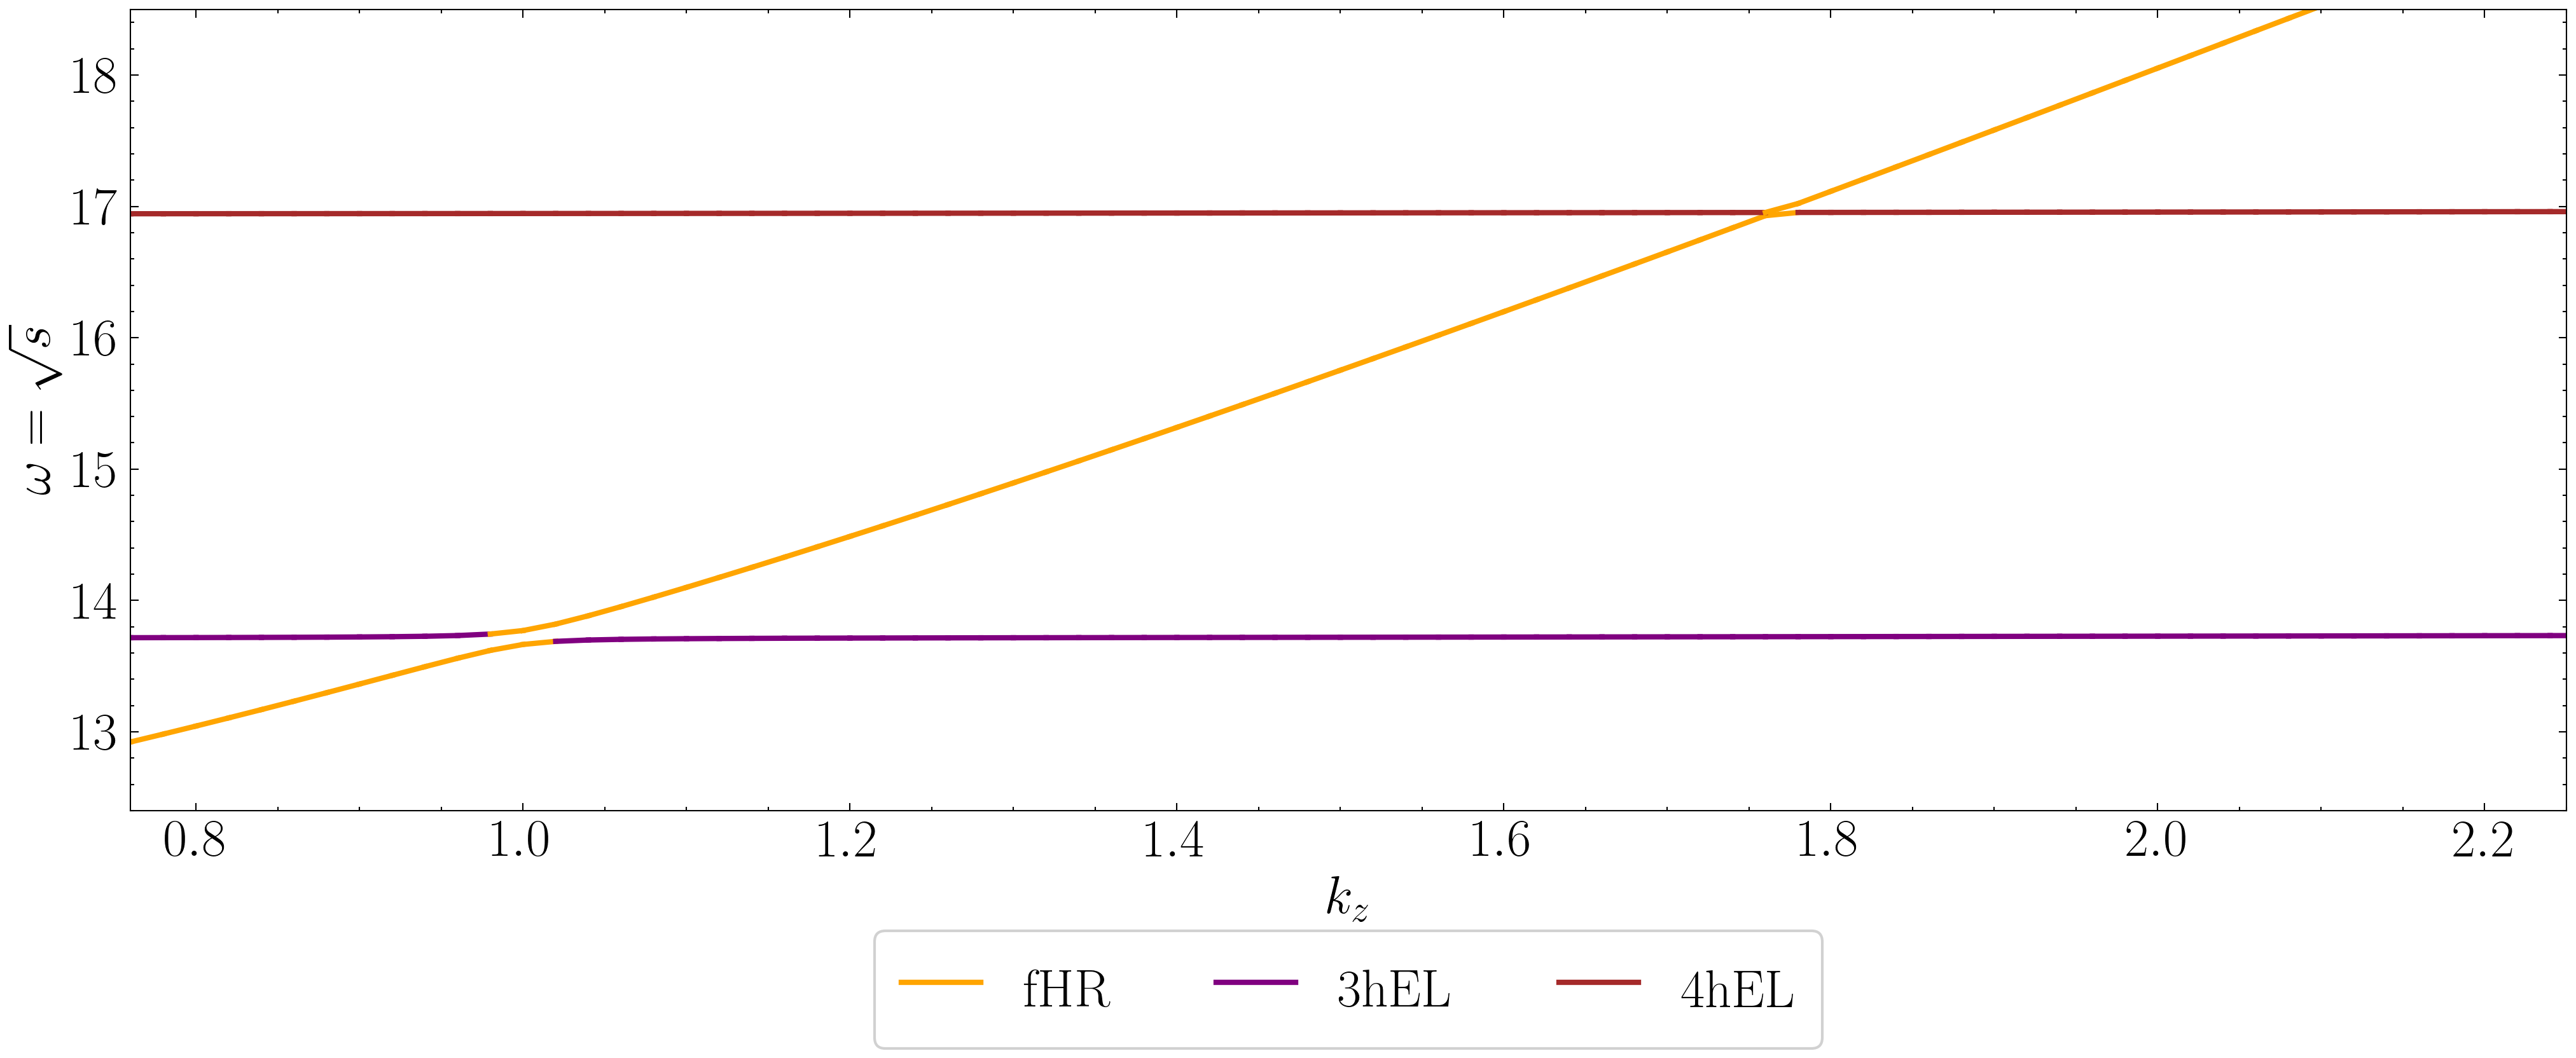

In [13]:
# Plot the first two avoided crossings in detail, with correct segmented colors for each mode
# and a legend centered below the x axis, as in the previous plots

plt.figure(figsize=(14, 7))
xlim_zoom = (0.76, 2.25)  # Adjust as needed to show both crossings
ylim_zoom = (12.4, 18.5)  # Adjust as needed to show both crossings

handles_zoom = []
labels_zoom = []

for i in range(8):  # Plot the first 8 modes
    omega = np.sqrt(evals_k[:, i].real)
    kz_values = kz_list

    # Use segmented color logic for each mode
    mode_label = f"Mode {i+1}"
    assigned_colors = colors_per_mode.get(mode_label, ["blue"])
    color_idx = 0
    first_segment = True

    d_omega_d_kz = np.diff(omega) / np.diff(kz_values)
    is_drastic = d_omega_d_kz > 0.75

    for j in range(len(d_omega_d_kz)):
        if color_idx >= len(assigned_colors):
            color = "blue"
        else:
            color = assigned_colors[color_idx]
        line, = plt.plot(kz_values[j:j+2], omega[j:j+2], '-', color=color, linewidth=2)
        # Add to legend only for the first segment of each mode
        if first_segment and np.any((kz_values[j:j+2] >= xlim_zoom[0]) & (kz_values[j:j+2] <= xlim_zoom[1]) & (omega[j:j+2] >= ylim_zoom[0]) & (omega[j:j+2] <= ylim_zoom[1])):
            handles_zoom.append(line)
            labels_zoom.append(mode_labels[i])
            first_segment = False
        if j < len(d_omega_d_kz) - 1:
            if is_drastic[j] != is_drastic[j+1]:
                color_idx += 1

plt.xlim(xlim_zoom)
plt.ylim(ylim_zoom)
plt.xlabel(r"$k_z$")
plt.ylabel(r"$\omega = \sqrt{s}$")
plt.legend(
    handles=handles_zoom,
    labels=labels_zoom,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.33),
    ncol=4,
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1.5,
    handleheight=1.5,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
#plt.savefig('2_avoided_crossings.png', dpi=300, bbox_inches='tight')
plt.grid(False)
plt.show()


# Evolució autofuncions fHL

Maximum value is ug = 0.5052861292696615
Maximum value is ug = -1.0955349173665372
Maximum value is ug = -1.0954481582820705
Maximum value is ug = 1.0952398271693462
Maximum value is ug = -1.0950807265001758


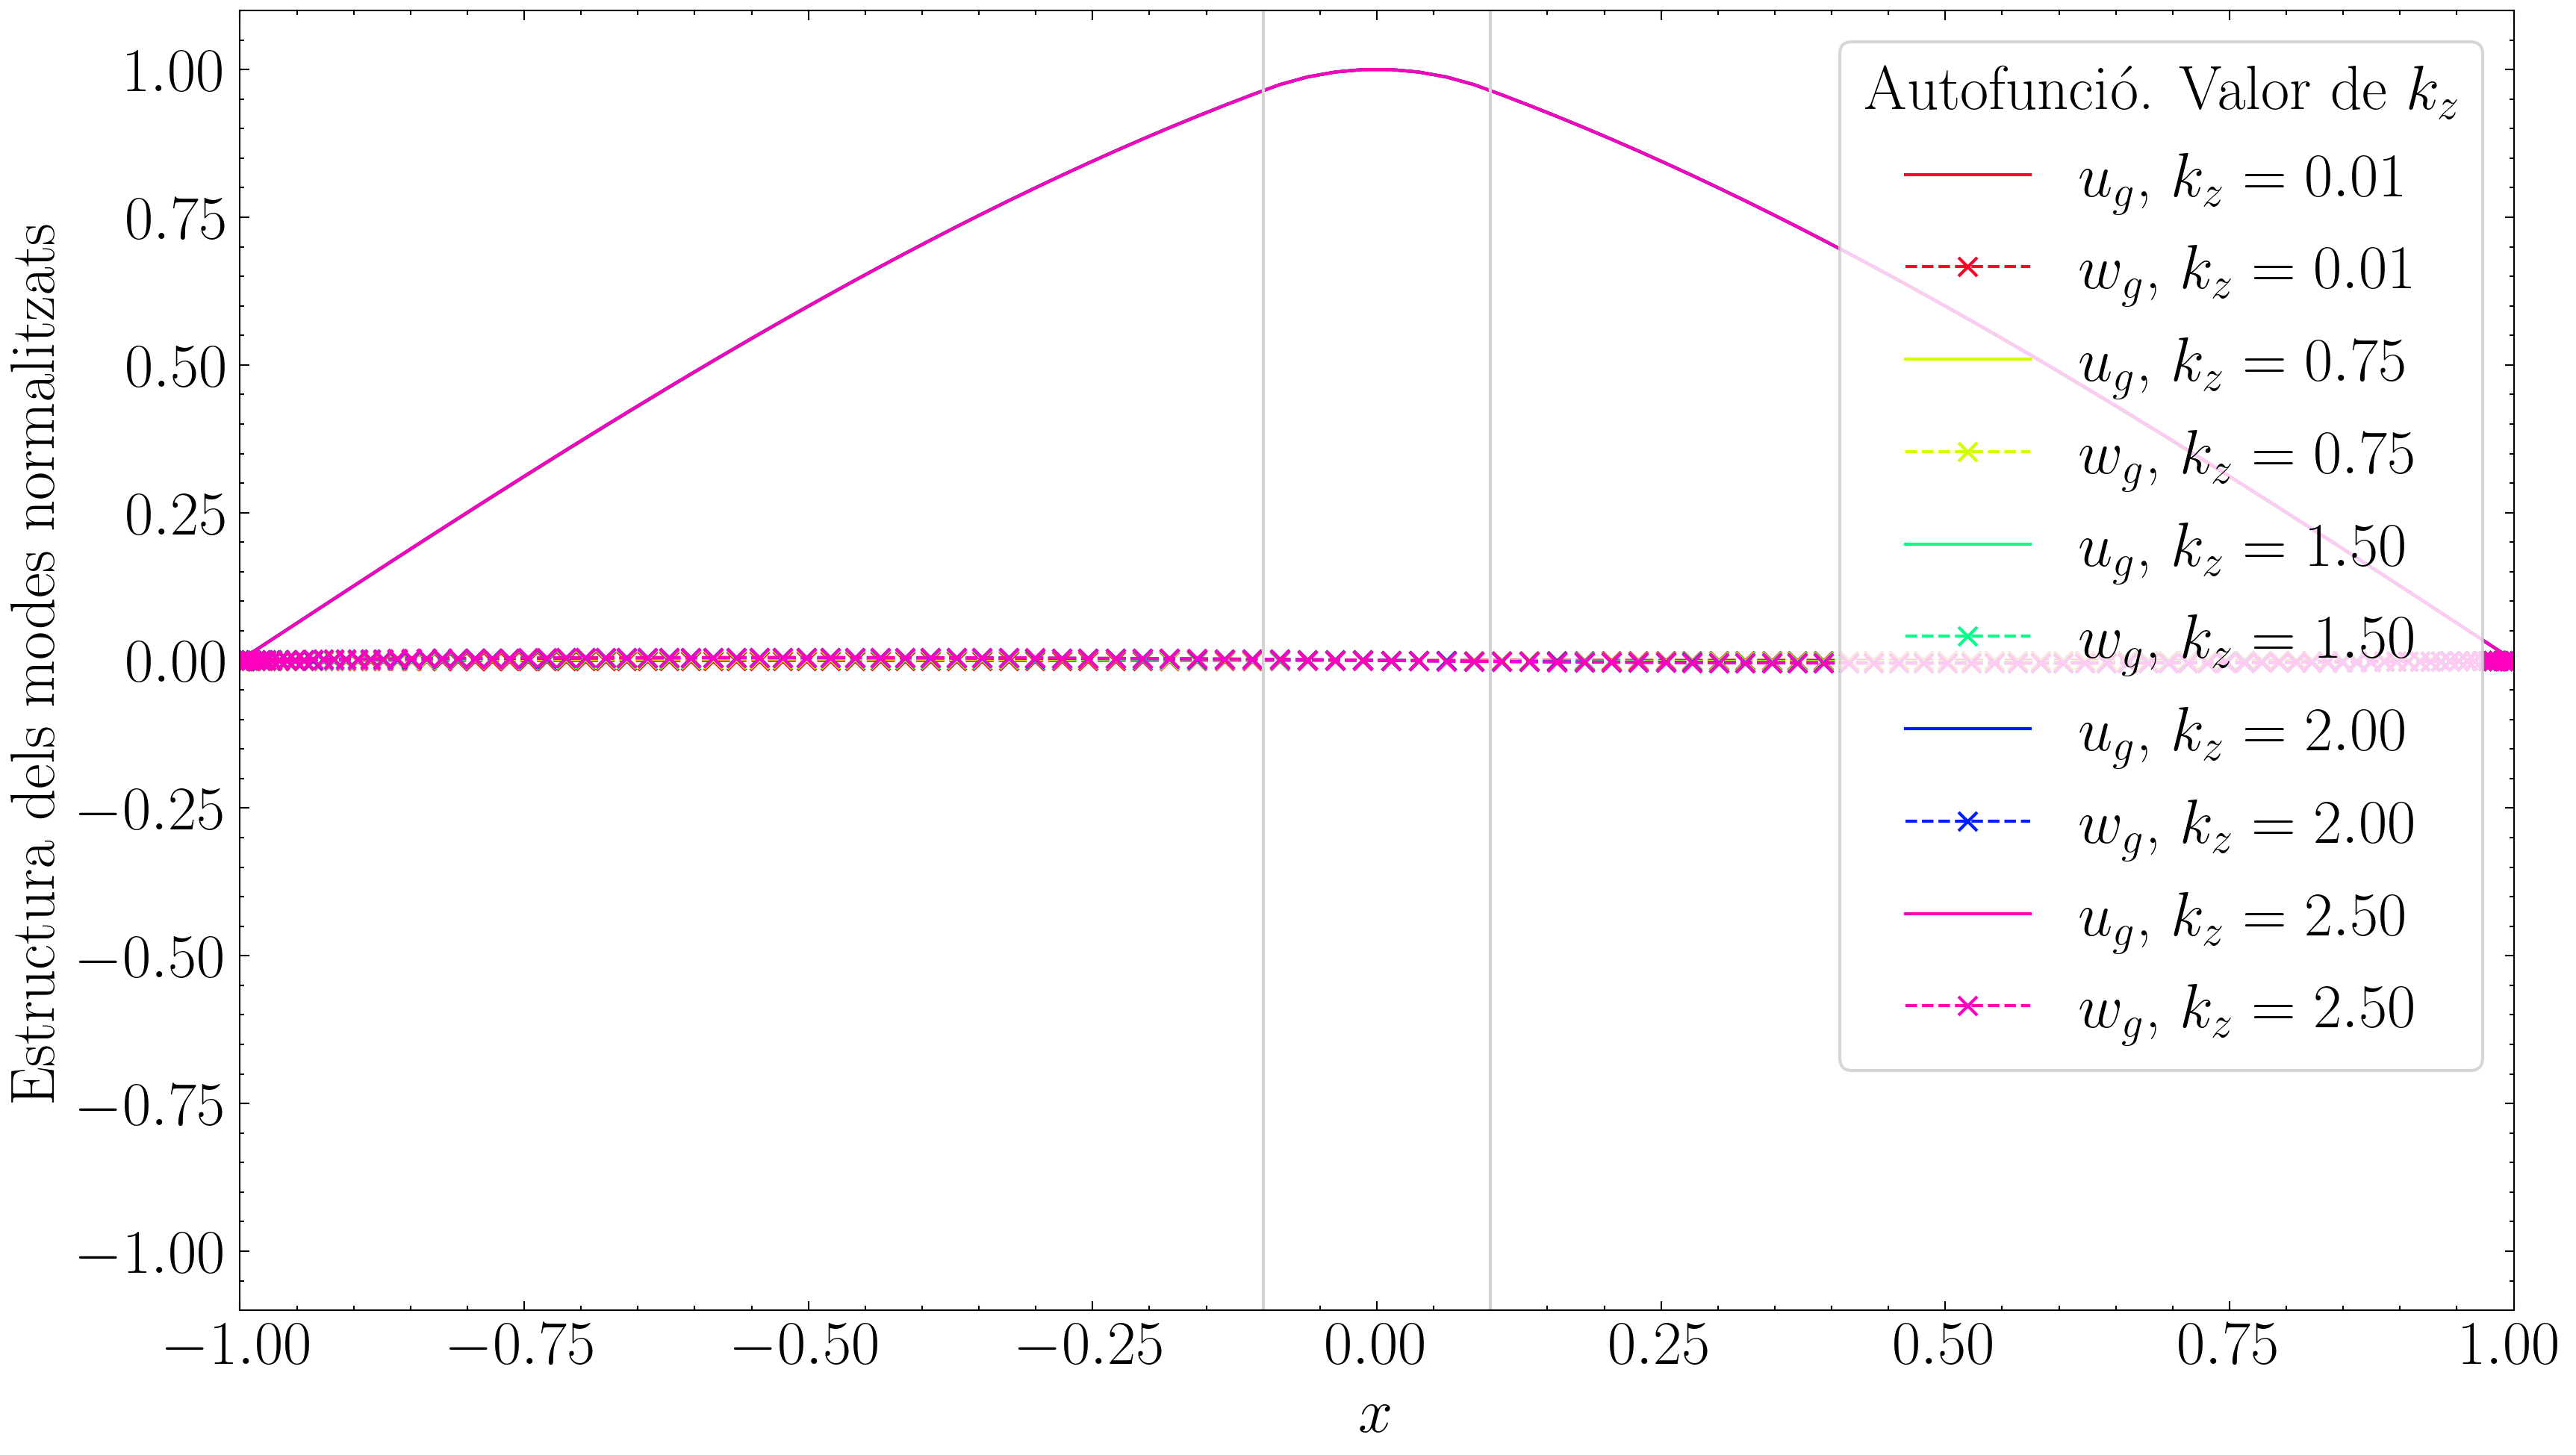

In [ ]:
### Definim bé kz_manual_fHL ###

### Velocitats a trossos ###
cp2 = 1
cc2 = 6
vAp2 = 20
vAc2 = 250

### Redefinim camps ###
c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2, cp2, cc2]) # Representa la c^2 en l'espai real ('g') a trossos.
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Nombre de kz's manualment ###
#kz_manual_fHL = np.array([0.01, 1.5, 3])
kz_manual_fHL = np.array([0.01, 0.75, 1.5, 2, 2.5])
#j_list_fHL = [0, 0, 0]
j_list_fHL = [0, 0, 0, 0, 0]

### Prepare colormap ###
#cmap = plt.get_cmap('jet', len(kz_manual_fHL))
#cmap = plt.get_cmap('brg', len(kz_manual_fHL))
cmap = plt.get_cmap('gist_rainbow', len(kz_manual_fHL))

### Plot ###
plt.figure(figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, kz in enumerate(kz_manual_fHL):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction

    n_mode_idx = np.argsort(solver.eigenvalues)[j_list_fHL[i]]  # Index of the mode
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is ug =", max_val)
    else:
        aux = wg
        print("Maximum value is wg =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    plt.plot(x, ug_normalized, label=f"$u_g$, $k_z={kz:.2f}$", linestyle='-', color=cmap(i))
    
    # Plot wg
    plt.plot(x, wg_normalized, label=f"$w_g$, $k_z={kz:.2f}$", linestyle='--', color=cmap(i), marker='x')


# Add labels, legend, and title
plt.xlabel("$x$")
plt.ylabel("Estructura dels modes normalitzats")
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.legend(title="Autofunció. Valor de $k_z$", loc="upper right", frameon=True)
plt.grid(False)
plt.tight_layout()
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)
#plt.savefig('Evolució_autofunció_fHL.png', dpi=300, bbox_inches='tight')
plt.show()

Maximum value is ug = -1.0949292777219561
Maximum value is ug = -1.0955349173665372
Maximum value is ug = -1.0954481582820705
Maximum value is ug = 1.0952398271693462
Maximum value is ug = -1.0950807265001758


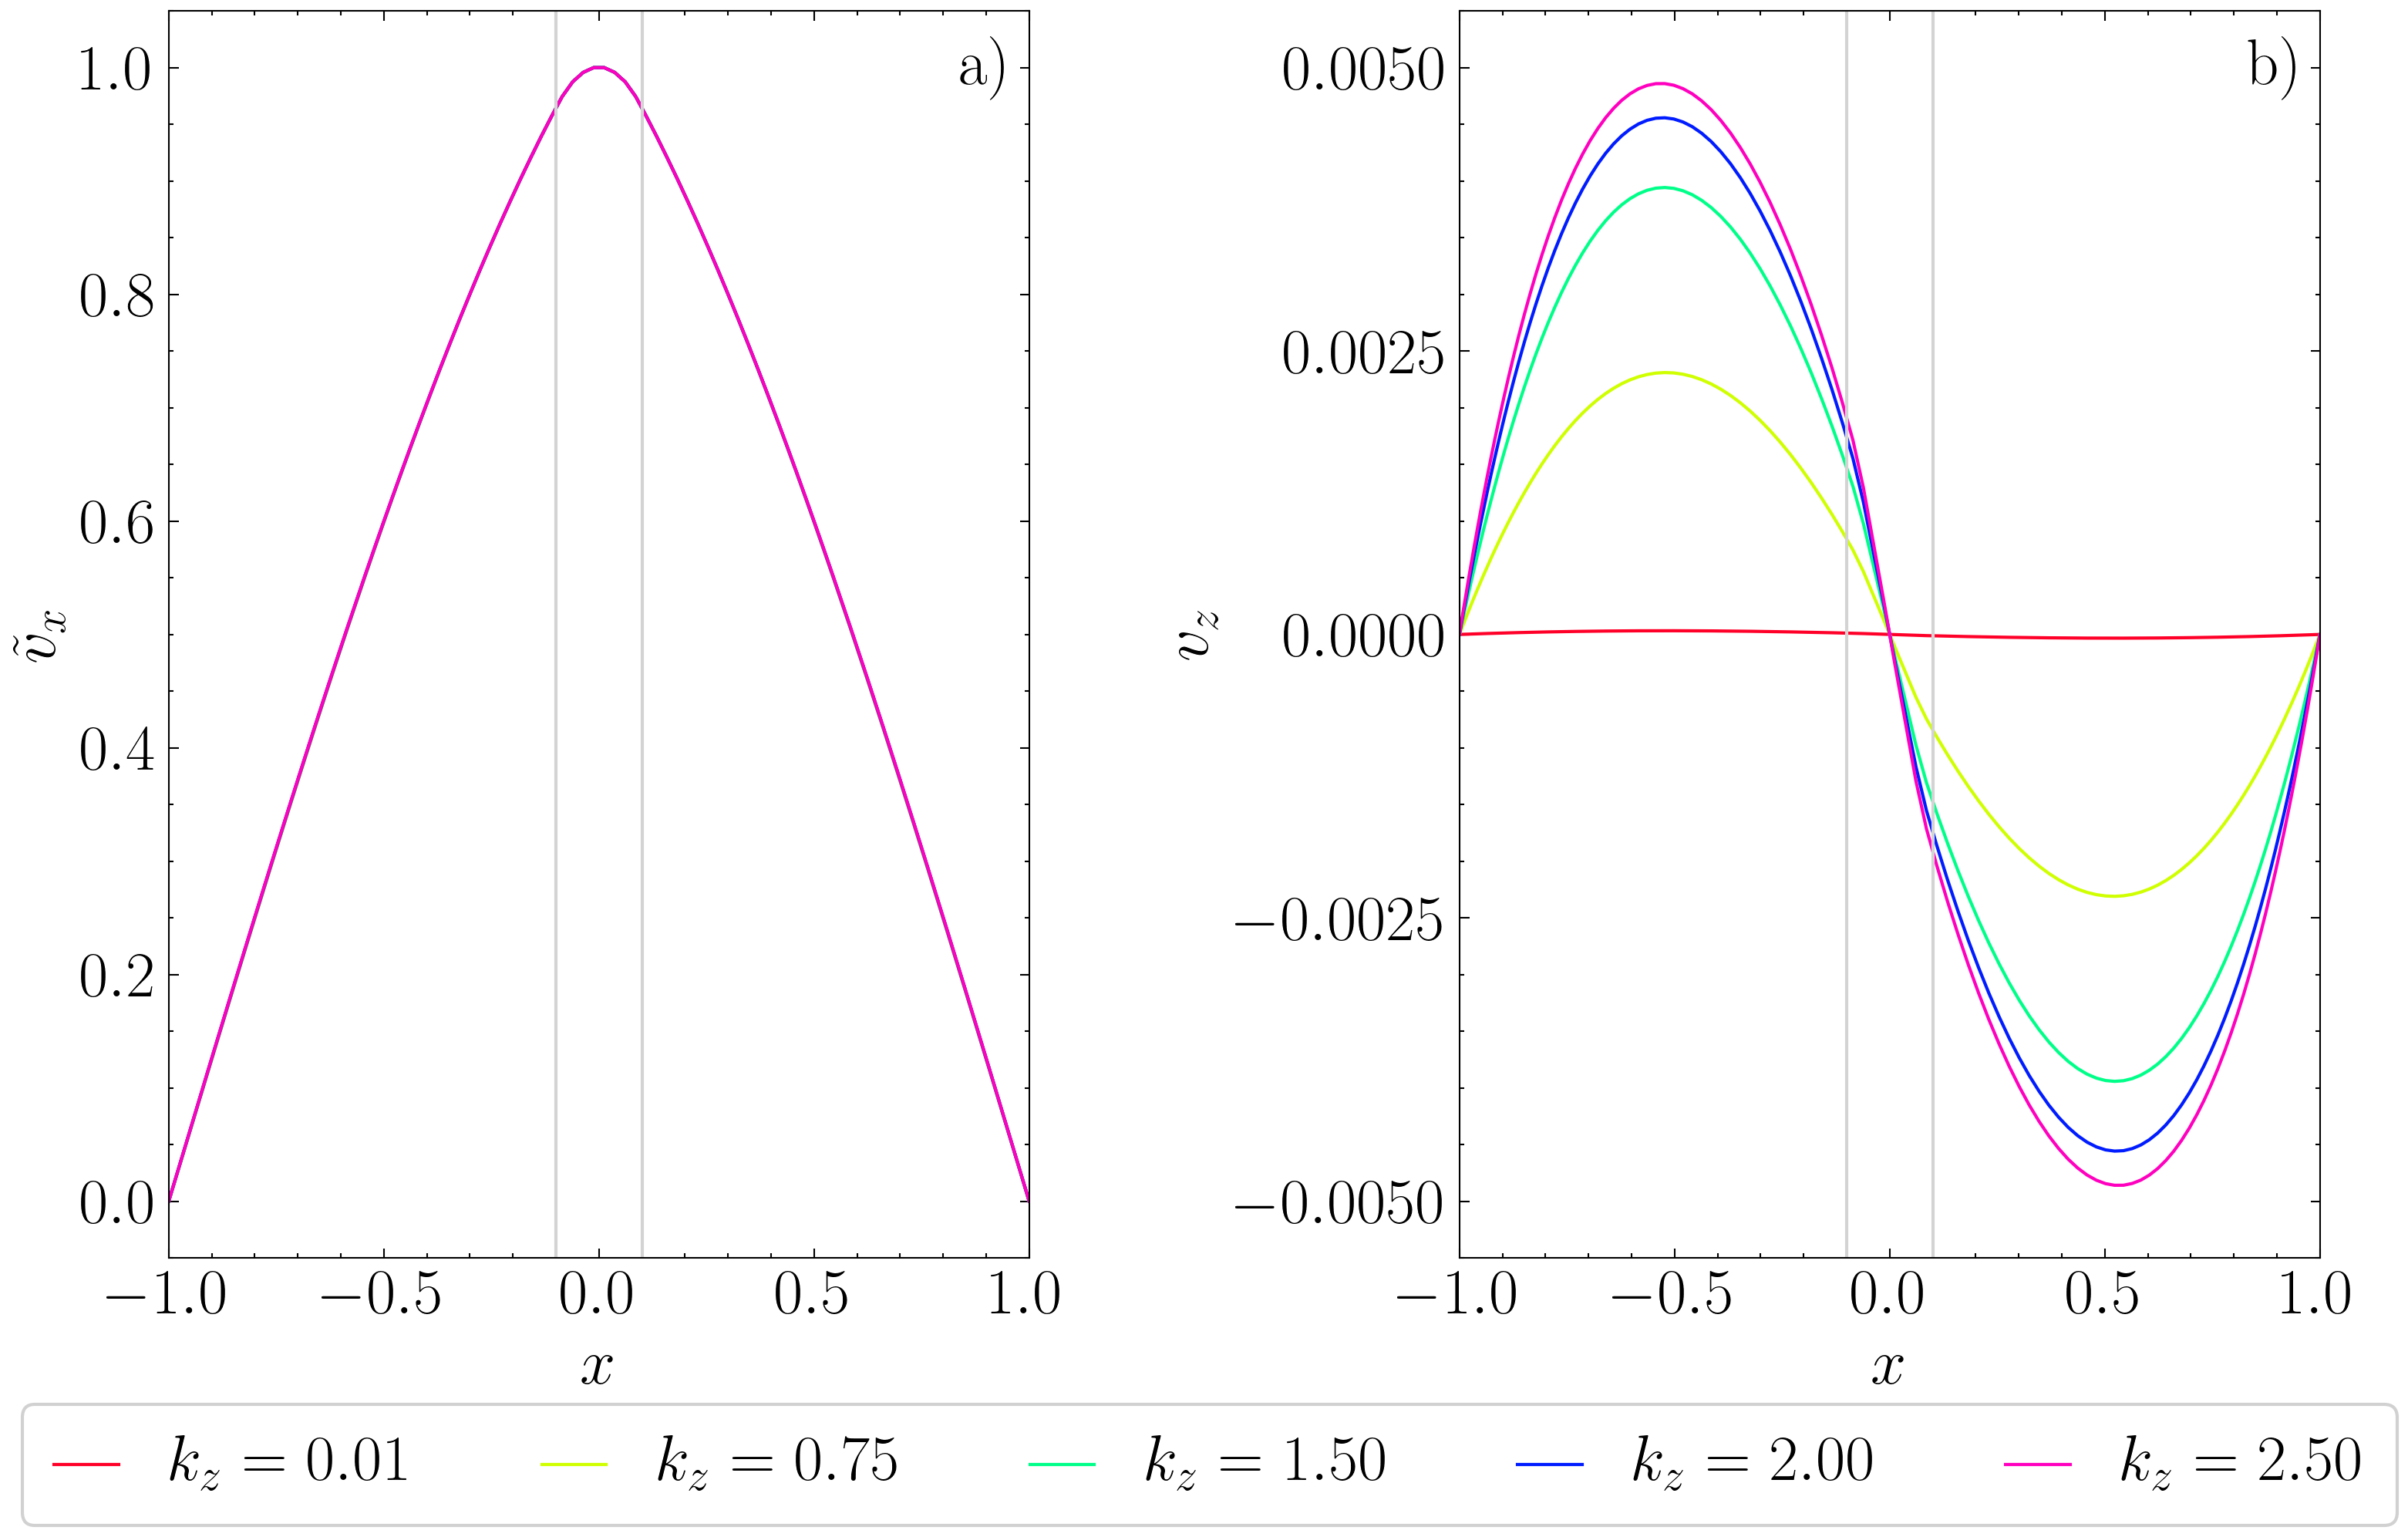

In [16]:
### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, kz in enumerate(kz_manual_fHL):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction
    
    n_mode_idx = np.argsort(solver.eigenvalues)[j_list_fHL[i]]  # Index of the mode
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is ug =", max_val)
    else:
        aux = wg
        print("Maximum value is wg =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    axs[0].plot(x, ug_normalized, label=f"$k_z={kz_manual_fHL[i]:.2f}$", linestyle='-', color=cmap(i))

    # Plot wg
    axs[1].plot(x, wg_normalized, label=f"$k_z={kz_manual_fHL[i]:.2f}$", linestyle='-', color=cmap(i))

# Format ug
axs[0].set_xlabel(r"$x$", fontsize=20)
axs[0].set_ylabel(r"$\tilde{v}_{x}$", fontsize=20)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-0.05, 1.05)
axs[0].tick_params(labelsize=20)
axs[0].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[0].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

# Format wg
axs[1].set_xlabel(r"$x$", fontsize=20)
axs[1].set_ylabel(r"$v_{z}$", fontsize=20)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-0.0055, 0.0055)
axs[1].set_yticks([-0.0050, -0.0025, 0, 0.0025, 0.0050])
axs[1].tick_params(labelsize=20)
axs[1].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[1].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

### Etiquetes a) i b) ###
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

### Llegenda ###
fig.legend(
    handles=axs[0].get_lines()[:len(kz_manual_fHL)],  # Use lines from the first subplot (they share labels/colors)
    labels=[f"$k_z = {kz_manual_fHL[i]:.2f}$" for i in range(len(kz_manual_fHL))],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=len(kz_manual_fHL),
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1,
    handleheight=0.1,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9,
)

# -------------------- Finalització --------------------
plt.subplots_adjust(wspace=0.5)
#plt.savefig("Evolució_autofuncions_fHL_subplots.png", dpi=300, bbox_inches='tight')
plt.show()

# Representació de les autofuncions del mode fHL segons el valor de cc2

Maximum value is ug = 1.1210584528439493
Maximum value is ug = 0.9661894114227279
Maximum value is ug = -0.9998156676113523
Maximum value is ug = 1.0544086959026415
Maximum value is ug = -1.0794789632129016


[]

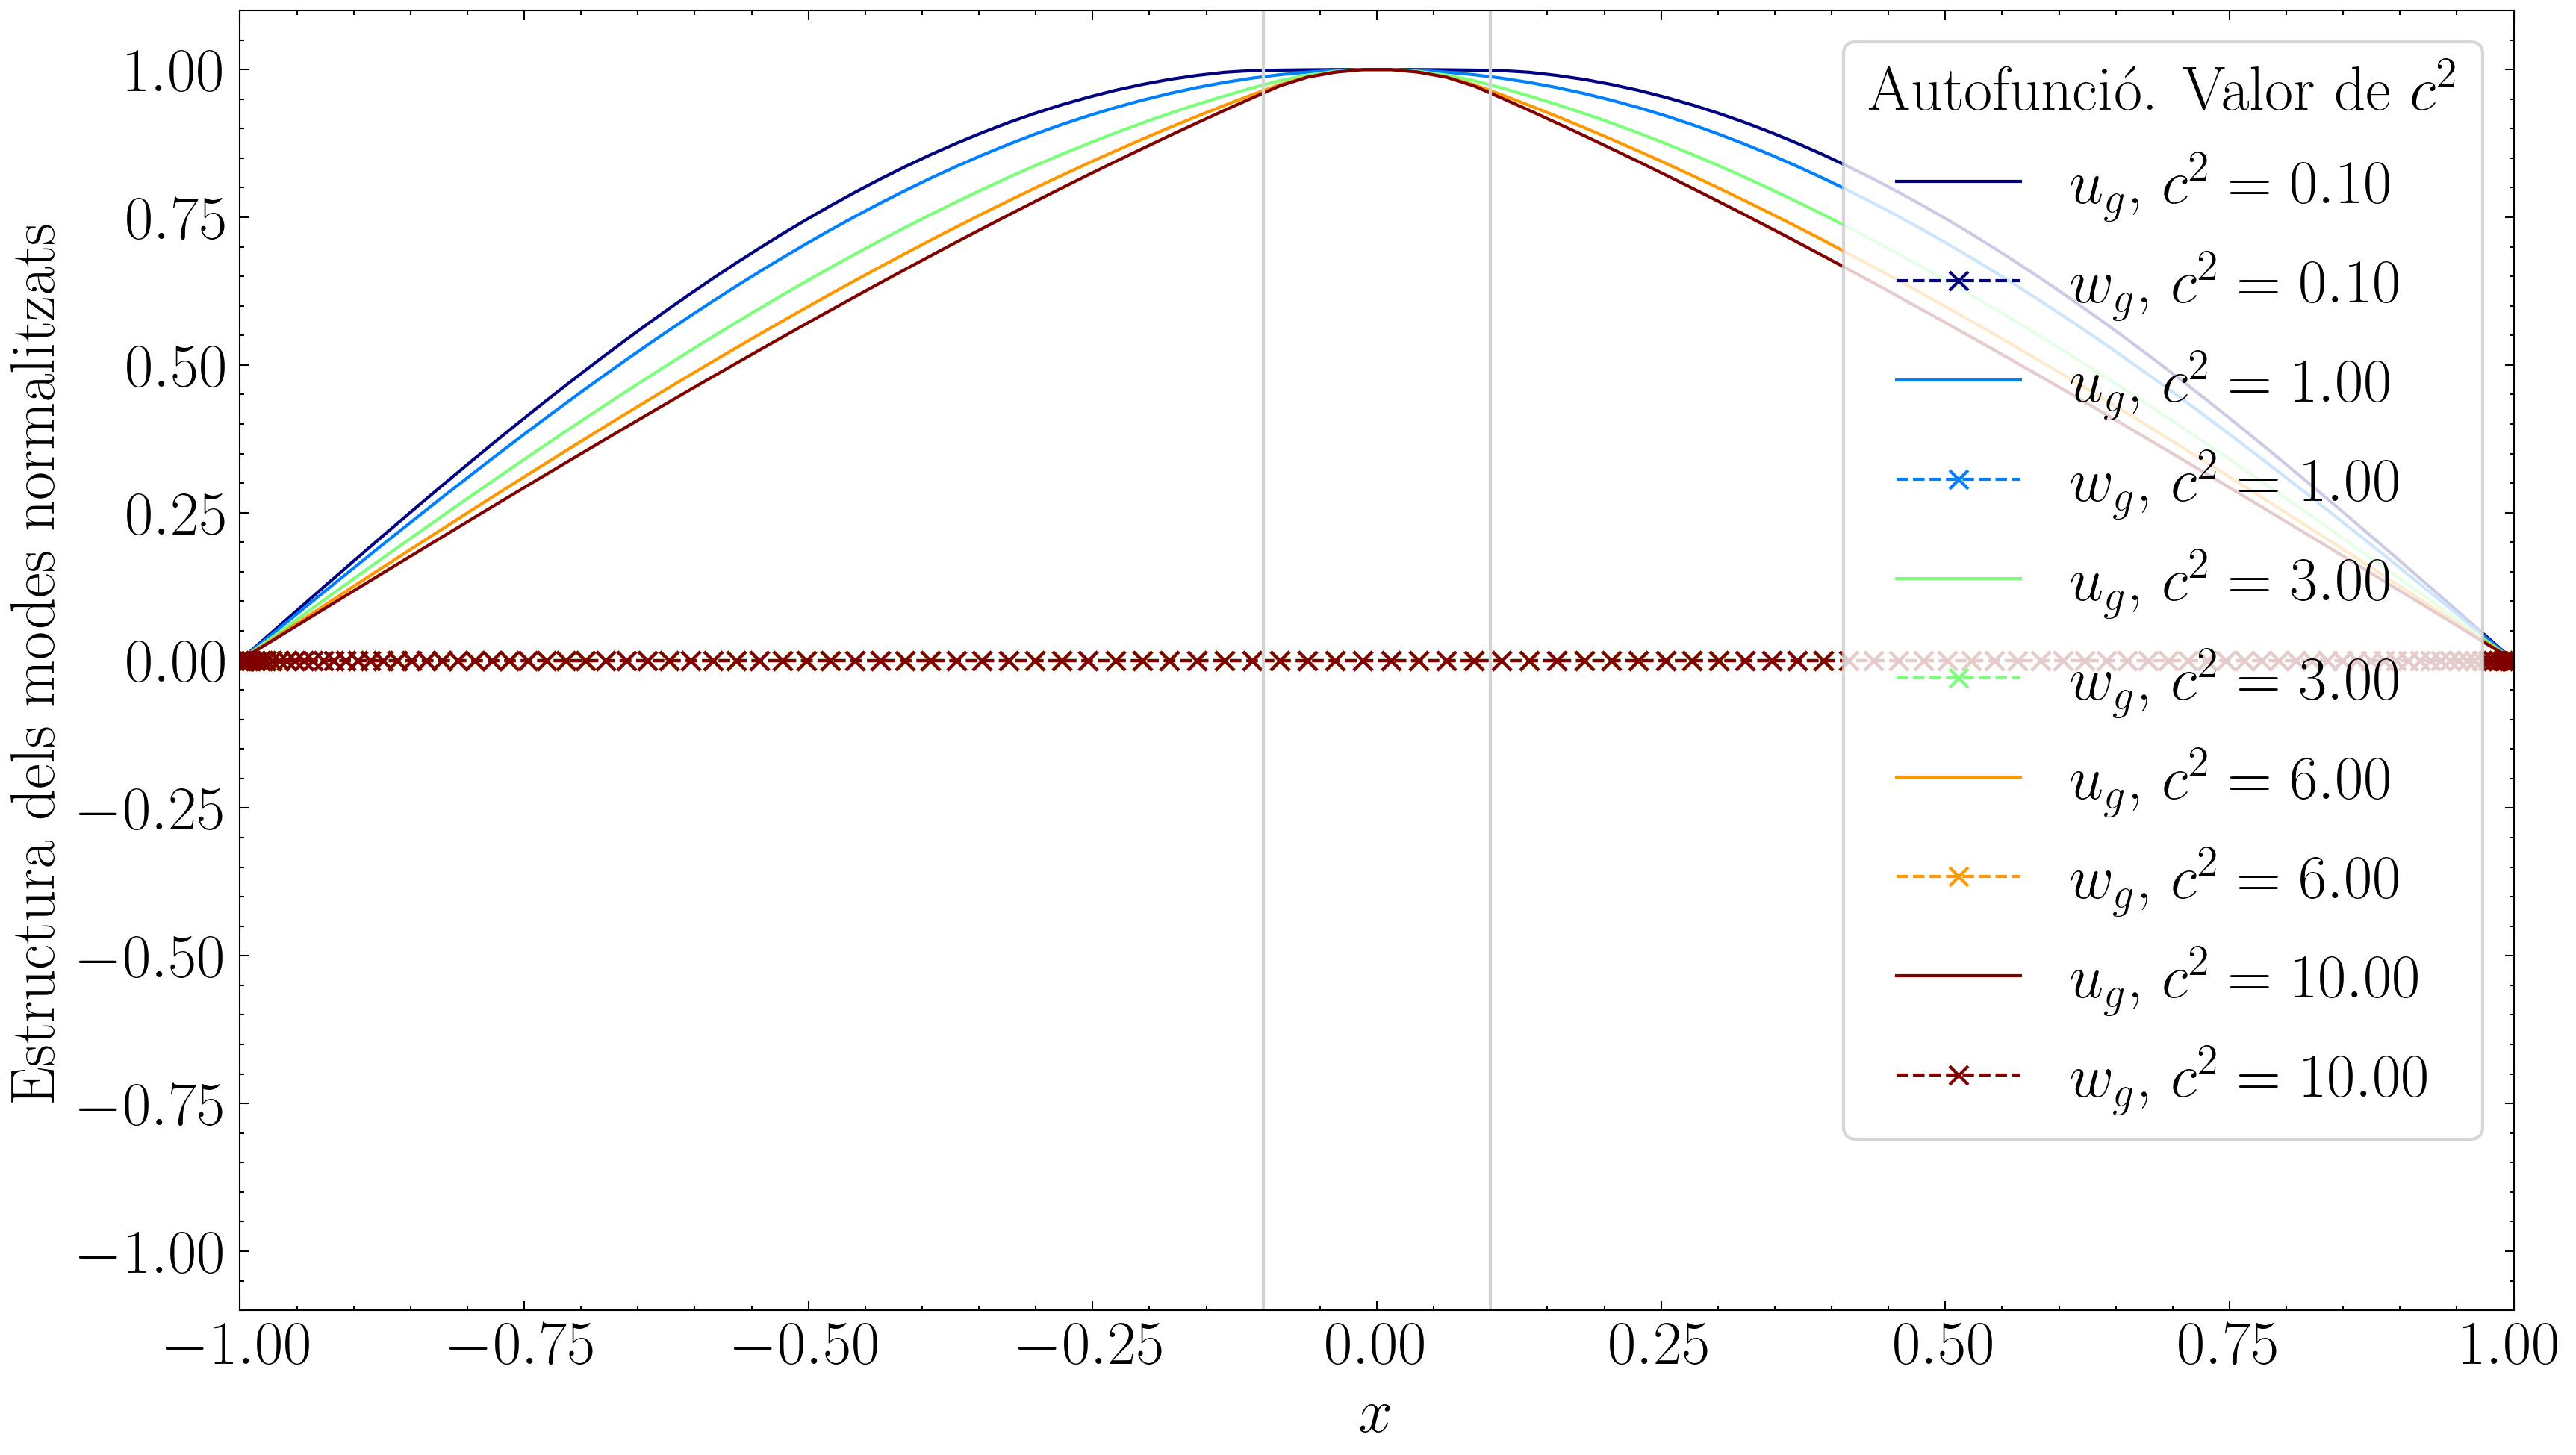

In [20]:
### Definim bé cc2 ###

### Velocitats a trossos ###
cp2 = 1
#cc2 = 6
vAp2 = 20
vAc2 = 250

### Definim kz i cc2 manualment ###
kz = 0
cc2 = np.array([0.1, 1, 3, 6, 10])  # Velocitat al quadrat en la regió central

### Redefinim camps ###
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Nombre de kz's manualment ###
kz_manual_fHL = np.array([0.01, 0.75, 1.5, 2, 2.5])
j_list_fHL = [0, 0, 0, 0, 0]

### Prepare colormap ###
cmap = plt.get_cmap('jet', len(kz_manual_fHL))
#cmap = plt.get_cmap('brg', len(kz_manual_fHL))
#cmap = plt.get_cmap('gist_rainbow', len(kz_manual_fHL))

plt.figure(figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, csc2 in enumerate(cc2):
    ### Redefinim camps per a cada c2 manualment ###
    c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
    c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2[i], cp2, cc2[i]]) # Representa la c^2 en l'espai real ('g') a trossos.


    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])

    # Extract the first eigenvalue and its corresponding eigenfunction
    n_mode_idx = np.argsort(solver.eigenvalues)[0]  # Index of the mode
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is ug =", max_val)
    else:
        aux = wg
        print("Maximum value is wg =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    plt.plot(x, ug_normalized, label=f"$u_g$, $c^2={csc2:.2f}$", linestyle='-', color=cmap(i))

    # Plot wg
    plt.plot(x, wg_normalized, label=f"$w_g$, $c^2={csc2:.2f}$", linestyle='--', color=cmap(i), marker='x')

# Add labels, legend, and title
plt.xlabel("$x$")
plt.ylabel("Estructura dels modes normalitzats")
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.legend(title="Autofunció. Valor de $c^2$", loc="upper right", frameon=True)
plt.grid(False)
plt.tight_layout()
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)
#plt.savefig('Evolució_autofunció_fHL_c2.png', dpi=300, bbox_inches='tight')
plt.plot()

Maximum value is ug = 1.1210584528439493
Maximum value is ug = 0.9661894114227279
Maximum value is ug = -0.9998156676113523
Maximum value is ug = 1.0544086959026415
Maximum value is ug = -1.0794789632129016


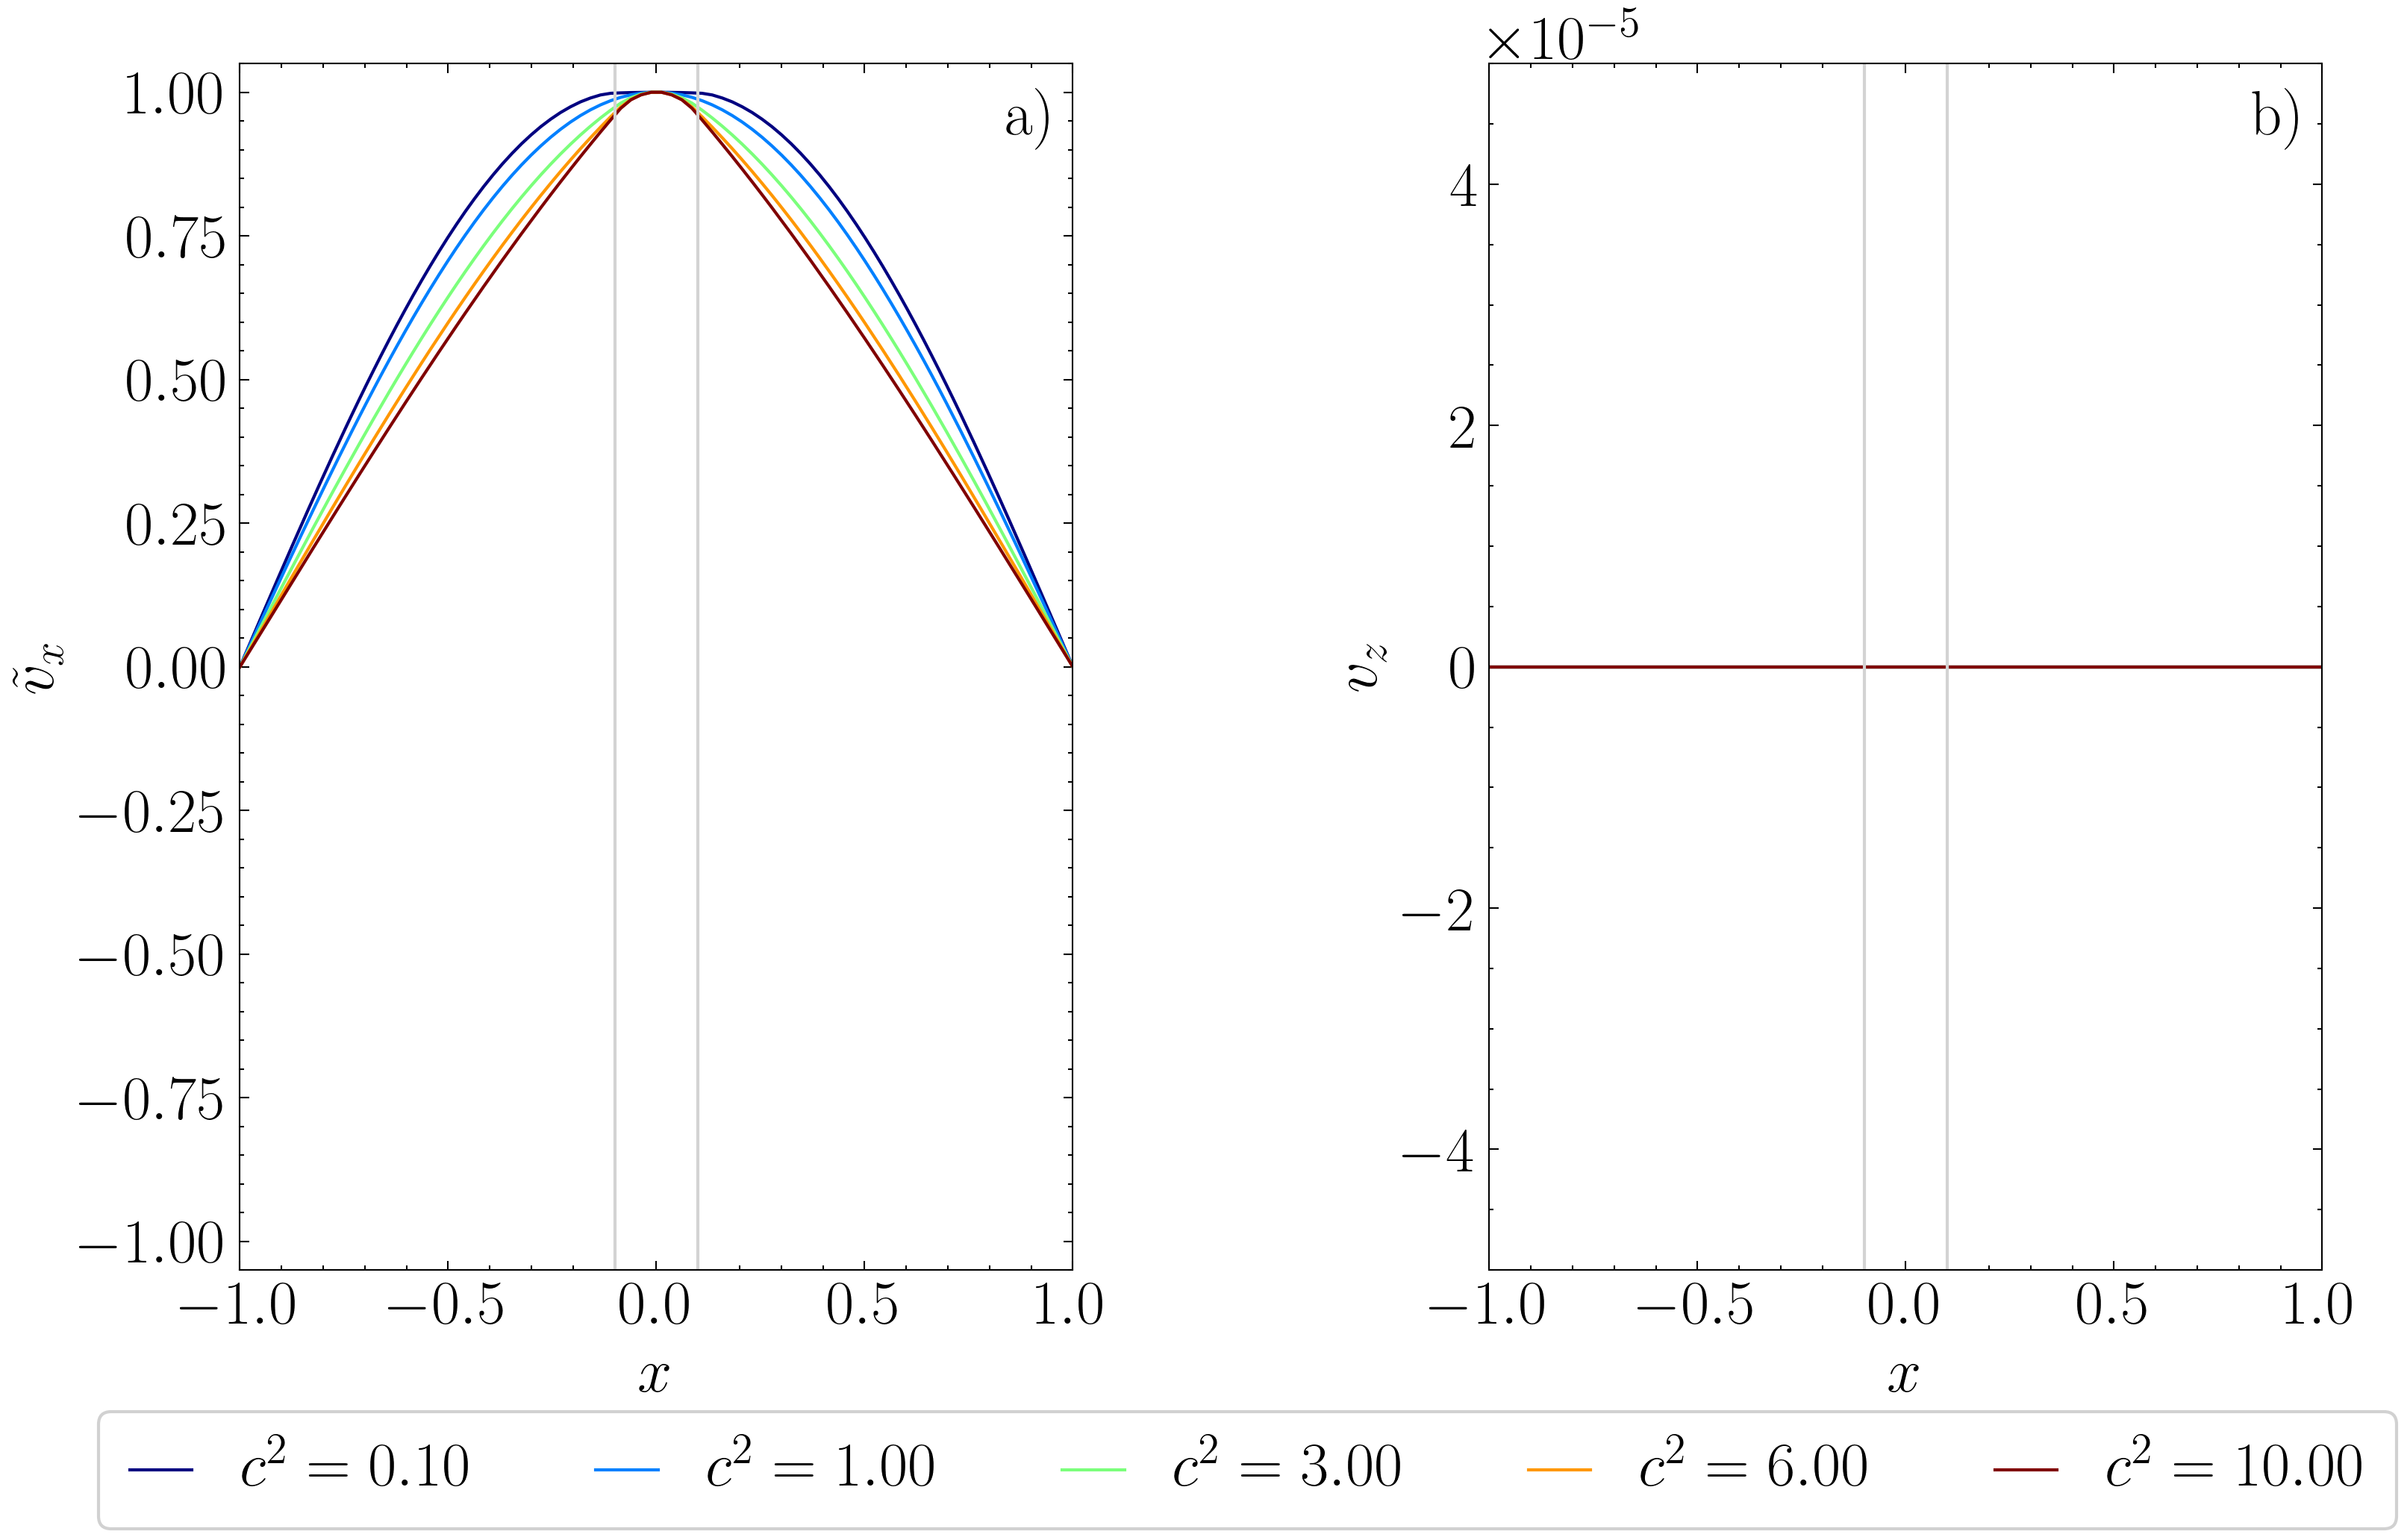

In [23]:
### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, csc2 in enumerate(cc2):
    ### Redefinim camps per a cada c2 manualment ###
    c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
    c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2[i], cp2, cc2[i]]) # Representa la c^2 en l'espai real ('g') a trossos.
    
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction
    
    n_mode_idx = np.argsort(solver.eigenvalues)[0]  # Index of the mode
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is ug =", max_val)
    else:
        aux = wg
        print("Maximum value is wg =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    axs[0].plot(x, ug_normalized, label=f"$u_g$, $c^2={csc2:.2f}$", linestyle='-', color=cmap(i))

    # Plot wg
    axs[1].plot(x, wg_normalized, label=f"$w_g$, $c^2={csc2:.2f}$", linestyle='-', color=cmap(i))

# Format ug
axs[0].set_xlabel(r"$x$", fontsize=20)
axs[0].set_ylabel(r"$\tilde{v}_{x}$", fontsize=20)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1.05, 1.05)
axs[0].tick_params(labelsize=20)
axs[0].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[0].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

# Format wg
axs[1].set_xlabel(r"$x$", fontsize=20)
axs[1].set_ylabel(r"$v_{z}$", fontsize=20)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-0.00005, 0.00005)
axs[1].tick_params(labelsize=20)
axs[1].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[1].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

### Etiquetes a) i b) ###
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

### Llegenda ###
fig.legend(
    handles=axs[0].get_lines()[:len(cc2)],  # Use lines from the first subplot (they share labels/colors)
    labels=[f"$c^2 = {cc2[i]:.2f}$" for i in range(len(cc2))],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=len(kz_manual_fHL),
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1,
    handleheight=0.1,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9,
)

# -------------------- Finalització --------------------
plt.subplots_adjust(wspace=0.5)
#plt.savefig("Evolució_autofuncions_fHL_subplots.png", dpi=300, bbox_inches='tight')
plt.show()

# Evolució autofuncions fHR

Maximum value is from wg; max_val = -1.0949292777219561
Maximum value is from wg; max_val = 1.1288102006317433
Maximum value is from wg; max_val = 1.1497805500874174
Maximum value is from wg; max_val = 1.2225566965318193
Maximum value is from wg; max_val = -1.2673682394894552


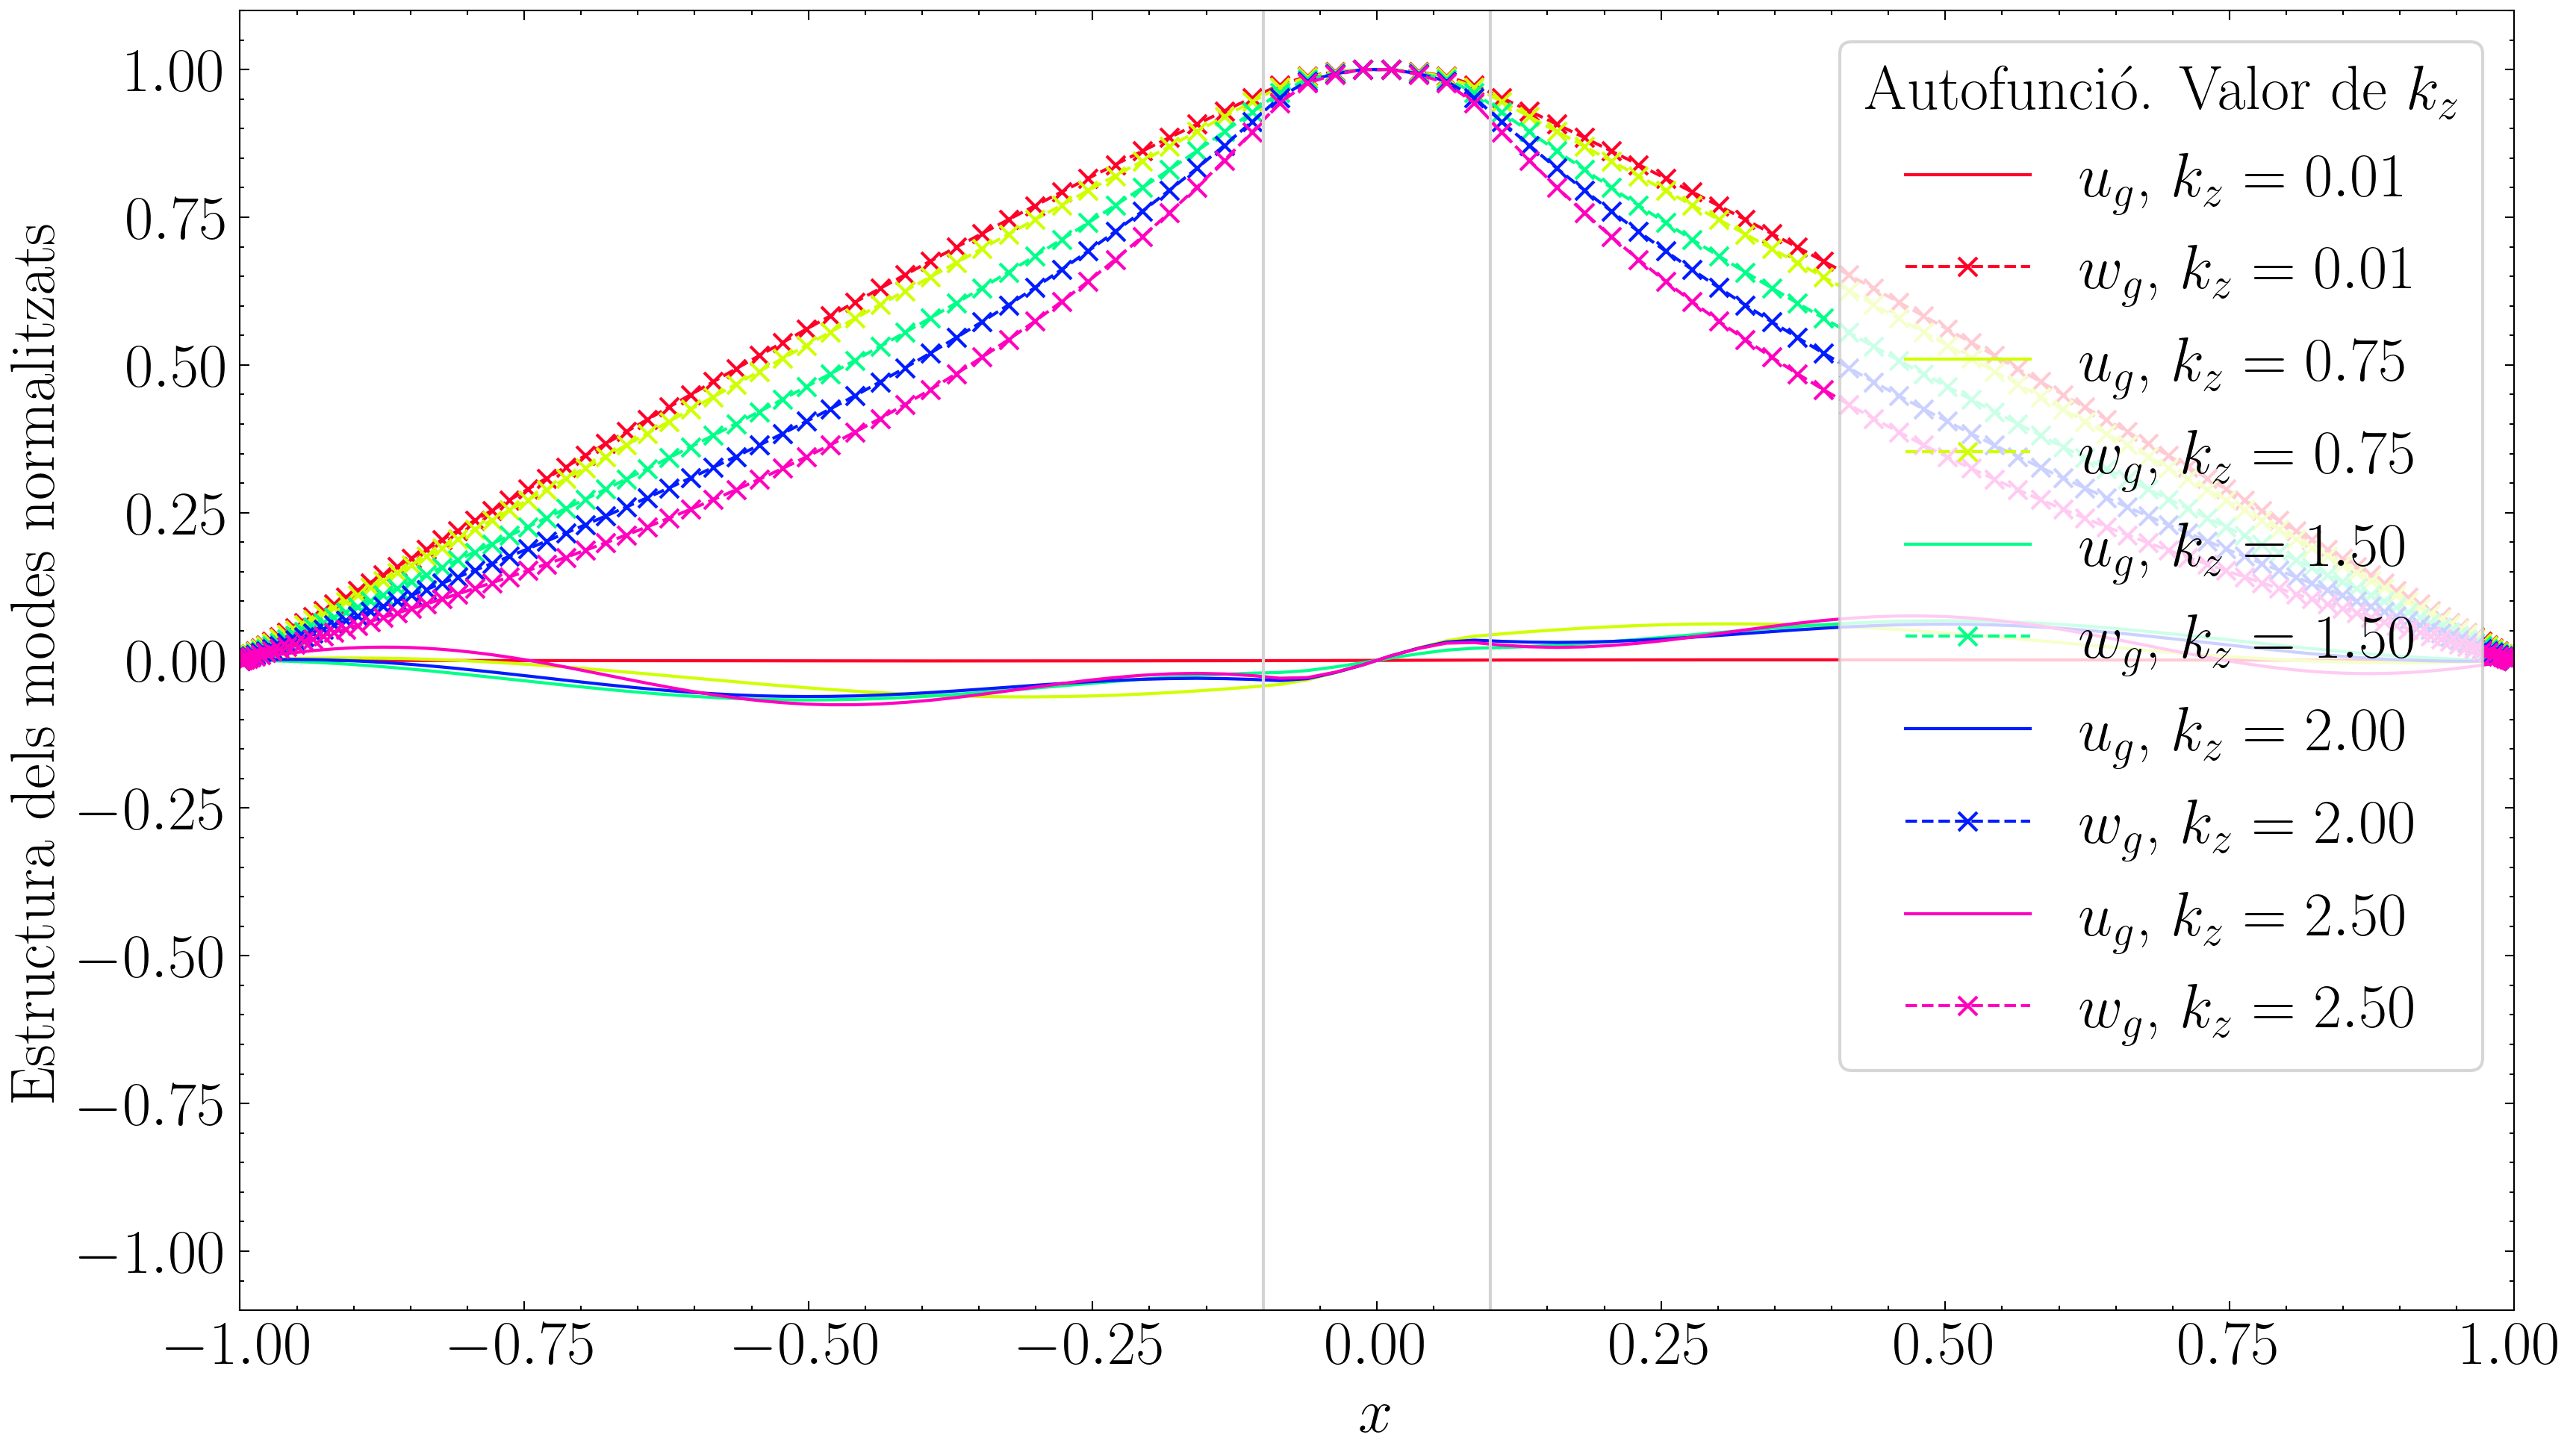

In [18]:
### Definim bé kz_manual_fHR ###

### Velocitats a trossos ###
cp2 = 1
cc2 = 6
vAp2 = 20
vAc2 = 250

### Redefinim camps ###
c2 = dist.Field(name='c2', bases=xbasis) # c2 = Velocitat al quadrat ----- és interessant definir-la directament al quadrat ja que és un camp i així evitam fer c.evaluate()**2
c2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [cc2, cp2, cc2]) # Representa la c^2 en l'espai real ('g') a trossos.
vA2 = dist.Field(name='vA2', bases=xbasis) # vA2 = Alfven velocity squared
vA2['g'] = np.piecewise(x, [x < -xp, (-xp <= x) * (x <= xp), x > xp], [vAc2, vAp2, vAc2]) # Representa la velocitat d'Alfven en l'espai real ('g') a trossos.

### Nombre de kz's manualment ###
kz_manual_fHR = np.array([0.01, 0.75, 1.5, 2, 2.5])
kz_manual_3hEL = np.array([0.01, 0.5, 1.5, 3])

j_list_fHR = [3, 3, 4, 5, 6]
j_list_3hEL = [4, 4, 3, 3]

### Prepare colormap ###
#cmap = plt.get_cmap('jet', len(kz_manual_fHR))
#cmap = plt.get_cmap('brg', len(kz_manual_fHR))
cmap = plt.get_cmap('gist_rainbow', len(kz_manual_fHR))

### Plot ###
plt.figure(figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, kz in enumerate(kz_manual_fHR):
#for i, kz in enumerate(kz_manual_3hEL):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction

    n_mode_idx = np.argsort(solver.eigenvalues)[j_list_fHR[i]]  # Index of the mode
    #n_mode_idx = np.argsort(solver.eigenvalues)[j_list_3hEL[i]]  # Index of the mode
    
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is from ug; max_val =", max_val)
    else:
        aux = wg
        print("Maximum value is from wg; max_val =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    plt.plot(x, ug_normalized, label=f"$u_g$, $k_z={kz:.2f}$", linestyle='-', color=cmap(i))
    
    # Plot wg
    plt.plot(x, wg_normalized, label=f"$w_g$, $k_z={kz:.2f}$", linestyle='--', color=cmap(i), marker='x')


# Add labels, legend, and title
plt.xlabel("$x$")
plt.ylabel("Estructura dels modes normalitzats")
plt.xlim(-1, 1)
plt.ylim(-1.1, 1.1)
plt.legend(title="Autofunció. Valor de $k_z$", loc="upper right", frameon=True)
plt.grid(False)
plt.tight_layout()
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)
#plt.savefig('Evolució_autofunció_fHR.png', dpi=300, bbox_inches='tight')
#plt.savefig('Evolució_autofunció_3hEL.png', dpi=300, bbox_inches='tight')
plt.show()

Maximum value is from wg; max_val = -1.313189853073464
Maximum value is from wg; max_val = 1.1288102006317433
Maximum value is from wg; max_val = 1.1497805500874174
Maximum value is from wg; max_val = 1.2225566965318193
Maximum value is from wg; max_val = -1.2673682394894552


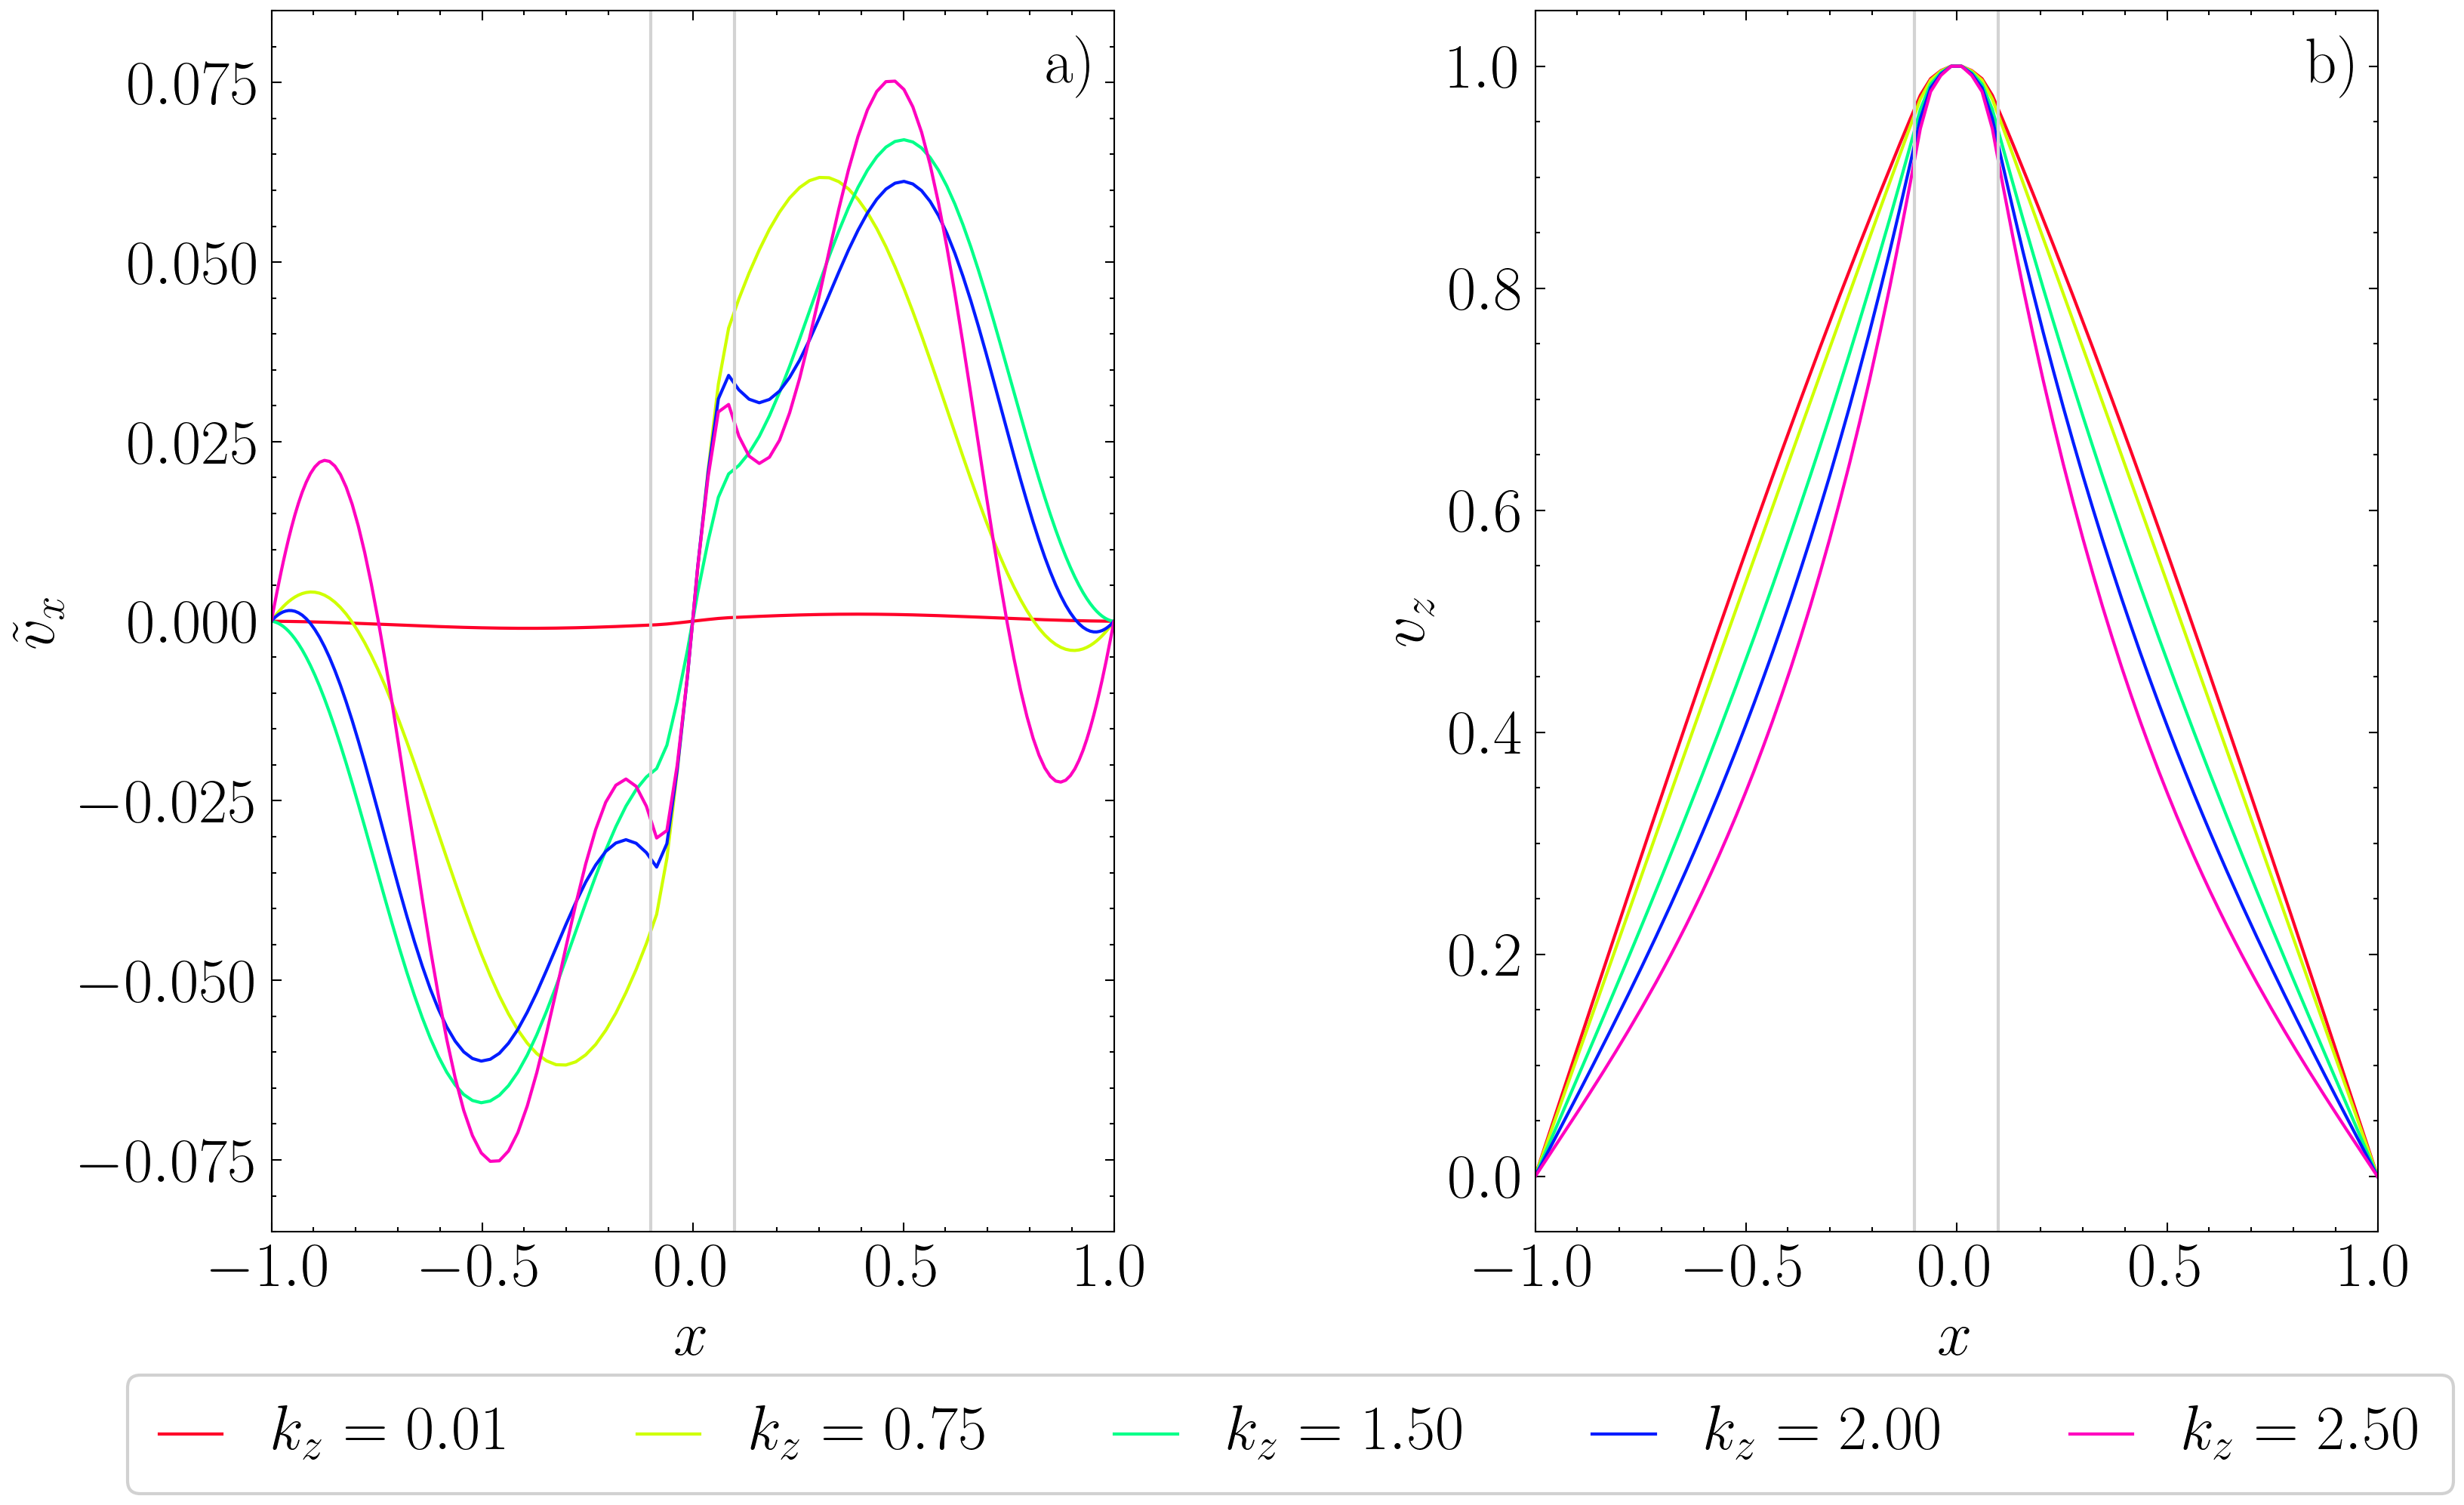

In [19]:
### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))
x = dist.local_grid(xbasis)
for i, kz in enumerate(kz_manual_fHR):
#for i, kz in enumerate(kz_manual_3hEL):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction
    
    n_mode_idx = np.argsort(solver.eigenvalues)[j_list_fHR[i]]  # Index of the mode
    #n_mode_idx = np.argsort(solver.eigenvalues)[j_list_3hEL[i]]  # Index of the mode

    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        aux = ug
        print("Maximum value is from ug; max_val =", max_val)
    else:
        aux = wg
        print("Maximum value is from wg; max_val =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    axs[0].plot(x, ug_normalized, label=f"$k_z={kz_manual_fHR[i]:.2f}$", linestyle='-', color=cmap(i))

    # Plot wg
    axs[1].plot(x, wg_normalized, label=f"$k_z={kz_manual_fHR[i]:.2f}$", linestyle='-', color=cmap(i))

# Format ug
axs[0].set_xlabel(r"$x$", fontsize=20)
axs[0].set_ylabel(r"$\tilde{v}_{x}$", fontsize=20)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-0.085, 0.085)
axs[0].set_yticks([-0.075, -0.05, -0.025, 0, 0.025, 0.05, 0.075])
axs[0].tick_params(labelsize=20)
axs[0].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[0].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

# Format wg
axs[1].set_xlabel(r"$x$", fontsize=20)
axs[1].set_ylabel(r"$v_{z}$", fontsize=20)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-0.05, 1.05)
axs[1].tick_params(labelsize=20)
axs[1].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[1].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

### Etiquetes a) i b) ###
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

### Llegenda ###
fig.legend(
    handles=axs[0].get_lines()[:len(kz_manual_fHR)],  # Use lines from the first subplot (they share labels/colors)
    labels=[f"$k_z = {kz_manual_fHR[i]:.2f}$" for i in range(len(kz_manual_fHR))],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=len(kz_manual_fHR),
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1,
    handleheight=0.1,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9,
)

# -------------------- Finalització --------------------
plt.subplots_adjust(wspace=0.5)
#plt.savefig("Evolució_autofuncions_fHR_subplots.png", dpi=300, bbox_inches='tight')
plt.show()

# Evolució autofuncions en l'acoblament (n=4, primer ràpid i després lent...)

kz = 0.9 , i = 0
Maximum value is wg = 1.1485913996134833
kz = 0.95 , i = 1
Maximum value is wg = 1.1231573110648052
kz = 1.0 , i = 2
Maximum value is wg = 0.8465443537645312
kz = 1.05 , i = 3
Maximum value is ug = 0.4904000261242596
kz = 1.1 , i = 4
Maximum value is ug = 0.501173198805197


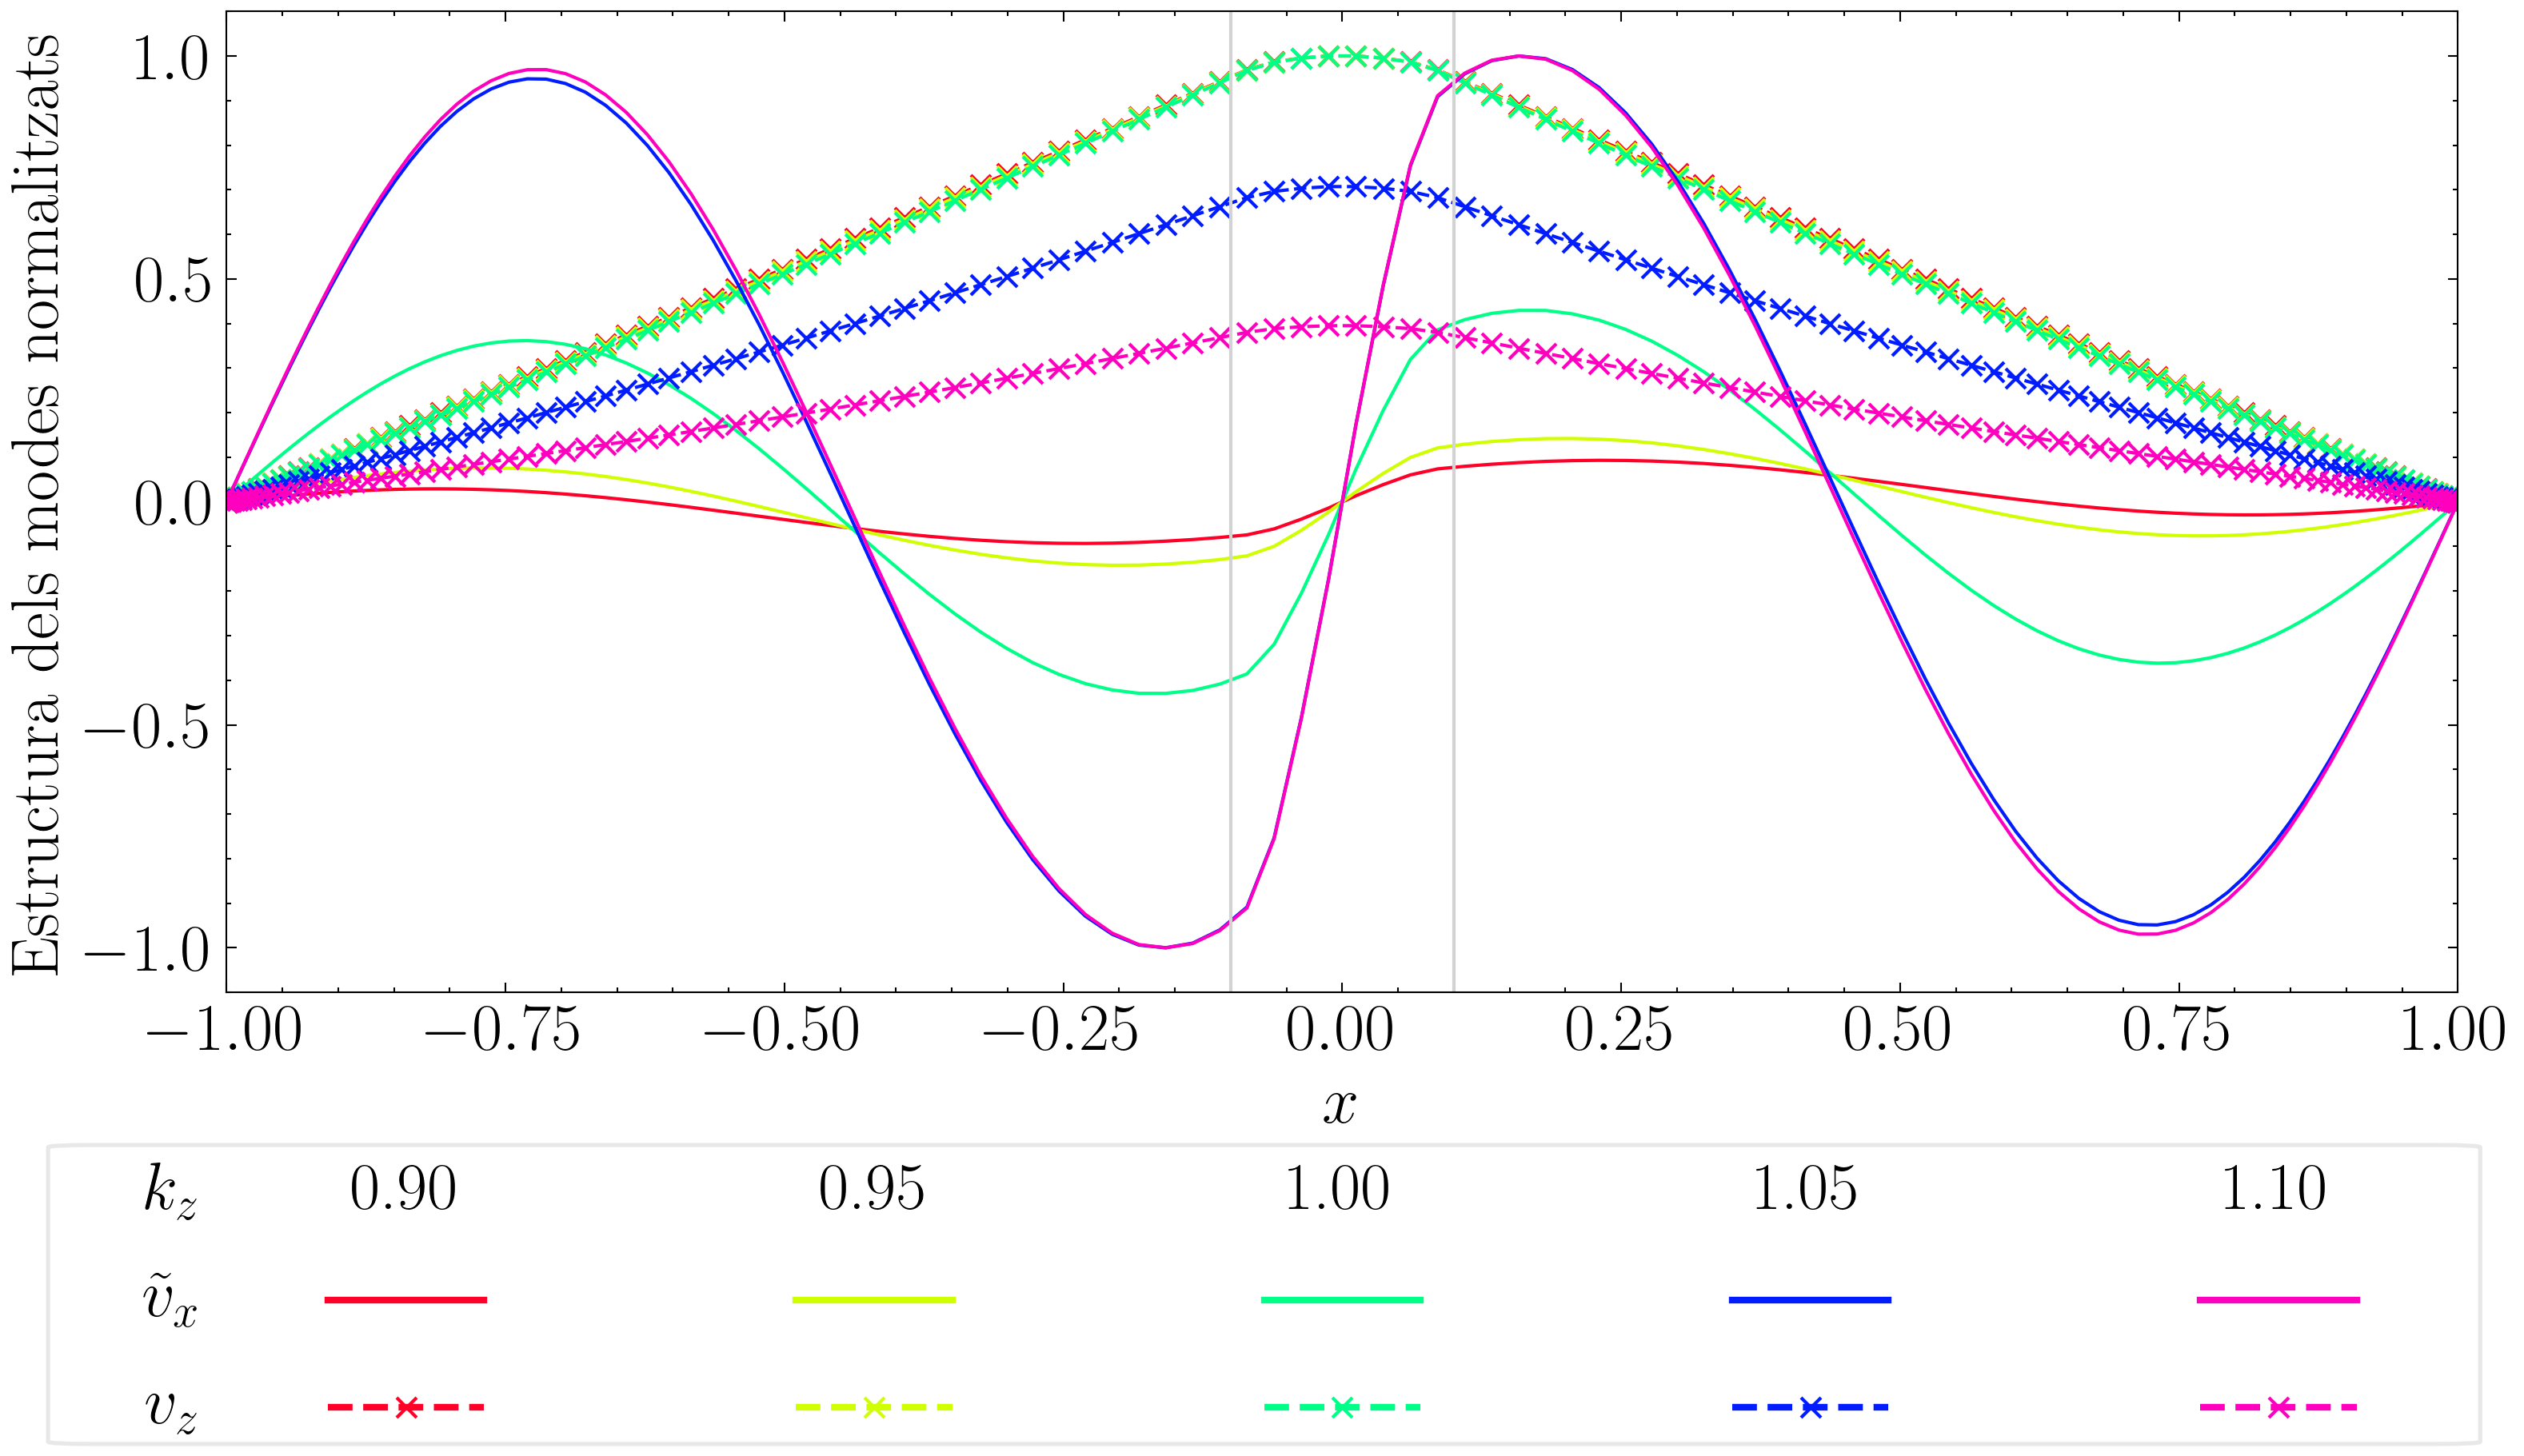

In [20]:
### Definim kz_manual_n_4 ###
kz_manual_n_4 = np.array([0.90, 0.95, 1.00, 1.05, 1.10])

### Cream llista de colors ###
cmap = plt.get_cmap('gist_rainbow', len(kz_manual_n_4))

### Crear figura i eix principal ###
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 1, height_ratios=[10, 1.2], figure=fig)
ax = fig.add_subplot(gs[0])

x = dist.local_grid(xbasis)
for i, kz in enumerate(kz_manual_n_4):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")  # (17')
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")  # (19')
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    # Solve the eigenvalue problem
    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    
    # Extract the first eigenvalue and its corresponding eigenfunction
    n_mode_idx = np.argsort(solver.eigenvalues)[3]  # Index of the first mode
    solver.set_state(n_mode_idx, solver.subsystems[0])  # Set the solver state to the first mode

    ug = u['g'].real
    wg = w['g'].real
    ui = u['g'].imag
    wi = w['g'].imag
    
    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):
        if kz == 1.1 or kz == 1.15:
            print("kz =", kz, ", i =", i)
            aux = -ug
        
        else:
            print("kz =", kz, ", i =", i,)
            aux = ug
        print("Maximum value is ug =", aux.max())
        
    else:
        aux = wg
        print("kz =", kz, ", i =", i,)
        print("Maximum value is wg =", np.max(np.abs(wg)))

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    # Plot ug
    plt.plot(x, ug_normalized, label=f"$u_g$, $k_z={kz:.2f}$", linestyle='-', color=cmap(i))
    
    # Plot wg
    plt.plot(x, wg_normalized, label=f"$w_g$, $k_z={kz:.2f}$", linestyle='--', color=cmap(i), marker='x')

# Format de l’eix principal
ax.set_xlabel(r"$x$", fontsize=20)
ax.set_ylabel("Estructura dels modes normalitzats", fontsize=20)
ax.tick_params(labelsize=20)
ax.set_xlim(-1, 1)
ax.set_ylim(-1.1, 1.1)
plt.axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
plt.axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

# Afegim l'eix de la "taula llegenda"
legend_ax = fig.add_subplot(gs[1])
legend_ax.axis("off")

# Paràmetres de mida
col_width = 0.15
row_height = 0.2
fontsize = 20
x_offset = 0.075

# Text primera fila: kz
legend_ax.text(x_offset, 1 - row_height / 2, r"$k_z$", ha="center", va="center", fontsize=fontsize)
for i, kz in enumerate(kz_manual_n_4):
    legend_ax.text((i + 1) * col_width, 1 - row_height / 2, f"{kz:.2f}", ha="center", va="center", fontsize=fontsize)

# Segona fila: ug
legend_ax.text(x_offset, 0.5, r"$\tilde{v}_{x}$", ha="center", va="center", fontsize=fontsize)
for i, kz in enumerate(kz_manual_n_4):
    legend_ax.plot([(i + 1) * col_width - 0.025, (i + 1) * col_width + 0.025], [0.5, 0.5], 
                   color=cmap(i), linestyle='-', linewidth=2)

# Tercera fila: wg
legend_ax.text(x_offset, row_height / 2, r"$v_z$", ha="center", va="center", fontsize=fontsize)
for i, kz in enumerate(kz_manual_n_4):
    legend_ax.plot([(i + 1) * col_width - 0.025, (i + 1) * col_width + 0.025], [row_height / 2] * 2, 
                   color=cmap(i), linestyle='--', linewidth=2)
    legend_ax.plot((i + 1) * col_width, row_height / 2, marker='x', color=cmap(i), markersize=6, clip_on=False)

rounded_box = patches.FancyBboxPatch(
    (-0.06, -0.25),     # (x, y) de la cantonada inferior esquerra
    1.05, 2.5,       # amplada i alçada
    boxstyle="round,pad=0.02,rounding_size=0.02",  # controla la curvatura
    linewidth=1.25,
    edgecolor='lightgray',
    facecolor='none',
    transform=legend_ax.transAxes,
    clip_on=False,    # per evitar que el rectangle es talli
    linestyle='-',   # estil de línia
    fill=False,      # no omplir el rectangle
    alpha=0.5,       # opacitat del rectangle
    zorder=10)         # assegura que estigui per sobre del fons, però sota del text)

legend_ax.add_patch(rounded_box)

# Ajustar espais per fer baixar la taula
plt.subplots_adjust(hspace=0.55, bottom=0.15)
#plt.savefig('Evolució_autofuncions_n_4.png', dpi=300, bbox_inches='tight')
plt.show()

kz = 0.9 , i = 0
Maximum value is wg = 0.501173198805197
kz = 0.95 , i = 1
Maximum value is wg = -1.1485913996134833
kz = 1.0 , i = 2
Maximum value is wg = -1.1231573110648052
kz = 1.05 , i = 3
Maximum value is ug = 0.8465443537645312
kz = 1.1 , i = 4
Maximum value is ug = -0.49040002612434636


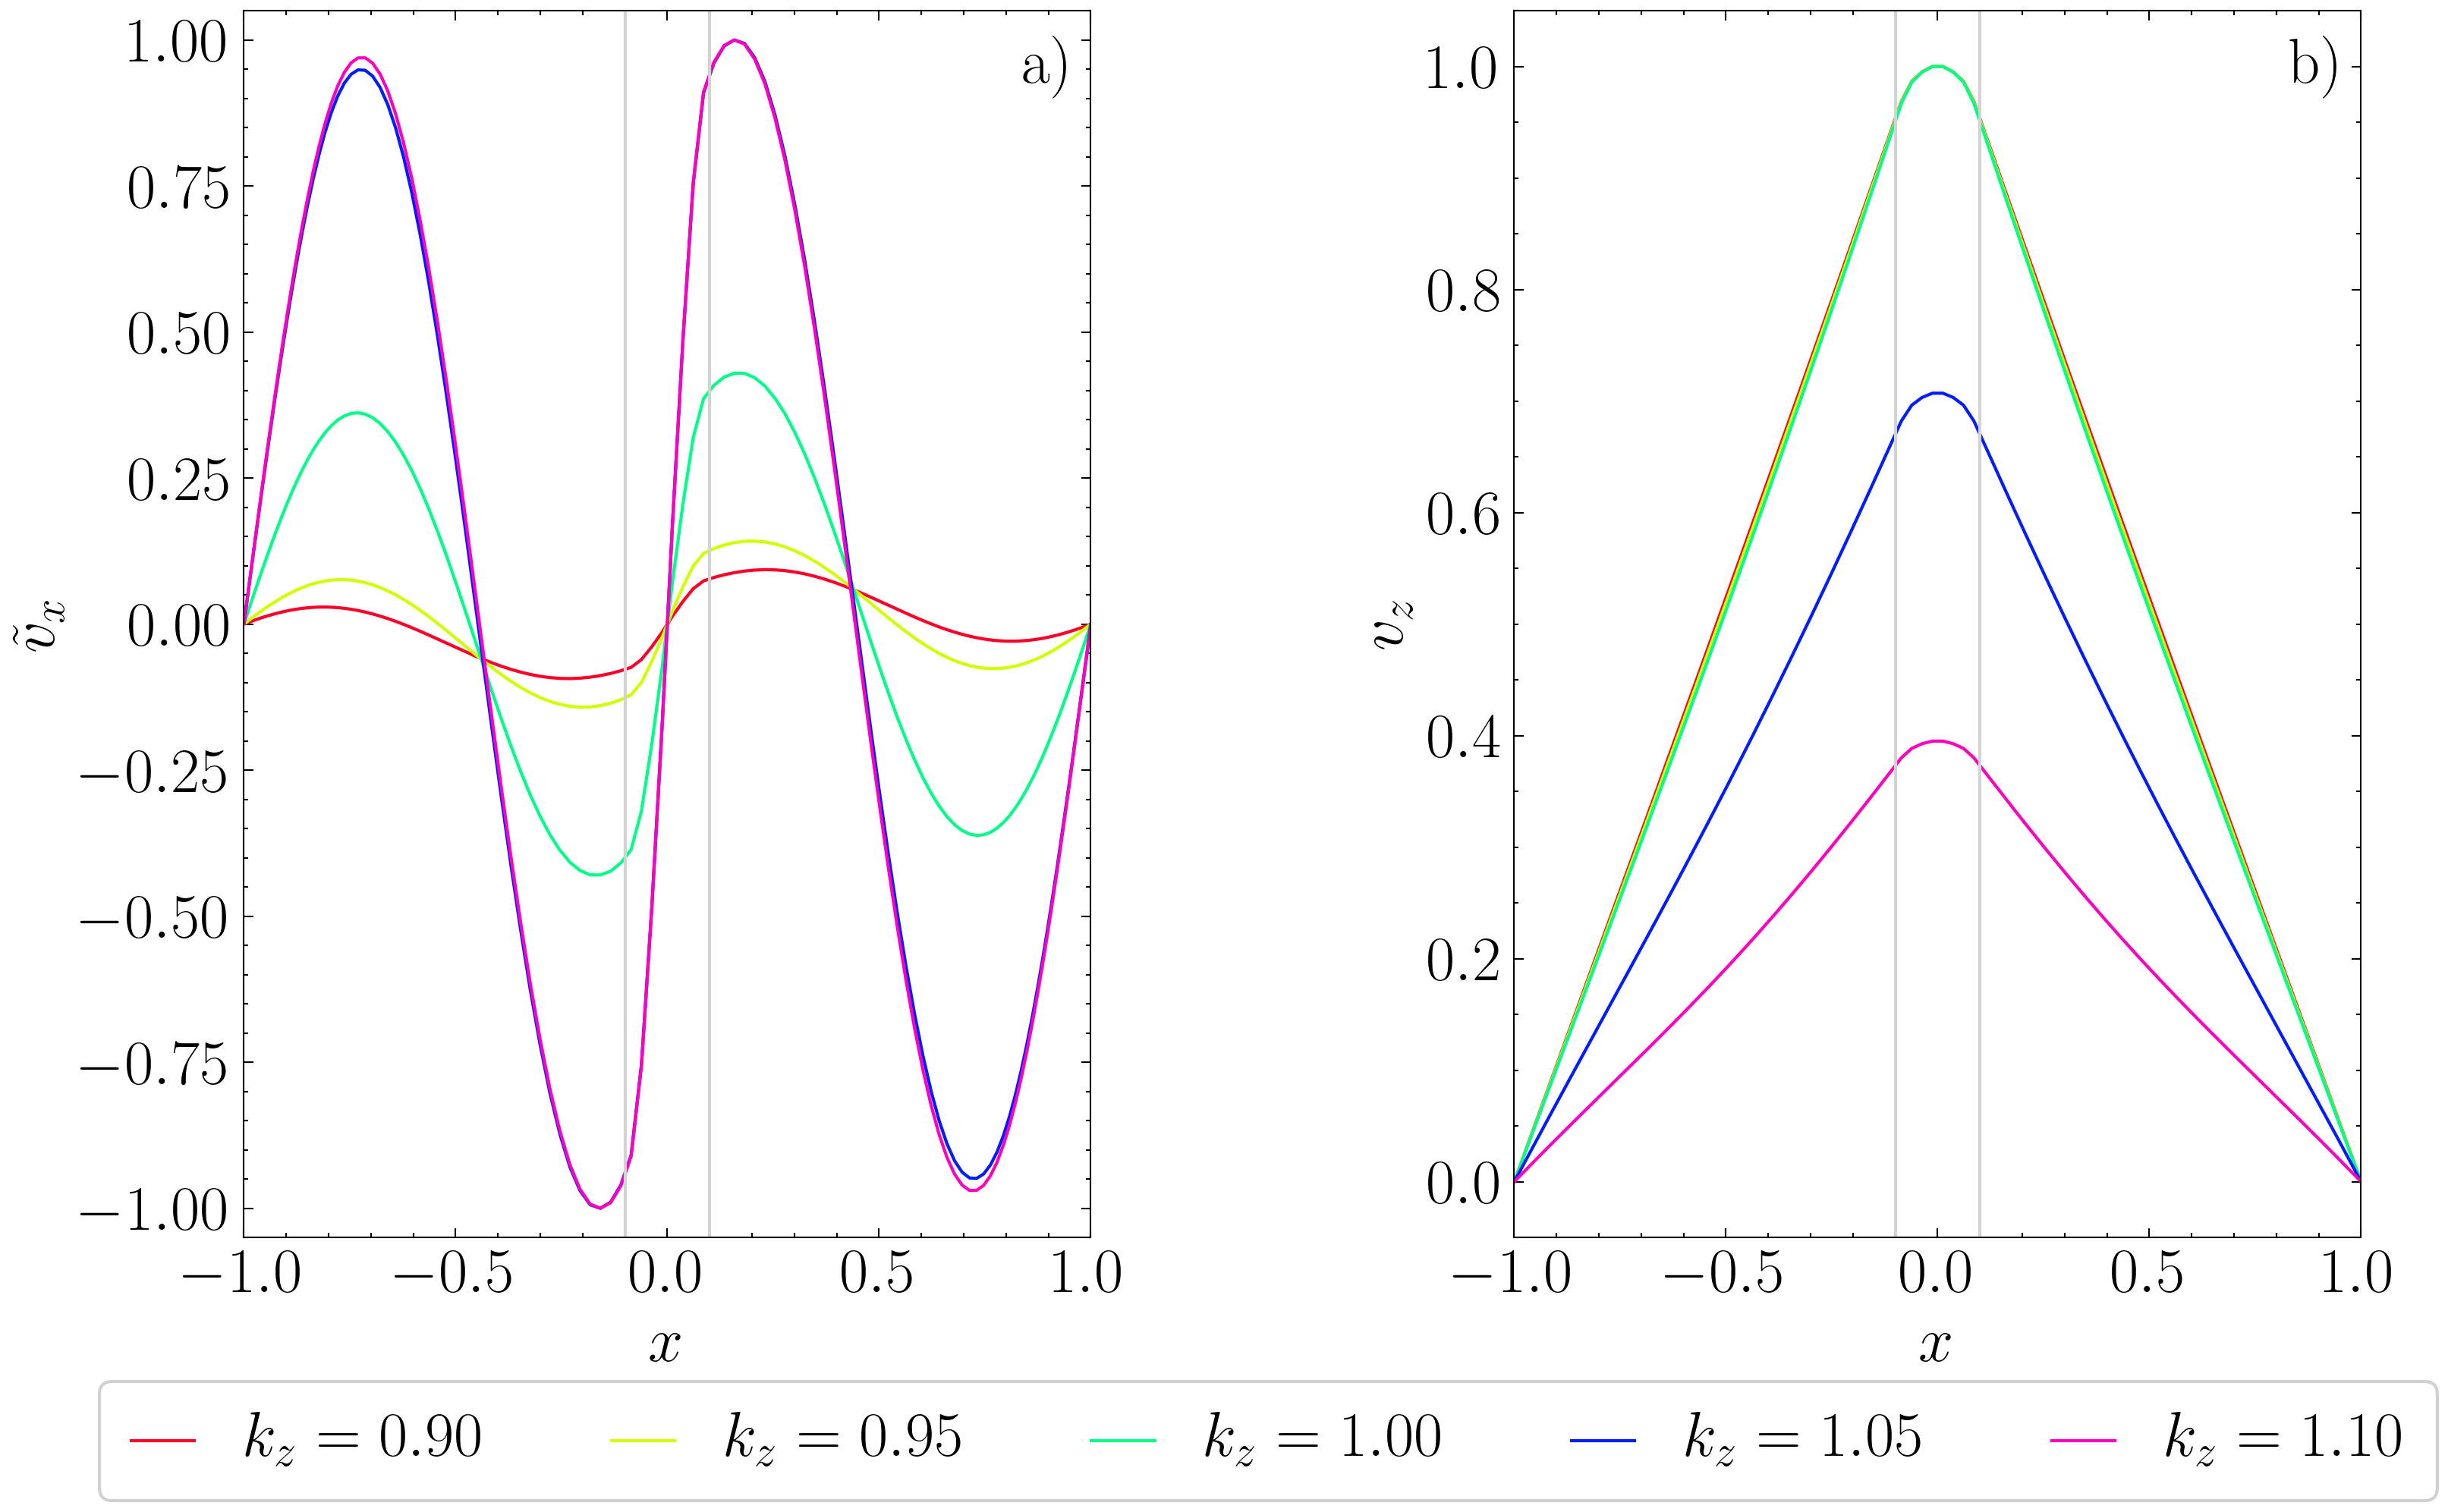

In [21]:
### Create a figure and a 1x2 grid of subplots ###
fig, axs = plt.subplots(1, 2, figsize=(12, 7))

#kz_manual_n_4 = np.array([0.95, 0.975, 1.00, 1.025, 1.05])

# -------------------- SUBFIGURES (a) i (b) --------------------

x = dist.local_grid(xbasis)

for i, kz in enumerate(kz_manual_n_4):
    problem = d3.EVP([u, w, tau_1, tau_2, tau_3, tau_4], eigenvalue=s, namespace=locals())
    problem.add_equation("s * u  +  c2 * uxx  +  kz * c2 * wx  =  0")
    problem.add_equation("vA2 * wxx  +  c2 * kz * ux  +  (-c2 * kz**2 - vA2 * kz**2 + s) * w  =  0")
    problem.add_equation("u(x=xmin) = 0")
    problem.add_equation("u(x=xmax) = 0")
    problem.add_equation("w(x=xmin) = 0")
    problem.add_equation("w(x=xmax) = 0")

    solver = problem.build_solver()
    solver.solve_dense(solver.subproblems[0])
    idx = np.argsort(solver.eigenvalues)[3]
    solver.set_state(idx, solver.subsystems[0])

    ug = u['g'].real
    wg = w['g'].real

    # Definim bé el signe del màxim i després normalitzam
    if np.max(np.abs(ug)) > np.max(np.abs(wg)):

        if kz == 1.1:
            print("kz =", kz, ", i =", i)
            aux = -ug
        
        else:
            print("kz =", kz, ", i =", i)
            aux = ug
        
        print("Maximum value is ug =", max_val)

    else:
        print("kz =", kz, ", i =", i)
        aux = wg
        print("Maximum value is wg =", max_val)

    index = np.argmax(np.abs(aux))
    max_val = aux[index]

    # Normalize both ug and wg by the maximum value
    ug_normalized = ug / max_val
    wg_normalized = wg / max_val

    axs[0].plot(x, ug_normalized, label=f"$k_z={kz_manual_n_4[i]:.2f}$", linestyle='-', color=cmap(i))
    axs[1].plot(x, wg_normalized, label=f"$k_z={kz_manual_n_4[i]:.2f}$", linestyle='-', color=cmap(i))

# Format ug
axs[0].set_xlabel(r"$x$", fontsize=20)
axs[0].set_ylabel(r"$\tilde{v}_{x}$", fontsize=20)
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(-1.05, 1.05)
axs[0].tick_params(labelsize=20)
axs[0].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[0].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

# Format wg
axs[1].set_xlabel(r"$x$", fontsize=20)
axs[1].set_ylabel(r"$v_{z}$", fontsize=20)
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(-0.05, 1.05)
axs[1].tick_params(labelsize=20)
axs[1].axvline(x=-xp, color='lightgrey', linestyle='-', linewidth=1)
axs[1].axvline(x=xp, color='lightgrey', linestyle='-', linewidth=1)

### Etiquetes a) i b) ###
axs[0].text(0.98, 0.98, "a)", transform=axs[0].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')
axs[1].text(0.98, 0.98, "b)", transform=axs[1].transAxes, fontsize=20, va='top', ha='right', fontweight='bold')

### Llegenda ###
fig.legend(
    handles=axs[0].get_lines()[:len(kz_manual_n_4)],  # Use lines from the first subplot (they share labels/colors)
    labels=[f"$k_z = {kz_manual_n_4[i]:.2f}$" for i in range(len(kz_manual_n_4))],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=len(kz_manual_n_4),
    frameon=True,
    fontsize=20,
    title_fontsize=20,
    handlelength=1,
    handleheight=0.1,
    borderpad=0.5,
    borderaxespad=0.5,
    framealpha=0.9,
)

# -------------------- Finalització --------------------
plt.subplots_adjust(wspace=0.5)
#plt.savefig("Evolució_autofuncions_n_4_subplots.png", dpi=300, bbox_inches='tight')
plt.show()
